In [1]:
import os
# 1) Temporary fallback (only for evaluation/visualization; 
#    remove this if strict numerical consistency is required and fix via the “root-cause solution” instead)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 2) Limit the number of threads for each backend to prevent edge-case issues triggered by parallelism
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# 3) Let torch load its runtime libraries first
import torch

# 4) Then import the remaining libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display
from IPython.display import display


In [2]:
# ============================================
# Speech Denoising I/O with Perceptual+Spatial Target (fixed)
# - Remote-channel degradation for noisy
# - Perceptual + spatial enhancement for clean target (human-ear + "in-the-room")
# - In-notebook A/B preview + objective evaluation (no saving)
# ============================================

# %pip install -q soundfile librosa torch torchvision torchaudio matplotlib pandas

import os, math, random, time
from pathlib import Path
import numpy as np

# ---- numpy-compat shim for some librosa versions ----
if not hasattr(np, "complex"):
    np.complex = np.complex128
if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "object"):
    np.object = np.object_
if not hasattr(np, "float"):
    np.float = float

import soundfile as sf
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio, display
import pandas as pd

# =========================
# Paths (keep your original)
# =========================
CLEAN_TR = r"D:\GitHub\ELEC5305_dataset\clean_trainset_28spk_wav"
NOISY_TR = r"D:\GitHub\ELEC5305_dataset\noisy_trainset_28spk_wav"
CLEAN_TE = r"D:\GitHub\ELEC5305_dataset\clean_testset_wav"
NOISY_TE = r"D:\GitHub\ELEC5305_dataset\noisy_testset_wav"

# =========================
# Audio / STFT / Train HPs
# =========================
TARGET_SR   = 16000
SEGMENT_SEC = 2.0
SEGMENT_SAM = int(TARGET_SR * SEGMENT_SEC)

N_FFT = 512
HOP   = 128
WIN   = N_FFT
WINDOW = torch.hann_window(WIN)

BATCH_SIZE = 8
LR = 1e-3
EPOCHS = 10
LAMBDA_SISDR = 1.0
LAMBDA_SPEC  = 0.2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

MAX_TRAIN_PAIRS   = 300
PAIR_SUBSET_SEED  = 2025

Device: cuda


C:\Users\Daniel Deng\AppData\Local\Temp\ipykernel_19240\2077698919.py:17: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "bool"):
C:\Users\Daniel Deng\AppData\Local\Temp\ipykernel_19240\2077698919.py:19: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
# =========================
# Remote-channel degradation (Keep as is: noise / bandwidth / echo / packet loss, etc.)
# =========================
import numpy as np, librosa, soundfile as sf
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader

def mu_law_encode(x, mu=255.0):
    x = np.clip(x, -1.0, 1.0)
    return np.sign(x) * np.log1p(mu * np.abs(x)) / np.log1p(mu)

def mu_law_decode(y, mu=255.0):
    return np.sign(y) * (1.0 / mu) * (np.expm1(np.log1p(mu) * np.abs(y)))

def colored_noise(N, color="white", a=0.985, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.standard_normal(N).astype(np.float32)
    if color == "white":
        return x
    y = np.zeros_like(x)
    for n in range(N):
        y[n] = a * (y[n-1] if n > 0 else 0.0) + (1 - a) * x[n]
    if color == "pink":
        return y
    if color == "brown":
        z = np.zeros_like(y)
        for n in range(N):
            z[n] = a * (z[n-1] if n > 0 else 0.0) + (1 - a) * y[n]
        return z
    return x

def add_background_noise(x, snr_db_range=(0, 20), mode="mix", seed=None):
    rng = np.random.default_rng(seed)
    N = len(x)
    if mode == "mix":
        color = rng.choice(["white", "pink", "brown"])
        n = colored_noise(N, color=color, seed=seed)
    elif mode == "speechbleed":
        n = x.copy()
        rng.shuffle(n)
        n = colored_noise(N, color="pink", seed=seed) * 0.6 + n * 0.4
    else:
        n = colored_noise(N, color="white", seed=seed)
    snr_db = rng.uniform(*snr_db_range)
    Px = np.mean(x.astype(np.float64)**2) + 1e-12
    Pn_target = Px / (10**(snr_db/10.0))
    Pn = np.mean(n.astype(np.float64)**2) + 1e-12
    n = n * np.sqrt(Pn_target / Pn)
    y = x + n.astype(np.float32)
    return y

def packet_loss(x, sr, frame_ms=20, loss_rate=0.05, burst_prob=0.3, mode="zero", seed=None):
    rng = np.random.default_rng(seed)
    L = max(1, int(sr * frame_ms / 1000.0))
    T = (len(x) + L - 1) // L
    x2 = x.astype(np.float32).copy()
    lose = rng.random(T) < loss_rate
    if rng.random() < burst_prob and T > 4:
        start = rng.integers(0, T - 3)
        span  = rng.integers(2, min(8, T - start))
        lose[start:start + span] = True
    last_good = None
    for t in range(T):
        s = t * L
        e = min(len(x2), s + L)
        seg_len = e - s
        if lose[t]:
            if mode == "zero" or last_good is None:
                x2[s:e] = 0.0
            else:
                x2[s:e] = last_good[:seg_len]
        else:
            last_good = x2[s:e].copy()
    return x2

def echo_ir(sr, delays_ms=(20, 120), taps_range=(1, 3), decay_range=(0.25, 0.7), seed=None):
    rng = np.random.default_rng(seed)
    taps = rng.integers(taps_range[0], taps_range[1]+1)
    max_delay = int(sr * (delays_ms[1] / 1000.0)) + 1
    h = np.zeros(max_delay + 1, dtype=np.float32)
    h[0] = 1.0
    for _ in range(taps):
        d_ms = rng.uniform(*delays_ms)
        d = int(sr * d_ms / 1000.0)
        if d == 0: d = 1
        decay = rng.uniform(*decay_range)
        h[d] += decay
    if np.max(np.abs(h)) > 1.0:
        h = h / np.max(np.abs(h))
    return h

def apply_fir(x, h):
    y = np.convolve(x.astype(np.float32), h.astype(np.float32), mode="full")[:len(x)]
    y = np.clip(y, -3.0, 3.0)
    return y.astype(np.float32)

def bandlimit_stft(x, sr, f_lo=300.0, f_hi=3400.0, n_fft=512, hop=128, win=512):
    X = librosa.stft(x, n_fft=n_fft, hop_length=hop, win_length=win)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    M = mask[:, None].astype(np.float32)
    Y = X * M
    y = librosa.istft(Y, hop_length=hop, win_length=win, length=len(x))
    return y.astype(np.float32)

def codec_artifact(x, sr, low_sr=8000, mu=255.0):
    y = librosa.resample(x.astype(np.float32), orig_sr=sr, target_sr=low_sr)
    y = librosa.resample(y.astype(np.float32), orig_sr=low_sr, target_sr=sr)
    y_mu = mu_law_decode(mu_law_encode(y, mu=mu), mu=mu)
    L = min(len(x), len(y_mu))
    out = np.zeros_like(x)
    out[:L] = y_mu[:L]
    if L < len(out):
        out[L:] = y_mu[-1]
    return out.astype(np.float32)

class RemoteChannelAugmentor:
    def __init__(self,
                 snr_db_range=(0, 20),
                 noise_mode_choices=("mix", "speechbleed"),
                 packet_loss_rate=(0.0, 0.15),
                 packet_burst_prob=0.4,
                 packet_mode_choices=("zero", "hold"),
                 echo_delays_ms=(20, 160),
                 echo_taps=(1, 3),
                 echo_decay=(0.2, 0.8),
                 bandlimit_prob=0.8,
                 codec_prob=0.8,
                 seed=None):
        self.snr_db_range = snr_db_range
        self.noise_mode_choices = noise_mode_choices
        self.packet_loss_rate = packet_loss_rate
        self.packet_burst_prob = packet_burst_prob
        self.packet_mode_choices = packet_mode_choices
        self.echo_delays_ms = echo_delays_ms
        self.echo_taps = echo_taps
        self.echo_decay = echo_decay
        self.bandlimit_prob = bandlimit_prob
        self.codec_prob = codec_prob
        self.rng = np.random.default_rng(seed)

    def __call__(self, x, sr):
        rng = self.rng
        y = x.astype(np.float32).copy()
        if rng.random() < self.codec_prob:
            y = codec_artifact(y, sr)
        if rng.random() < self.bandlimit_prob:
            f_lo = rng.uniform(200.0, 400.0)
            f_hi = rng.uniform(3200.0, 3800.0)
            f_lo, f_hi = min(f_lo, f_hi-200.0), max(f_hi, f_lo+200.0)
            y = bandlimit_stft(y, sr, f_lo=f_lo, f_hi=f_hi, n_fft=512, hop=128, win=512)
        h = echo_ir(sr, delays_ms=self.echo_delays_ms, taps_range=self.echo_taps,
                    decay_range=self.echo_decay, seed=rng.integers(1e9))
        y = apply_fir(y, h)
        noise_mode = rng.choice(self.noise_mode_choices)
        y = add_background_noise(y, snr_db_range=self.snr_db_range, mode=noise_mode,
                                 seed=rng.integers(1e9))
        loss_rate = rng.uniform(*self.packet_loss_rate)
        plc_mode  = rng.choice(self.packet_mode_choices)
        y = packet_loss(y, sr, frame_ms=20, loss_rate=loss_rate,
                        burst_prob=self.packet_burst_prob, mode=plc_mode,
                        seed=rng.integers(1e9))
        y = np.clip(y, -1.0, 1.0).astype(np.float32)
        return y

# =========================
# I/O helpers
# =========================
def read_mono_resample(path, target_sr=16000):
    y, sr = sf.read(path, always_2d=False)
    if y.ndim == 2:
        y = y.mean(axis=1)
    if sr != target_sr:
        y = librosa.resample(y.astype(np.float32), orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    y = y.astype(np.float32)
    return y, sr

def pad_or_trim(x, length):
    if len(x) >= length:
        start = np.random.randint(0, len(x) - length + 1)
        return x[start:start+length]
    out = np.zeros(length, dtype=np.float32)
    out[:len(x)] = x
    return out

# =========================
# Perceptual + Spatial Enhancer
# =========================
class PerceptualSpatialEnhancer:
    def __init__(self,
                 sr=16000,
                 n_fft=512, hop=128, win=512,
                 low_cut=80.0,
                 presence_boost_db=1.4,
                 presence_bw=2600.0,
                 erb_width=1.2,
                 widen_ms=0.30,
                 early_ref_ms=(8, 16),
                 early_ref_gain=(0.15, 0.08),
                 late_rt60=0.18,
                 stereo_shelf_db=0.4,
                 target_delta_db=3.0,
                 produce_stereo_target=False):
        self.sr = sr
        self.n_fft = n_fft
        self.hop = hop
        self.win = win
        self.low_cut = low_cut
        self.presence_boost_db = presence_boost_db
        self.presence_bw = presence_bw
        self.erb_width = erb_width
        self.widen_ms = widen_ms
        self.early_ref_ms = early_ref_ms
        self.early_ref_gain = early_ref_gain
        self.late_rt60 = late_rt60
        self.stereo_shelf_db = stereo_shelf_db
        self.target_delta_db = target_delta_db
        self.produce_stereo_target = produce_stereo_target

    @staticmethod
    def _a_weighting_mag(freqs):
        f = np.maximum(freqs, 1e-6)
        ra = (12200**2 * f**4) / ((f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2)*(f**2 + 737.9**2)) * (f**2 + 12200**2))
        AdB = 20*np.log10(ra) + 2.0
        A = 10**(AdB/20.0)
        A /= (np.max(A) + 1e-12)
        return A

    def _erb_smooth_mag(self, mag):
        freqs = np.linspace(0, self.sr/2, self.n_fft//2+1)
        mag_s = np.zeros_like(mag)
        for k, f in enumerate(freqs):
            erb = 24.7 * (4.37 * (f/1000.0) + 1.0)
            bw  = max(self.erb_width * erb, self.sr/self.n_fft)
            w   = np.exp(-0.5*((freqs - f)/(bw/2.355))**2)
            w  /= (w.sum() + 1e-12)
            mag_s[k, :] = (w[:, None] * mag).sum(axis=0)
        return mag_s

    def _presence_tilt(self, freqs):
        center = 3200.0
        bw = self.presence_bw
        gain = 10**(self.presence_boost_db/20.0)
        return 1.0 + (gain - 1.0) * np.exp(-0.5*((freqs-center)/(bw/2.355))**2)

    def _a_weighted_level_db(self, sig):
        X = librosa.stft(sig, n_fft=self.n_fft, hop_length=self.hop, win_length=self.win, window='hann')
        freqs = librosa.fft_frequencies(sr=self.sr, n_fft=self.n_fft)
        A = self._a_weighting_mag(freqs)[:, None]
        mag = np.abs(X)
        aw = (mag * A).mean()
        return 20*np.log10(aw + 1e-12)

    def enhance(self, x_mono: np.ndarray) -> np.ndarray:
        sr = self.sr
        X = librosa.stft(x_mono, n_fft=self.n_fft, hop_length=self.hop, win_length=self.win, window='hann')
        freqs = librosa.fft_frequencies(sr=sr, n_fft=self.n_fft)
        mag, phs = np.abs(X), np.angle(X)

        A = self._a_weighting_mag(freqs) * (freqs >= self.low_cut)
        magA = mag * A[:, None]

        pres = self._presence_tilt(freqs)
        magP = magA * pres[:, None]

        magS = self._erb_smooth_mag(magP)

        Y = magS * np.exp(1j * phs)
        y_mono = librosa.istft(Y, hop_length=self.hop, win_length=self.win, length=len(x_mono))

        if not self.produce_stereo_target:
            rt = max(self.late_rt60, 1e-3)
            t  = np.arange(len(y_mono))/sr
            tail = np.random.randn(len(y_mono)) * 0.0007 * np.exp(-6.91 * t / rt)
            y_out = y_mono + tail

            lev_clean = self._a_weighted_level_db(x_mono)
            lev_enh   = self._a_weighted_level_db(y_out)
            gain = 10**(((lev_clean + self.target_delta_db) - lev_enh)/20.0)
            y_out = y_out * gain
            y_out = y_out / (np.max(np.abs(y_out)) + 1e-9)
            return y_out.astype(np.float32)

        # 立体声生成（只改 target，不改 noisy）
        delay_samps = int(sr * (self.widen_ms/1000.0))
        L = np.pad(y_mono, (0, delay_samps))
        R = np.pad(y_mono, (delay_samps, 0))
        L, R = L[:len(y_mono)], R[:len(y_mono)]

        def shelf(sig, hi_gain_db):
            Xs = librosa.stft(sig, n_fft=self.n_fft, hop_length=self.hop, win_length=self.win, window='hann')
            g  = 10**(hi_gain_db/20.0)
            tilt = 1.0 + (g-1.0) * (librosa.fft_frequencies(sr=sr, n_fft=self.n_fft)/(sr/2))
            Xs = Xs * tilt[:, None]
            return librosa.istft(Xs, hop_length=self.hop, win_length=self.win, length=len(sig))

        L = shelf(L, +self.stereo_shelf_db)
        R = shelf(R, -self.stereo_shelf_db)

        def early(sig, delays_ms, gains):
            y = sig.copy()
            for d_ms, g in zip(delays_ms, gains):
                d = int(sr * d_ms/1000.0)
                if d < len(y):
                    y[d:] += g * y[:-d]
            return y

        L = early(L, self.early_ref_ms, self.early_ref_gain)
        R = early(R, tuple(m+2 for m in self.early_ref_ms), self.early_ref_gain)

        rt = max(self.late_rt60, 1e-3)
        t  = np.arange(len(L))/sr
        decay = np.exp(-6.91 * t / rt)
        L = L + np.random.randn(len(L))*0.0007 * decay
        R = R + np.random.randn(len(R))*0.0007 * decay

        st = np.stack([L, R], axis=-1)  # [T,2]

        mono_tmp = st.mean(axis=1)
        lev_clean = self._a_weighted_level_db(x_mono)
        lev_enh   = self._a_weighted_level_db(mono_tmp)
        gain = 10**(((lev_clean + self.target_delta_db) - lev_enh)/20.0)
        st = st * gain
        st = st / (np.max(np.abs(st)) + 1e-9)
        return st.astype(np.float32)

# =========================
# Global parameters (will be retained if already defined externally)
# =========================
TARGET_SR = globals().get("TARGET_SR", 16000)
N_FFT     = globals().get("N_FFT", 512)
HOP       = globals().get("HOP", 128)
WIN       = globals().get("WIN", 512)

SEGMENT_SAM      = globals().get("SEGMENT_SAM", TARGET_SR*4) 
MAX_TRAIN_PAIRS  = globals().get("MAX_TRAIN_PAIRS", None)
PAIR_SUBSET_SEED = globals().get("PAIR_SUBSET_SEED", 2024)

# path
NOISY_TR = globals().get("NOISY_TR", None)   # e.g., "data/train/noisy"
CLEAN_TR = globals().get("CLEAN_TR", "data/train/clean")
NOISY_TE = globals().get("NOISY_TE", None)   # e.g., "data/test/noisy"
CLEAN_TE = globals().get("CLEAN_TE", "data/test/clean")

# -- Two examples: one only performs perception enhancement (mono), and the other performs perception combined with space (stereo) --
ENHANCER_MONO = PerceptualSpatialEnhancer(
    sr=TARGET_SR, n_fft=N_FFT, hop=HOP, win=WIN,
    low_cut=50.0,
    presence_boost_db=0.9,
    presence_bw=2600.0,
    erb_width=0.08,
    late_rt60=0.12,
    widen_ms=0.50,            
    stereo_shelf_db=0.2,      
    target_delta_db=3.0,
    produce_stereo_target=False  
)

ENHANCER_STEREO = PerceptualSpatialEnhancer(
    sr=TARGET_SR, n_fft=N_FFT, hop=HOP, win=WIN,
    low_cut=50.0,
    presence_boost_db=0.9,
    presence_bw=2600.0,
    erb_width=0.08,
    late_rt60=0.12,
    widen_ms=0.50,
    stereo_shelf_db=0.2,
    target_delta_db=3.0,
    produce_stereo_target=True   
)

# =========================
# Dataset
# =========================
class VBDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, target_sr=16000, segment_sam=None,
                 train=True, max_pairs=None,
                 use_synth_remote=False, synth_prob=1.0, augmentor=None,
                 enhancer=None):
        self.noisy_dir = Path(noisy_dir) if (noisy_dir is not None) else None
        self.clean_dir = Path(clean_dir)
        self.segment_sam = segment_sam
        self.target_sr = target_sr
        self.train = train
        self.max_pairs = max_pairs
        self.use_synth_remote = use_synth_remote
        self.synth_prob = synth_prob
        self.augmentor = augmentor if augmentor is not None else RemoteChannelAugmentor()
        self.enhancer = enhancer  

        if self.noisy_dir is not None and self.noisy_dir.exists():
            noisy_files = sorted(list(self.noisy_dir.glob("*.wav")))
        else:
            noisy_files = []

        pairs = []
        if noisy_files:
            for nf in noisy_files:
                cf = self.clean_dir / nf.name
                if cf.exists():
                    pairs.append((nf, cf))
        else:
            clean_files = sorted(list(self.clean_dir.glob("*.wav")))
            for cf in clean_files:
                pairs.append((None, cf))

        if not pairs:
            raise RuntimeError("No samples were found. Please check paths.")

        if self.train and (max_pairs is not None) and (len(pairs) > max_pairs):
            rng = np.random.default_rng(PAIR_SUBSET_SEED)
            idx = rng.choice(len(pairs), size=max_pairs, replace=False)
            self.pairs = [pairs[i] for i in idx]
            print(f"Train pairs: {len(self.pairs)} / {len(pairs)} (subset with seed={PAIR_SUBSET_SEED})")
        else:
            self.pairs = pairs
            print(f"{'Train' if train else 'Eval'} pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def _read_one(self, nf, cf):
        clean, _ = read_mono_resample(cf, self.target_sr)
        use_synth = (self.train and self.use_synth_remote and (np.random.rand() < self.synth_prob))
        if (not use_synth) and (nf is not None):
            noisy, _ = read_mono_resample(nf, self.target_sr)
            L = min(len(noisy), len(clean))
            noisy = noisy[:L]; clean = clean[:L]
        else:
            # Synthesized remote channel degradation, noisy (still mono)
            noisy = self.augmentor(clean, self.target_sr)
            L = min(len(noisy), len(clean))
            noisy = noisy[:L]; clean = clean[:L]
        return noisy.astype(np.float32), clean.astype(np.float32)

    def __getitem__(self, idx):
        nf, cf = self.pairs[idx]
        noisy, clean = self._read_one(nf, cf)

        # === Generate the target based on the enhancer ===
        if self.enhancer is None:
            clean_tgt = clean  
        else:
            clean_tgt = self.enhancer.enhance(clean) 

        # --- The training set can be segmented; the test set cannot be segmented. ---
        if self.train and self.segment_sam is not None:
            L = min(len(noisy), len(clean_tgt) if np.ndim(clean_tgt)==1 else clean_tgt.shape[0])
            if L >= self.segment_sam:
                start = np.random.randint(0, L - self.segment_sam + 1)
                noisy = noisy[start:start+self.segment_sam]
                if np.ndim(clean_tgt) == 1:
                    clean_tgt = clean_tgt[start:start+self.segment_sam]
                else:
                    clean_tgt = clean_tgt[start:start+self.segment_sam, :]  # [Tseg,2]
            else:
                noisy = pad_or_trim(noisy, self.segment_sam)
                if np.ndim(clean_tgt) == 1:
                    clean_tgt = pad_or_trim(clean_tgt, self.segment_sam)
                else:
                    tgt = np.zeros((self.segment_sam, clean_tgt.shape[1]), dtype=np.float32)
                    tgt[:len(clean_tgt)] = clean_tgt
                    clean_tgt = tgt

        # --- Pack the tensor ---
        noisy_t = torch.from_numpy(noisy)  # [T]
        if np.ndim(clean_tgt) == 1:
            clean_t = torch.from_numpy(clean_tgt)               # [T]
        else:  # [T,2] -> [2,T]
            clean_t = torch.from_numpy(clean_tgt).permute(1,0)

        return noisy_t, clean_t

# =========================
# Build datasets / loaders
# =========================
# Remote synthesizer
my_aug = RemoteChannelAugmentor(
    snr_db_range=(0, 20),
    packet_loss_rate=(0.0, 0.15),
    packet_burst_prob=0.5,
    bandlimit_prob=0.8,
    codec_prob=0.8
)

BATCH_SIZE = globals().get("BATCH_SIZE", 8)

# 1) Noise reduction training set
train_ds_mono = VBDataset(
    NOISY_TR, CLEAN_TR,
    target_sr=TARGET_SR,
    segment_sam=SEGMENT_SAM,          
    train=True,
    max_pairs=MAX_TRAIN_PAIRS,
    use_synth_remote=True,
    synth_prob=0.5,
    augmentor=my_aug,
    enhancer=ENHANCER_MONO           
)

# 2) Noise reduction test set
test_ds_mono  = VBDataset(
    NOISY_TE, CLEAN_TE,
    target_sr=TARGET_SR,
    segment_sam=None,                 
    train=False,
    max_pairs=None,
    use_synth_remote=True,            
    synth_prob=1.0,
    augmentor=my_aug,
    enhancer=ENHANCER_MONO            
)

# 3) Spatialization test set
test_ds_spatial = VBDataset(
    NOISY_TE, CLEAN_TE,
    target_sr=TARGET_SR,
    segment_sam=None,
    train=False,
    max_pairs=None,
    use_synth_remote=True,
    synth_prob=1.0,
    augmentor=my_aug,
    enhancer=ENHANCER_STEREO          
)

# DataLoaders
train_dl_mono = DataLoader(train_ds_mono, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_dl_mono  = DataLoader(test_ds_mono,  batch_size=1,               shuffle=False, num_workers=0)
test_dl_spat  = DataLoader(test_ds_spatial, batch_size=1,             shuffle=False, num_workers=0)

print("\nBuilt loaders:")
print(f" - train_dl_mono:  {len(train_ds_mono)} samples, batch={BATCH_SIZE}")
print(f" - test_dl_mono:   {len(test_ds_mono)} samples")
print(f" - test_dl_spat:   {len(test_ds_spatial)} samples (stereo targets)")



Train pairs: 300 / 11572 (subset with seed=2025)
Eval pairs: 824
Eval pairs: 824

Built loaders:
 - train_dl_mono:  300 samples, batch=8
 - test_dl_mono:   824 samples
 - test_dl_spat:   824 samples (stereo targets)


In [59]:
# =========================
# Demo: Random playback (one mono target and one stereo target)
# =========================
def _play(arr, sr):
    arr = np.asarray(arr, dtype=np.float32)
    peak = np.max(np.abs(arr)) + 1e-12
    if peak > 1.0: arr = arr/peak
    if arr.ndim==1:
        display(Audio(arr, rate=sr))
    elif arr.ndim==2 and arr.shape[0]==2:
        display(Audio(arr, rate=sr))      # [2,T] is valid for IPython.Audio
    else:
        display(Audio(arr.T, rate=sr))    # [T,2] → [2,T]

# Playback mono target
noisy_m, tgt_m = test_ds_mono[np.random.randint(len(test_ds_mono))]
print("\n[Preview] Mono target example")
_play(noisy_m.numpy(), TARGET_SR)
_play(tgt_m.numpy(),   TARGET_SR)

# Playback stereo teacher target
noisy_s, tgt_s = test_ds_spatial[np.random.randint(len(test_ds_spatial))]
print("\n[Preview] Stereo-teacher target example")
_play(noisy_s.numpy(),           TARGET_SR)
_play(tgt_s.numpy(),             TARGET_SR)  # [2,T]


[Preview] Mono target example



[Preview] Stereo-teacher target example


In [60]:
# ============================================
# Perceptual + Spatial objective metrics (adapted for mono_train / mono_test / spatial_test / dsp_from_mono)
# - Fetch target directly from dataset (no longer depends on disk paths)
# - For mono datasets, optionally use ENHANCER_STEREO to generate stereo teacher for comparison
# ============================================
import numpy as np
import pandas as pd
import librosa
from IPython.display import display

# ---- numpy compatibility (for certain librosa versions) ----
if not hasattr(np, "complex"): np.complex = np.complex128
if not hasattr(np, "bool"):    np.bool    = np.bool_
if not hasattr(np, "object"):  np.object  = np.object_
if not hasattr(np, "float"):   np.float   = float

# ---- Global parameters (read from your existing environment) ----
TARGET_SR = int(globals().get("TARGET_SR", 16000))
N_FFT     = int(globals().get("N_FFT", 512))
HOP       = int(globals().get("HOP", 128))
WIN       = int(globals().get("WIN", 512))

# Available datasets (automatically skipped if not present)
_DATASETS = {
    "mono_train":   globals().get("train_ds_mono",   None),
    "mono_test":    globals().get("test_ds_mono",    None),
    "spatial_test": globals().get("test_ds_spatial", None),
}
ENHANCER_STEREO = globals().get("ENHANCER_STEREO", None)  # Used to generate stereo teacher

# ---------- Metric functions ----------
def _stft_mag(y, sr, n_fft=N_FFT, hop=HOP, win=WIN):
    X = librosa.stft(y, n_fft=n_fft, hop_length=hop, win_length=win, window="hann")
    return np.abs(X) + 1e-12, librosa.fft_frequencies(sr=sr, n_fft=n_fft)

def _rms(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.mean(x*x) + 1e-12))

def a_weighting_mag(freqs):
    f = np.maximum(freqs, 1e-6)
    ra = (12200**2 * f**4) / ((f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2)*(f**2 + 737.9**2)) * (f**2 + 12200**2))
    AdB = 20*np.log10(ra + 1e-24) + 2.0
    A = 10**(AdB/20.0)
    A /= (np.max(A) + 1e-12)
    return A

def a_weighted_level(y, sr, n_fft=N_FFT, hop=HOP, win=WIN):
    mag, freqs = _stft_mag(y, sr, n_fft, hop, win)
    A = a_weighting_mag(freqs)[:, None]
    aw = float(np.mean(mag * A))
    return 20*np.log10(aw + 1e-12)

def presence_ratio(y, sr, band=(2000, 5000), n_fft=N_FFT, hop=HOP, win=WIN):
    mag, freqs = _stft_mag(y, sr, n_fft, hop, win)
    total = float(np.sum(mag))
    if total <= 0: return 0.0
    sel = (freqs >= band[0]) & (freqs <= band[1])
    band_sum = float(np.sum(mag[sel, :]))
    return band_sum / (total + 1e-12)

def spectral_centroid_mean(y, sr, n_fft=N_FFT, hop=HOP, win=WIN):
    sc = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop, win_length=win, window="hann")
    return float(np.mean(sc))

def erb_smoothness_index(y, sr, n_fft=N_FFT, hop=HOP, win=WIN):
    mag, _ = _stft_mag(y, sr, n_fft, hop, win)
    logm = np.log(mag)
    d = np.diff(logm, axis=0)  # Adjacent differences along frequency axis
    return float(np.mean(np.var(d, axis=0)))  # Lower → smoother

def gcc_phat_itd_ms(L, R, sr):
    Nsig = min(len(L), len(R))
    L = L[:Nsig]; R = R[:Nsig]
    # Choose enough FFT points
    N = 1
    Ltot = len(L) + len(R)
    while N < Ltot: N <<= 1
    Lf = np.fft.rfft(L, n=N); Rf = np.fft.rfft(R, n=N)
    G = Lf * np.conj(Rf)
    G /= (np.abs(G) + 1e-12)
    cc = np.fft.irfft(G, n=N)
    # Move zero-lag to center
    cc = np.concatenate([cc[-(N//2):], cc[:(N//2)]])
    lag = int(np.argmax(cc)) - (N//2)
    peak = float(np.max(cc))
    return float(lag / sr * 1000.0), peak

def ild_db(L, R):
    return 20*np.log10((_rms(L)+1e-12)/(_rms(R)+1e-12))

def iacc(L, R, maxlag_ms, sr):
    maxlag = int(sr * maxlag_ms/1000.0)
    L = L - np.mean(L); R = R - np.mean(R)
    Lz = L / (np.std(L)+1e-12)
    Rz = R / (np.std(R)+1e-12)
    corr = np.correlate(Lz, Rz, mode='full') / len(Lz)
    mid = len(corr)//2
    lo = max(0, mid - maxlag)
    hi = min(len(corr), mid + maxlag + 1)
    return float(np.max(corr[lo:hi]))

# ---------- Fetch a sample from dataset and generate enhancement if needed ----------
def _tensor_to_np(x):
    import torch
    if "torch" in str(type(x)):
        return x.detach().cpu().numpy().astype(np.float32)
    return np.asarray(x, dtype=np.float32)

def fetch_sample(dataset_name, idx=None, make_spatial_if_mono=True):
    """
    Returns: clean_mono(np[T]), enhanced(np[T] or np[T,2]), sr(int), info(dict)
    - For mono_* datasets: target is mono; if make_spatial_if_mono=True, generate stereo teacher via ENHANCER_STEREO
    - For spatial_test: target is [2,T] (returned directly)
    """
    ds = _DATASETS.get(dataset_name, None)
    if ds is None:
        raise ValueError(f"Dataset '{dataset_name}' does not exist or has not been constructed. Available: {list(k for k,v in _DATASETS.items() if v is not None)}")

    if idx is None:
        import random
        idx = random.randint(0, len(ds)-1)

    noisy_t, target_t = ds[idx]  # noisy:[T], target:[T] or [2,T]
    tgt_np = _tensor_to_np(target_t)
    sr = int(getattr(ds, "target_sr", TARGET_SR))

    if tgt_np.ndim == 1:
        # mono target
        clean_mono = tgt_np
        if make_spatial_if_mono and ENHANCER_STEREO is not None:
            try:
                enhanced = ENHANCER_STEREO.enhance(clean_mono)  # [T,2]
            except Exception:
                # fallback: minimal stereo (small delay)
                delay = max(1, int(0.0005 * sr))
                L = np.pad(clean_mono, (0, delay))[:len(clean_mono)]
                R = np.pad(clean_mono, (delay, 0))[:len(clean_mono)]
                enhanced = np.stack([L, R], axis=-1)
        else:
            enhanced = clean_mono  # keep mono
    elif tgt_np.ndim == 2:
        # [2,T] or [T,2]
        if tgt_np.shape[0] == 2 and tgt_np.shape[1] != 2:
            enhanced = tgt_np.T
        elif tgt_np.shape[1] == 2 and tgt_np.shape[0] != 2:
            enhanced = tgt_np
        else:
            enhanced = tgt_np if tgt_np.shape[1] == 2 else tgt_np.T
        clean_mono = enhanced.mean(axis=1)
    else:
        raise RuntimeError(f"Unsupported target shape: {tgt_np.shape}")

    info = {"idx": idx, "dataset": dataset_name}
    return clean_mono.astype(np.float32), np.asarray(enhanced, dtype=np.float32), sr, info

# ---------- Main evaluation function ----------
def evaluate_sample(dataset_name, idx=None, make_spatial_if_mono=True, presence_band=(2000,5000)):
    """
    Compute and display perceptual + spatial metrics:
     - Clean:   clean_mono
     - Enhanced: stereo (L/R) or mono (perceptual only)
    """
    clean_mono, enhanced, sr, info = fetch_sample(dataset_name, idx, make_spatial_if_mono)

    # Perceptual metrics (downmix stereo → mono)
    if enhanced.ndim == 2 and enhanced.shape[1] == 2:
        enh_mono = enhanced.mean(axis=1)
    else:
        enh_mono = enhanced

    def perceptual_metrics(x):
        return {
            "A-weighted level (dB)": a_weighted_level(x, sr),
            f"Presence ratio ({presence_band[0]/1000:.1f}-{presence_band[1]/1000:.1f}kHz)": presence_ratio(x, sr, presence_band),
            "Spectral centroid (Hz)": spectral_centroid_mean(x, sr),
            "ERB smoothness (↓)":     erb_smoothness_index(x, sr),
            "RMS": _rms(x),
        }

    clean_m = perceptual_metrics(clean_mono)
    enh_m   = perceptual_metrics(enh_mono)

    rows = []
    for k in clean_m:
        delta = enh_m[k] - clean_m[k] if isinstance(enh_m[k], (int,float)) else None
        rows.append(["Perceptual", k, clean_m[k], enh_m[k], delta])

    # Spatial metrics (only for stereo)
    if enhanced.ndim == 2 and enhanced.shape[1] == 2:
        L = enhanced[:,0]; R = enhanced[:,1]
        itd_ms, gcc_peak = gcc_phat_itd_ms(L, R, sr)
        spat = {
            "ITD (ms)":         itd_ms,
            "GCC-PHAT peak":    gcc_peak,
            "ILD (dB, L/R)":    ild_db(L, R),
            "IACC (±1.5 ms)":   iacc(L, R, maxlag_ms=1.5, sr=sr),
            "L centroid (Hz)":  spectral_centroid_mean(L, sr),
            "R centroid (Hz)":  spectral_centroid_mean(R, sr),
            f"L presence ratio ({presence_band[0]/1000:.1f}-{presence_band[1]/1000:.1f}kHz)": presence_ratio(L, sr, presence_band),
            f"R presence ratio ({presence_band[0]/1000:.1f}-{presence_band[1]/1000:.1f}kHz)": presence_ratio(R, sr, presence_band),
        }
        for k,v in spat.items():
            rows.append(["Spatial (enh)", k, "-", v, "-"])

    df = pd.DataFrame(rows, columns=["Category", "Metric", "Clean(mono)", "Enhanced", "Delta (Enh-Clean)"])
    print(f"\n=== Metrics — dataset={info['dataset']} idx={info['idx']} (sr={sr}) ===")
    with pd.option_context("display.precision", 3):
        display(df)

    # Short interpretation
    print("Tips:")
    print("• Presence ↑ / Centroid ↑ → indicates more clarity; overly high may sound thin/harsh.")
    print("• Slight increase in A-weighted level → more presence; avoid clipping.")
    print("• Lower ERB smoothness → smoother spectral envelope.")
    if enhanced.ndim == 2 and enhanced.shape[1] == 2:
        print("• ITD around 0–1 ms sounds natural; lower IACC → wider, too low → unfocused image.")
        print("• |ILD| too large → biased to one side; usually |ILD| < 1 dB sounds natural.")
    return df

# ---------- Quick examples ----------
# 1) Random sample from mono training set; force-generate stereo teacher
if _DATASETS.get("mono_train") is not None:
    _ = evaluate_sample("mono_train", idx=None, make_spatial_if_mono=True)

# 2) Evaluation on mono test set
if _DATASETS.get("mono_test") is not None:
    _ = evaluate_sample("mono_test", idx=None, make_spatial_if_mono=True)

# 3) Evaluation on stereo teacher test set (already stereo)
if _DATASETS.get("spatial_test") is not None:
    _ = evaluate_sample("spatial_test", idx=None, make_spatial_if_mono=False)

# 4) If you want to evaluate a specific mono_test sample with DSP-generated stereo teacher
#    call: evaluate_sample("mono_test", idx=fixed_index, make_spatial_if_mono=True)



=== Metrics — dataset=mono_train idx=43 (sr=16000) ===


,Category,Metric,Clean(mono),Enhanced,Delta (Enh-Clean)
0,Perceptual,A-weighted level (dB),-11.199,-15.385,-4.186
1,Perceptual,Presence ratio (2.0-5.0kHz),0.319,0.435,0.116
2,Perceptual,Spectral centroid (Hz),2244.324,2505.684,261.359
3,Perceptual,ERB smoothness (↓),0.577,0.625,0.048
4,Perceptual,RMS,0.097,0.051,-0.046
5,Spatial (enh),ITD (ms),-,-0.500,-
6,Spatial (enh),GCC-PHAT peak,-,0.958,-
7,Spatial (enh),"ILD (dB, L/R)",-,0.013,-
8,Spatial (enh),IACC (±1.5 ms),-,0.979,-
9,Spatial (enh),L centroid (Hz),-,2497.755,-


Tips:
• Presence ↑ / Centroid ↑ → indicates more clarity; overly high may sound thin/harsh.
• Slight increase in A-weighted level → more presence; avoid clipping.
• Lower ERB smoothness → smoother spectral envelope.
• ITD around 0–1 ms sounds natural; lower IACC → wider, too low → unfocused image.
• |ILD| too large → biased to one side; usually |ILD| < 1 dB sounds natural.

=== Metrics — dataset=mono_test idx=723 (sr=16000) ===


,Category,Metric,Clean(mono),Enhanced,Delta (Enh-Clean)
0,Perceptual,A-weighted level (dB),-17.065,-21.813,-4.748
1,Perceptual,Presence ratio (2.0-5.0kHz),0.218,0.309,0.091
2,Perceptual,Spectral centroid (Hz),2034.565,2387.971,353.406
3,Perceptual,ERB smoothness (↓),0.54,0.603,0.063
4,Perceptual,RMS,0.069,0.034,-0.036
5,Spatial (enh),ITD (ms),-,-0.500,-
6,Spatial (enh),GCC-PHAT peak,-,0.972,-
7,Spatial (enh),"ILD (dB, L/R)",-,0.312,-
8,Spatial (enh),IACC (±1.5 ms),-,0.969,-
9,Spatial (enh),L centroid (Hz),-,2412.410,-


Tips:
• Presence ↑ / Centroid ↑ → indicates more clarity; overly high may sound thin/harsh.
• Slight increase in A-weighted level → more presence; avoid clipping.
• Lower ERB smoothness → smoother spectral envelope.
• ITD around 0–1 ms sounds natural; lower IACC → wider, too low → unfocused image.
• |ILD| too large → biased to one side; usually |ILD| < 1 dB sounds natural.

=== Metrics — dataset=spatial_test idx=487 (sr=16000) ===


,Category,Metric,Clean(mono),Enhanced,Delta (Enh-Clean)
0,Perceptual,A-weighted level (dB),-18.066,-18.066,0.0
1,Perceptual,Presence ratio (2.0-5.0kHz),0.246,0.246,0.0
2,Perceptual,Spectral centroid (Hz),1943.594,1943.594,0.0
3,Perceptual,ERB smoothness (↓),0.652,0.652,0.0
4,Perceptual,RMS,0.072,0.072,0.0
5,Spatial (enh),ITD (ms),-,-0.500,-
6,Spatial (enh),GCC-PHAT peak,-,0.969,-
7,Spatial (enh),"ILD (dB, L/R)",-,-0.072,-
8,Spatial (enh),IACC (±1.5 ms),-,0.977,-
9,Spatial (enh),L centroid (Hz),-,2066.930,-


Tips:
• Presence ↑ / Centroid ↑ → indicates more clarity; overly high may sound thin/harsh.
• Slight increase in A-weighted level → more presence; avoid clipping.
• Lower ERB smoothness → smoother spectral envelope.
• ITD around 0–1 ms sounds natural; lower IACC → wider, too low → unfocused image.
• |ILD| too large → biased to one side; usually |ILD| < 1 dB sounds natural.


In [4]:
import numpy as np
import librosa
import pandas as pd

# ========== 1. 传统 Wiener 频谱减法降噪器 ==========

def wiener_denoise(x, sr=16000, n_fft=512, hop=128, win=512, noise_frames=6):
    """
    简单 Wiener 滤波降噪：
    - 用前 noise_frames 帧估计噪声功率谱
    - 根据 Wiener 增益 G = S / (S + N) 进行频域滤波
    """
    X = librosa.stft(x, n_fft=n_fft, hop_length=hop, win_length=win, window="hann")
    mag = np.abs(X)
    phase = np.angle(X)

    # 噪声功率谱估计（用前几帧的最小值/平均）
    noise_mag = mag[:, :noise_frames]
    noise_psd = np.mean(noise_mag ** 2, axis=1, keepdims=True)  # [F,1]

    # 信号功率谱
    psd = mag ** 2

    # Wiener 增益
    gain = psd / (psd + noise_psd + 1e-12)
    gain = np.clip(gain, 0.0, 1.0)

    Y = gain * X
    y = librosa.istft(Y, hop_length=hop, win_length=win, length=len(x))
    return y.astype(np.float32)

# ========== 2. 评价指标实现 ==========

def si_sdr(ref, est, eps=1e-8):
    """Scale-Invariant SDR"""
    ref = ref.astype(np.float64)
    est = est.astype(np.float64)
    ref = ref - np.mean(ref)
    est = est - np.mean(est)
    t = np.dot(est, ref) * ref / (np.dot(ref, ref) + eps)
    n = est - t
    ratio = (np.dot(t, t) + eps) / (np.dot(n, n) + eps)
    return 10 * np.log10(ratio + eps)

def segmental_snr(ref, est, sr, frame_ms=20, eps=1e-12):
    """Segmental SNR（帧平均）"""
    L = max(1, int(sr * frame_ms / 1000.0))
    N = len(ref)
    acc, count = 0.0, 0
    for i in range(0, N, L):
        r = ref[i:i+L]
        e = est[i:i+L]
        if len(r) < 3:
            continue
        noise = r - e
        Pr = np.mean(r * r) + eps
        Pn = np.mean(noise * noise) + eps
        snr = 10 * np.log10(Pr / Pn)
        # 常见做法会 clip 在 [−10, 35] dB 左右，这里简单 clip
        snr = np.clip(snr, -10.0, 35.0)
        acc += snr
        count += 1
    return acc / max(count, 1)

def log_spectral_distance(ref, est, sr, n_fft=512, hop=128, win=512):
    """线性频谱上的 LSD（dB），越小越好"""
    R = librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win)
    E = librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win)
    mag_r = np.abs(R) + 1e-8
    mag_e = np.abs(E) + 1e-8
    lsd = (20.0 * np.log10(mag_r) - 20.0 * np.log10(mag_e)) ** 2
    lsd = np.sqrt(np.mean(lsd, axis=0))  # 每帧
    return float(np.mean(lsd))

def mel_cepstral_distance(ref, est, sr, n_mfcc=13):
    """
    简化版 MCD（dB）：
    - 用 MFCC 近似 mel-cepstrum
    - 使用标准 MCD 公式
    """
    mfcc_r = librosa.feature.mfcc(y=ref, sr=sr, n_mfcc=n_mfcc)
    mfcc_e = librosa.feature.mfcc(y=est, sr=sr, n_mfcc=n_mfcc)
    # 对齐帧数
    T = min(mfcc_r.shape[1], mfcc_e.shape[1])
    c1 = mfcc_r[1:, :T]  # 去掉 0 阶
    c2 = mfcc_e[1:, :T]
    diff = c1 - c2
    dist = np.sqrt(2.0 * np.sum(diff ** 2, axis=0))
    mcd = (10.0 / np.log(10.0)) * np.mean(dist)
    return float(mcd)

def mel_lsd(ref, est, sr, n_fft=512, hop=128, n_mels=80):
    """基于 mel 频谱的 LSD（mLSD）"""
    S_r = librosa.feature.melspectrogram(y=ref, sr=sr, n_fft=n_fft, hop_length=hop,
                                         n_mels=n_mels, power=1.0)
    S_e = librosa.feature.melspectrogram(y=est, sr=sr, n_fft=n_fft, hop_length=hop,
                                         n_mels=n_mels, power=1.0)
    T = min(S_r.shape[1], S_e.shape[1])
    S_r = S_r[:, :T] + 1e-8
    S_e = S_e[:, :T] + 1e-8
    lsd = (20.0 * np.log10(S_r) - 20.0 * np.log10(S_e)) ** 2
    lsd = np.sqrt(np.mean(lsd, axis=0))
    return float(np.mean(lsd))

def spectral_convergence(ref, est, sr, n_fft=512, hop=128, win=512):
    """
    Spectral Convergence:
      || |E| - |R| ||_F / || |R| ||_F
    """
    R = librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win)
    E = librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win)
    mag_r = np.abs(R)
    mag_e = np.abs(E)
    num = np.linalg.norm(mag_e - mag_r, "fro")
    den = np.linalg.norm(mag_r, "fro") + 1e-8
    return float(num / den)

# ========== 3. 传统降噪 baseline 在 test_dl_mono 上的整体评估 ==========

def evaluate_traditional_baseline(dataloader,
                                  sr=TARGET_SR,
                                  n_fft=N_FFT,
                                  hop=HOP,
                                  win=WIN):
    """
    对 test_dl_mono 中的样本：
      - noisy_t: 远程退化语音
      - clean_t: 目标清晰/增强语音（参考）
    使用 Wiener 降噪，计算六个指标的 Δ 并取平均。
    """
    delta_si_sdr   = 0.0
    delta_segsnr   = 0.0
    delta_lsd      = 0.0
    delta_mcd      = 0.0
    delta_mlsd     = 0.0
    delta_specconv = 0.0
    n_items        = 0

    for noisy_t, clean_t in dataloader:
        # Tensor -> numpy (mono)
        noisy = noisy_t.squeeze(0).cpu().numpy()
        clean = clean_t.squeeze(0).cpu().numpy()

        # 传统 Wiener 降噪
        deno = wiener_denoise(noisy, sr=sr, n_fft=n_fft, hop=hop, win=win)

        # 对齐长度
        L = min(len(clean), len(noisy), len(deno))
        clean = clean[:L]
        noisy = noisy[:L]
        deno  = deno[:L]

        # ---- 计算指标：higher-better & lower-better ----
        # 1) SI-SDR
        si_noisy = si_sdr(clean, noisy)
        si_deno  = si_sdr(clean, deno)
        delta_si_sdr   += (si_deno - si_noisy)

        # 2) Segmental SNR
        seg_noisy = segmental_snr(clean, noisy, sr)
        seg_deno  = segmental_snr(clean, deno,  sr)
        delta_segsnr   += (seg_deno - seg_noisy)

        # 3) LSD（lower is better）
        lsd_noisy = log_spectral_distance(clean, noisy, sr, n_fft, hop, win)
        lsd_deno  = log_spectral_distance(clean, deno,  sr, n_fft, hop, win)
        delta_lsd      += (lsd_noisy - lsd_deno)

        # 4) MCD（lower is better）
        mcd_noisy = mel_cepstral_distance(clean, noisy, sr)
        mcd_deno  = mel_cepstral_distance(clean, deno,  sr)
        delta_mcd      += (mcd_noisy - mcd_deno)

        # 5) mLSD（lower is better）
        mlsd_noisy = mel_lsd(clean, noisy, sr, n_fft, hop)
        mlsd_deno  = mel_lsd(clean, deno,  sr, n_fft, hop)
        delta_mlsd     += (mlsd_noisy - mlsd_deno)

        # 6) Spectral Convergence（lower is better）
        sc_noisy = spectral_convergence(clean, noisy, sr, n_fft, hop, win)
        sc_deno  = spectral_convergence(clean, deno,  sr, n_fft, hop, win)
        delta_specconv += (sc_noisy - sc_deno)

        n_items += 1

    # 平均 Δ
    delta_si_sdr   /= max(n_items, 1)
    delta_segsnr   /= max(n_items, 1)
    delta_lsd      /= max(n_items, 1)
    delta_mcd      /= max(n_items, 1)
    delta_mlsd     /= max(n_items, 1)
    delta_specconv /= max(n_items, 1)

    # 生成类似你截图的表格
    df = pd.DataFrame(
        {
            "Δ SI-SDR (dB)":   [delta_si_sdr],
            "Δ SegSNR (dB)":   [delta_segsnr],
            "Δ LSD (dB)↓":     [delta_lsd],
            "Δ MCD (dB)↓":     [delta_mcd],
            "Δ mLSD (dB)↓":    [delta_mlsd],
            "Δ SpecConv↓":     [delta_specconv],
        },
        index=["Improvement (Denoised − Noisy)"]
    )
    return df

# 运行评估（注意：可能稍慢，取决于 test 集大小）
df_trad = evaluate_traditional_baseline(test_dl_mono,
                                        sr=TARGET_SR,
                                        n_fft=N_FFT,
                                        hop=HOP,
                                        win=WIN)

print(df_trad)


                                Δ SI-SDR (dB)  Δ SegSNR (dB)  Δ LSD (dB)↓  \
Improvement (Denoised − Noisy)       1.171544       0.829338     0.214634   

                                Δ MCD (dB)↓  Δ mLSD (dB)↓  Δ SpecConv↓  
Improvement (Denoised − Noisy)    19.157102      0.801068     0.059981  


In [62]:
# =========================================
# Mono Denoising — Tiny Transformer Trainer
#  - Input : log1p(|STFT(noisy)|) → [B,1,F,T]
#  - Output: mask [B,1,F,T] (+ optional Δφ [B,1,F,T])
#  - Loss  : SpecMSE + TimeL1 + SI-SDR
#  - Notes : Pure “denoising” only; no spatialization. Compatible with train_dl_mono/test_dl_mono
# =========================================
import os, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# --------------------------
# Device & Global HP
# --------------------------
DEVICE       = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR    = int(globals().get("TARGET_SR", 16000))
N_FFT        = int(globals().get("N_FFT", 512))
HOP          = int(globals().get("HOP", 128))
WIN          = int(globals().get("WIN", 512))
WINDOW       = torch.hann_window(WIN)
LR           = float(globals().get("LR", 5e-4))
EPOCHS       = int(globals().get("EPOCHS", 6))
LAMBDA_SPEC  = float(globals().get("LAMBDA_SPEC", 1.0))
LAMBDA_SISDR = float(globals().get("LAMBDA_SISDR", 1.0))
BATCH_SIZE   = int(globals().get("BATCH_SIZE", 8))

print("Mono-Denoise — Device:", DEVICE)

# --------------------------
# Try to reuse loaders from your dataset code
# --------------------------
train_dl = globals().get("train_dl_mono", None)
test_dl  = globals().get("test_dl_mono",  None)

# If the user has not yet run dataset construction code, fallback to Toy datasets
if (train_dl is None) or (test_dl is None):
    import librosa
    from torch.utils.data import Dataset, DataLoader

    def _synth_speech_like(sr=16000, dur=2.0, f0=120.0, seed=0):
        rng = np.random.default_rng(seed)
        t = np.linspace(0, dur, int(sr*dur), endpoint=False)
        exc = np.sin(2*np.pi*f0*t) + 0.33*np.sin(2*np.pi*2*f0*t) + 0.2*np.sin(2*np.pi*3*f0*t)
        exc *= 0.25
        X = librosa.stft(exc.astype(np.float32), n_fft=512, hop_length=128, win_length=512, window='hann')
        freqs = librosa.fft_frequencies(sr=sr, n_fft=512)
        form = 1.0 + 3.0*np.exp(-0.5*((freqs-700)/(700/5))**2) + 2.2*np.exp(-0.5*((freqs-1200)/(1200/6))**2)
        X = X * form[:, None]
        y = librosa.istft(X, hop_length=128, win_length=512, length=len(exc))
        y = (y / (np.max(np.abs(y)) + 1e-9)).astype(np.float32)
        return y, sr

    class ToyMonoDataset(Dataset):
        def __init__(self, n=128, dur=2.0, sr=16000, seed=0):
            self.n=n; self.dur=dur; self.sr=sr; self.rng=np.random.default_rng(seed)
        def __len__(self): return self.n
        def __getitem__(self, i):
            clean,_ = _synth_speech_like(self.sr, self.dur, f0=120.0+self.rng.uniform(-10,10), seed=i)
            X = librosa.stft(clean, n_fft=512, hop_length=128, win_length=512, window='hann')
            freqs = librosa.fft_frequencies(sr=self.sr, n_fft=512)
            mask = ((freqs>=250)&(freqs<=3600)).astype(np.float32)[:,None]
            Y = X*mask
            noisy = librosa.istft(Y, hop_length=128, win_length=512, length=len(clean)).astype(np.float32)
            noisy = noisy + 0.03*np.random.randn(len(noisy)).astype(np.float32)
            noisy = np.clip(noisy, -1, 1).astype(np.float32)
            return torch.from_numpy(noisy), torch.from_numpy(clean)  # [T], [T]

    train_ds = ToyMonoDataset(128, dur=2.0, sr=TARGET_SR, seed=0)
    test_ds  = ToyMonoDataset(16,  dur=2.0, sr=TARGET_SR, seed=999)

    from torch.utils.data import DataLoader
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
    test_dl  = DataLoader(test_ds,  batch_size=1,         shuffle=False, num_workers=0)

    print(">> Using Toy datasets (because train_dl_mono/test_dl_mono not found)")

# --------------------------
# STFT helpers
# --------------------------
def stft_mag_phase(x):
    """
    x: [B, T] mono
    return: mag [B,F,T], X_complex [B,F,T] complex
    """
    if x.dim()!=2: raise ValueError(f"stft_mag_phase expects [B,T], got {tuple(x.shape)}")
    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=WINDOW.to(x.device), center=True, return_complex=True
    )
    mag = torch.abs(X)
    return mag, X

def istft_from_mag_phase(mag, phase_complex, length=None):
    eps = 1e-8
    unit = phase_complex / (torch.abs(phase_complex) + eps)
    X_est = mag * unit
    x = torch.istft(
        X_est, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=WINDOW.to(mag.device), center=True, length=length
    )
    return x  # [B,T]


Mono-Denoise — Device: cuda


In [65]:
# --------------------------
# Tiny Transformer (time-axis) with optional Δφ head — MONO
# --------------------------
class SinPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe, persistent=False)
    def forward(self, x):   # x: [B,T,D]
        return x + self.pe[:x.size(1)].unsqueeze(0)

class MaskHeadControlBinsMono(nn.Module):
    def __init__(self, f_bins:int, d_model:int, k_ctrl:int=64, cap:float=1.5):
        super().__init__()
        self.f_bins=f_bins; self.k=k_ctrl; self.cap=cap
        self.proj = nn.Linear(d_model, self.k)
        src = torch.linspace(0,1,self.k)
        dst = torch.linspace(0,1,f_bins)
        w = torch.cdist(dst[:,None], src[:,None], p=1)
        w = torch.clamp(1.0-w, min=0.0)
        w = w/(w.sum(dim=1, keepdim=True)+1e-8)
        self.register_buffer("interp", w, persistent=False)
    def forward(self, z_bt_d):
        B,T,_ = z_bt_d.shape
        k = F.softplus(self.proj(z_bt_d))
        if self.cap is not None:
            k = torch.clamp(k, max=self.cap)
        f = torch.einsum('btk,fk->btf', k, self.interp)      # [B,T,F]
        y = f.permute(0,2,1).unsqueeze(1).contiguous()       # [B,1,F,T]
        return y

class MonoTinyTransformerMask(nn.Module):
    def __init__(self, f_bins:int,
                 d_model:int=96, nhead:int=2, num_layers:int=1, ff_mult:int=4,
                 dropout:float=0.0, mask_cap:float=1.5, norm_input:bool=True,
                 depthwise_tconv:bool=True, k_ctrl:int=64,
                 use_phase_head:bool=False, phase_limit:float=math.pi/4):
        super().__init__()
        self.f_bins = int(f_bins)
        self.d_model = int(d_model)
        self.mask_cap = mask_cap
        self.norm_input = norm_input
        self.use_phase_head = use_phase_head
        self.phase_limit = phase_limit

        self.in_proj = nn.Linear(self.f_bins, self.d_model)
        self.dw_tconv = nn.Conv1d(self.d_model, self.d_model, 3, padding=1, groups=self.d_model) if depthwise_tconv else None
        self.pe = SinPositionalEncoding(self.d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, nhead=nhead,
            dim_feedforward=self.d_model*ff_mult, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers, enable_nested_tensor=False)

        self.mask_head = MaskHeadControlBinsMono(f_bins=self.f_bins, d_model=self.d_model, k_ctrl=k_ctrl, cap=mask_cap)

        if self.use_phase_head:
            self.phase_head = nn.Linear(self.d_model, self.f_bins)

    def forward(self, x):
        """
        x: [B,1,F,T] -> returns:
          masks [B,1,F,T],  (and dphi [B,1,F,T] if use_phase_head)
        """
        B,C,F,T = x.shape
        assert C==1 and F==self.f_bins
        x_bft = x[:,0,:,:]
        if self.norm_input:
            mu  = x_bft.mean(dim=-1, keepdim=True)
            std = x_bft.std (dim=-1, keepdim=True)+1e-5
            x_bft = (x_bft - mu)/std
        z = self.in_proj(x_bft.transpose(1,2).contiguous())  # [B,T,D]
        if self.dw_tconv is not None:
            z = self.dw_tconv(z.transpose(1,2)).transpose(1,2)
        z = self.pe(z)
        z = self.encoder(z)   # [B,T,D]

        masks = self.mask_head(z)  # [B,1,F,T]
        if not self.use_phase_head:
            return masks

        dphi = torch.tanh(self.phase_head(z))       # [B,T,F] ∈ (-1,1)
        dphi = (self.phase_limit) * dphi
        dphi = dphi.permute(0,2,1).unsqueeze(1).contiguous()  # [B,1,F,T]
        return masks, dphi

In [66]:
# --------------------------
# Model & Optim
# --------------------------
F_BINS = (N_FFT//2)+1
USE_PHASE_HEAD = False  
K_CTRL = 64

mono_model = MonoTinyTransformerMask(
    f_bins=F_BINS, d_model=96, nhead=2, num_layers=1, ff_mult=4,
    dropout=0.0, mask_cap=1.5, norm_input=True, depthwise_tconv=True,
    k_ctrl=K_CTRL, use_phase_head=USE_PHASE_HEAD, phase_limit=math.pi/4
).to(DEVICE)

print(f"Mono Tiny-Transformer params: {sum(p.numel() for p in mono_model.parameters())/1e6:.2f} M")

Mono Tiny-Transformer params: 0.14 M


In [70]:
optimizer = torch.optim.Adam(mono_model.parameters(), lr=LR)

# --------------------------
# Losses
# --------------------------
def spec_mse_loss(mag_est, mag_tgt):
    return F.mse_loss(torch.log1p(mag_est), torch.log1p(mag_tgt))

def time_l1_loss(x_est, x_tgt):
    L = min(x_est.shape[-1], x_tgt.shape[-1])
    return F.l1_loss(x_est[..., :L], x_tgt[..., :L])

def sisdr_loss(x, s, eps=1e-8):
    x = x - x.mean(dim=-1, keepdim=True)
    s = s - s.mean(dim=-1, keepdim=True)
    alpha = torch.sum(x*s, dim=-1, keepdim=True) / (torch.sum(s*s, dim=-1, keepdim=True)+eps)
    s_hat = alpha * s
    e = x - s_hat
    sisdr = 10.0*torch.log10((torch.sum(s_hat**2, dim=-1)+eps)/(torch.sum(e**2, dim=-1)+eps))
    return -sisdr.mean()

# --------------------------
# Validation
# --------------------------
@torch.no_grad()
def evaluate_mono(dataloader, model, use_phase_head=USE_PHASE_HEAD):
    model.eval()
    total_spec, total_sisdr = 0.0, 0.0
    n = 0
    for noisy, clean in dataloader:
        noisy = noisy.to(DEVICE)   # [T] or [B,T]
        clean = clean.to(DEVICE)

        if clean.dim()==3:   # [B,2,T] -> Mean score
            clean = clean.mean(dim=1)
        if noisy.dim()==1: noisy = noisy.unsqueeze(0)
        if clean.dim()==1: clean = clean.unsqueeze(0)

        Tlen = noisy.size(1)  # Original time domain length

        mag_n, ph_n = stft_mag_phase(noisy)
        inp = torch.log1p(mag_n).unsqueeze(1)

        out = model(inp)
        mask = out[0] if use_phase_head else out
        est_mag = mask[:,0]*mag_n

        if use_phase_head:
            dphi = out[1]
            eps = 1e-8
            unit = ph_n / (torch.abs(ph_n)+eps)
            rot  = torch.complex(torch.cos(dphi[:,0]), torch.sin(dphi[:,0]))
            X    = est_mag * (unit*rot)
            est  = torch.istft(
                X, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                window=WINDOW.to(X.device), center=True, length=Tlen
            )
        else:
            est = istft_from_mag_phase(est_mag, ph_n, length=Tlen)

        with torch.no_grad():
            mag_tgt,_ = stft_mag_phase(clean)

        # ---- Align to avoid having 1-2 sample biases in extreme cases ----
        L = min(est.size(-1), clean.size(-1))
        est_c   = est[..., :L]
        clean_c = clean[..., :L]

        loss_spec = spec_mse_loss(est_mag, mag_tgt)
        loss_sdr  = -sisdr_loss(est_c, clean_c)

        total_spec  += float(loss_spec)
        total_sisdr += float(loss_sdr)
        n += 1
    return (total_spec/max(1,n)), (total_sisdr/max(1,n))


In [72]:
def mask_smooth_sparse_loss(mask, w_t=1.0, w_f=1.0, w_l1=0.2):
    # mask: [B,1,F,T] or [B,2,F,T]; Here, only the denoising single-channel is performed -> take [:,0]
    if mask.dim()==4:
        m = mask[:,0]
    else:
        m = mask
    lt = (m[..., 1:] - m[..., :-1]).abs().mean()     # time smooth
    lf = (m[:, 1:, :] - m[:, :-1, :]).abs().mean()  # freq smooth
    l1 = m.abs().mean()
    return w_t*lt + w_f*lf + w_l1*l1


In [73]:
# --------------------------
# Train
# --------------------------
torch.backends.cuda.sdp_kernel(enable_flash=False, enable_mem_efficient=True, enable_math=True)
scaler = torch.cuda.amp.GradScaler()

for ep in range(1, EPOCHS+1):
    mono_model.train()
    t0 = time.time()
    running = 0.0
    for noisy, clean in train_dl:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)
        if clean.dim()==3:
            clean = clean.mean(dim=1)

        Tlen = noisy.size(1)

        with torch.cuda.amp.autocast(dtype=torch.float16):
            mag_n, ph_n = stft_mag_phase(noisy)
            mag_n = mag_n.detach()
            inp = torch.log1p(mag_n).unsqueeze(1)

            out = mono_model(inp)
            mask = out[0] if USE_PHASE_HEAD else out
            est_mag = mask[:,0]*mag_n

            if USE_PHASE_HEAD:
                dphi = out[1]
                eps = 1e-8
                unit = ph_n / (torch.abs(ph_n)+eps)
                rot  = torch.complex(torch.cos(dphi[:,0]), torch.sin(dphi[:,0]))
                X    = est_mag * (unit*rot)
                est  = torch.istft(
                    X, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=WINDOW.to(X.device), center=True, length=Tlen
                )
                loss_phase_smooth = 1e-4 * (dphi[:,:,:,1:] - dphi[:,:,:,:-1]).abs().mean()
            else:
                est = istft_from_mag_phase(est_mag, ph_n, length=Tlen)
                loss_phase_smooth = 0.0

            with torch.no_grad():
                mag_tgt,_ = stft_mag_phase(clean)

            L = min(est.size(-1), clean.size(-1))
            est_c   = est[..., :L]
            clean_c = clean[..., :L]

            loss_spec  = spec_mse_loss(est_mag, mag_tgt)
            loss_time  = time_l1_loss(est_c, clean_c)
            loss_sisdr = sisdr_loss(est_c, clean_c)

            loss_mask   = mask_smooth_sparse_loss(mask, w_t=0.7, w_f=0.7, w_l1=0.05)

            loss = (LAMBDA_SPEC * loss_spec) + (0.6 * loss_time) + (LAMBDA_SISDR * 0.4 * loss_sisdr) \
                + loss_phase_smooth + (0.05 * loss_mask)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(mono_model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        running += float(loss)

    val_spec, val_sisdr = evaluate_mono(test_dl, mono_model, use_phase_head=USE_PHASE_HEAD)

    print(f"[Mono-TinyTr] Epoch {ep:02d} | "
          f"train_loss={running/len(train_dl):.4f} | "
          f"val_specMSE={val_spec:.4f} | "
          f"val_SI-SDR={val_sisdr:.2f} dB | "
          f"time={time.time()-t0:.1f}s")

[Mono-TinyTr] Epoch 01 | train_loss=-0.7611 | val_specMSE=0.0680 | val_SI-SDR=7.57 dB | time=66.7s
[Mono-TinyTr] Epoch 02 | train_loss=-0.9126 | val_specMSE=0.0915 | val_SI-SDR=8.43 dB | time=64.9s
[Mono-TinyTr] Epoch 03 | train_loss=-1.2326 | val_specMSE=0.1042 | val_SI-SDR=8.76 dB | time=56.4s
[Mono-TinyTr] Epoch 04 | train_loss=-1.1887 | val_specMSE=0.1044 | val_SI-SDR=9.06 dB | time=57.5s
[Mono-TinyTr] Epoch 05 | train_loss=-1.4110 | val_specMSE=0.1046 | val_SI-SDR=9.09 dB | time=60.1s
[Mono-TinyTr] Epoch 06 | train_loss=-1.3318 | val_specMSE=0.1085 | val_SI-SDR=9.20 dB | time=65.3s
[Mono-TinyTr] Epoch 07 | train_loss=-1.2258 | val_specMSE=0.1125 | val_SI-SDR=9.03 dB | time=63.0s
[Mono-TinyTr] Epoch 08 | train_loss=-1.2872 | val_specMSE=0.1070 | val_SI-SDR=9.22 dB | time=62.3s
[Mono-TinyTr] Epoch 09 | train_loss=-1.1645 | val_specMSE=0.1111 | val_SI-SDR=9.29 dB | time=62.6s
[Mono-TinyTr] Epoch 10 | train_loss=-1.5608 | val_specMSE=0.1105 | val_SI-SDR=9.40 dB | time=59.9s


In [ ]:
import torch, numpy as np
# 2) Load checkpoint (use the path printed when you saved it)
ckpt_path = "checkpoints/stage1_mono_final_20251027-200147.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")
mono_model.load_state_dict(ckpt["model_state"], strict=True)
mono_model.to(DEVICE).eval()
print("[Stage-1] checkpoint loaded from:", ckpt_path)

# 3) Single-audio inference (reusing your existing stft/istft helper functions)
@torch.no_grad()
def denoise_mono_waveform(noisy_1d: np.ndarray) -> np.ndarray:
    x = torch.from_numpy(noisy_1d.astype(np.float32)).unsqueeze(0).to(DEVICE)  # [1,T]
    mag_n, ph_n = stft_mag_phase(x)                 # [1,F,T], complex
    inp = torch.log1p(mag_n).unsqueeze(1)           # [1,1,F,T]
    mask = mono_model(inp)                          # [1,1,F,T] or tuple
    if isinstance(mask, (tuple, list)):  # In case the phase head is enabled
        mask = mask[0]
    est_mag = mask[:,0] * mag_n
    # Specify length to avoid reduced energy
    T = x.size(-1)
    est = istft_from_mag_phase(est_mag, ph_n, length=T)  # [1,T]
    return est[0].detach().cpu().numpy().astype(np.float32)

# Usage example
# noisy_np, _ = read_mono_resample("xxx.wav", TARGET_SR)
# deno_np    = denoise_mono_waveform(noisy_np)


[Stage-1] checkpoint loaded from: checkpoints/stage1_mono_final_20251027-200147.pt


In [ ]:
# =========================================
# Listening Test: Stage-1 Denoising (mono) — Playback of Predicted Results (Revised Version - Avoid ComplexFloat Window)
#  - Fix iSTFT length to solve subjective low-volume issue
#  - hann_window always uses real dtype (float32) to avoid complex errors
# Dependencies:
#   mono_model, stft_mag_phase,
#   DEVICE, TARGET_SR, N_FFT/HOP/WIN,
#   Test set test_ds_mono (if not provided, fallback to test_ds)
# =========================================
import numpy as np
import torch
from typing import Optional
from IPython.display import Audio, display

# ---------- General audio playback utilities ----------
def _finalize_shape_for_audio(x: np.ndarray, expect_stereo: Optional[bool] = None) -> np.ndarray:
    x = np.asarray(x)
    x = np.squeeze(x)

    if x.ndim == 1:
        return x.astype(np.float32, copy=False)

    if x.ndim == 2:
        r, c = x.shape
        if r < c:  #  [T, C]
            x = x.T
            r, c = x.shape

        if expect_stereo is True:
            if c == 2:
                return x.astype(np.float32, copy=False)
            elif c == 1:
                return np.repeat(x, 2, axis=1).astype(np.float32, copy=False)
            else:
                return x[:, :2].astype(np.float32, copy=False)
        elif expect_stereo is False:
            if c == 1:
                return x[:, 0].astype(np.float32, copy=False)
            else:
                return x.mean(axis=1).astype(np.float32, copy=False)
        else:
            if c == 1:
                return x[:, 0].astype(np.float32, copy=False)
            else:
                return x[:, :2].astype(np.float32, copy=False)

    x = np.squeeze(x)
    if x.ndim == 1:
        return x.astype(np.float32, copy=False)
    if x.ndim == 2:
        return _finalize_shape_for_audio(x, expect_stereo=expect_stereo)
    return x.reshape(-1).astype(np.float32, copy=False)

def _safe_audio_play(arr, sr, force_stereo: Optional[bool] = None, label: str = ""):
    x = _finalize_shape_for_audio(arr, expect_stereo=force_stereo)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)

    peak = float(np.max(np.abs(x))) if x.size else 0.0
    if peak > 1.0:
        x = x / (peak + 1e-12)

    is_ok = (x.ndim == 1) or (x.ndim == 2 and x.shape[1] in (1, 2))
    if not is_ok:
        raise ValueError(f"[Audio:{label}] invalid shape after finalize: {x.shape}; expected [T] or [T,2].")

    ch = 1 if x.ndim == 1 else x.shape[1]
    ln = x.shape[0]
    sr_int = int(sr)
    print(f"  -> play shape: {x.shape} (T={ln}, ch={ch}), sr={sr_int} [{label}]")

    import io, wave
    buf = io.BytesIO()
    with wave.open(buf, 'wb') as wf:
        n_channels = 1 if x.ndim == 1 else int(x.shape[1])
        wf.setnchannels(n_channels)
        wf.setsampwidth(2)          # 16-bit PCM
        wf.setframerate(sr_int)
        data_i16 = (np.clip(x, -1.0, 1.0) * 32767.0).astype('<i2', copy=False)
        wf.writeframes(data_i16.tobytes())

    buf.seek(0)
    wav_bytes = buf.read()
    display(Audio(data=wav_bytes))  

# ---------- Simple A-weighted level ----------
def _aw_level(x_np, sr, n_fft=512, hop=128, win=512):
    import librosa, numpy as np
    if x_np.ndim > 1:
        x_np = x_np.reshape(-1)
    X = librosa.stft(x_np.astype(np.float32), n_fft=n_fft, hop_length=hop, win_length=win, window='hann')
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    f = np.maximum(freqs, 1e-6)
    ra = (12200**2 * f**4) / ((f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2)*(f**2 + 737.9**2)) * (f**2 + 12200**2))
    AdB = 20*np.log10(ra + 1e-24) + 2.0
    A = 10**(AdB/20.0); A /= (np.max(A) + 1e-12)
    mag = np.abs(X)
    aw = float(np.mean(mag * A[:, None]))
    return 20*np.log10(aw + 1e-12)

# ---------- Denoising model inference (mono) [Revised Version] ----------
@torch.no_grad()
def _predict_mono_from_noisy(noisy_1d: torch.Tensor,
                             model=None,
                             post_gain_db: Optional[float] = 2.5,
                             ref: str = 'target',
                             target_1d: Optional[torch.Tensor] = None):
    """
    noisy_1d: torch.Tensor [T] (CPU)
    post_gain_db: None/0 disables; >0 aligns reference (A-weighted) then lifts in dB
    ref: 'target' | 'noisy'; target_1d can be used as reference
    return: est_deno (np.float32 [T])
    """
    if model is None:
        model = globals().get("mono_model", None)
    assert model is not None, "mono_model Undefined。"

    model.eval()
    x = noisy_1d.unsqueeze(0).to(DEVICE)  # [1,T]
    T_len = noisy_1d.numel()

    if x.is_cuda:
        amp_ctx = torch.cuda.amp.autocast(dtype=torch.float16)
    else:
        class _NoAmp:
            def __enter__(self): return None
            def __exit__(self, *a): return False
        amp_ctx = _NoAmp()

    with amp_ctx:
        # STFT
        mag_n, ph_n = stft_mag_phase(x)           # [1,F,T], complex
        inp = torch.log1p(mag_n).unsqueeze(1)     # [1,1,F,T]

        out = model(inp)
        has_phase = isinstance(out, (tuple, list)) and len(out) == 2

        if has_phase:
            mask, dphi = out                      # [1,1,F,T], [1,1,F,T] or [1,F,T]
            if mask.dim() == 3:
                mask = mask.unsqueeze(1)
        else:
            mask = out
            if mask.dim() == 3:
                mask = mask.unsqueeze(1)

        est_mag = mask[:, 0] * mag_n              # [1,F,T]

        eps = 1e-8
        unit = ph_n / (torch.abs(ph_n) + eps)     # e^{j φ_noisy}

        if has_phase:
            rot  = torch.complex(torch.cos(dphi[:, 0]), torch.sin(dphi[:, 0]))
            Xest = est_mag * (unit * rot)
        else:
            Xest = est_mag * unit

        # iSTFT: ★ specify length; window dtype forced to float32 (real) to avoid ComplexFloat error
        win = torch.hann_window(WIN, device=Xest.device, dtype=torch.float32)
        est = torch.istft(Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                          window=win, center=True, length=T_len)  # [1,T]

    est = est[0].detach().float().cpu().numpy()

    # ===== Optional: A-weighted post loudness restoration =====
    if post_gain_db is not None and float(post_gain_db) != 0.0:
        sr = int(globals().get("TARGET_SR", 16000))
        try:
            if ref == 'target' and (target_1d is not None):
                ref_np = target_1d.detach().cpu().numpy().astype(np.float32)
                L_ref  = _aw_level(ref_np, sr)
            else:
                L_ref  = _aw_level(noisy_1d.detach().cpu().numpy(), sr)

            L_est   = _aw_level(est, sr)
            targetL = L_ref + float(post_gain_db)
            g_lin   = 10**((targetL - L_est)/20.0)
            est     = np.clip(est * g_lin, -1.0, 1.0)
        except Exception:
            pass

    return est.astype(np.float32, copy=False)

# ---------- Listening entry point (mono denoising) ----------
@torch.no_grad()
def listen_prediction_mono(sample_idx: Optional[int] = None,
                           dataset=None,
                           model=None,
                           post_gain_db: Optional[float] = 2.5,
                           ref: str = 'target'):
    """
    Playback: Noisy (mono) → Pred (mono) → Target (mono)
    - dataset defaults to test_ds_mono; falls back to test_ds if missing.
    - model defaults to mono_model.
    - post_gain_db: None/0 disables; recommended 1.5–3.0
    - ref: 'target' | 'noisy' (reference for post-gain)
    """
    if model is None:
        model = globals().get("mono_model", None)
    assert model is not None, "mono_model Undefined。"

    if dataset is None:
        dataset = globals().get("test_ds_mono", None) or globals().get("test_ds", None)
    assert dataset is not None, "No test set found: test_ds_mono (or test_ds)."

    idx = int(np.random.randint(len(dataset)) if sample_idx is None else sample_idx)
    item = dataset[idx]
    if isinstance(item, (tuple, list)) and len(item) >= 2:
        noisy_t, clean_t = item[0], item[1]
    else:
        noisy_t, clean_t = item, item

    # CPU → inference
    est = _predict_mono_from_noisy(noisy_t,
                                   model=model,
                                   post_gain_db=post_gain_db,
                                   ref=ref,
                                   target_1d=clean_t)  # [T]

    # Convert to numpy
    noisy_np = noisy_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(noisy_t) else np.asarray(noisy_t, dtype=np.float32)
    clean_np = clean_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(clean_t) else np.asarray(clean_t, dtype=np.float32)

    # Align length (safety)
    Lmin = int(min(len(noisy_np), len(est), len(clean_np)))
    noisy_np = noisy_np[:Lmin]
    est      = est[:Lmin]
    clean_np = clean_np[:Lmin]

    sr_play = int(globals().get("TARGET_SR", 16000))
    print(f"[mono idx={idx}] dur={Lmin/sr_play:.2f}s | sr={sr_play} | post_gain={post_gain_db} dB (ref={ref})")

    print("Play: Noisy (mono)")
    _safe_audio_play(noisy_np, sr_play, force_stereo=False, label="noisy")

    print("Play: Predicted (mono)")
    _safe_audio_play(est, sr_play, force_stereo=False, label="pred")

    print("Play: Target (mono)")
    _safe_audio_play(clean_np, sr_play, force_stereo=False, label="target")


# ===== Play one sample =====
listen_prediction_mono(post_gain_db=2.5, ref='target')
# To specify a sample:
# listen_prediction_mono(sample_idx=3, post_gain_db=2.0, ref='noisy')


[mono idx=329] dur=3.29s | sr=16000 | post_gain=2.5 dB (ref=target)
Play: Noisy (mono)
  -> play shape: (52713,) (T=52713, ch=1), sr=16000 [noisy]


d:\anaconda3\envs\transformer\lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Play: Predicted (mono)
  -> play shape: (52713,) (T=52713, ch=1), sr=16000 [pred]


Play: Target (mono)
  -> play shape: (52713,) (T=52713, ch=1), sr=16000 [target]



=== Objective Metrics (idx=126) ===


,SI-SDR (dB),Segmental-SNR (dB),LSD (dB),MCD (dB),mLSD (dB),SpecConv (↓)
Noisy → CleanTarget(mono),2.009,-8.915,18.364,3586.066,18.254,0.642
Denoised → CleanTarget(mono),7.971,0.088,25.083,3388.482,25.503,0.966



=== Improvements (Denoised − Noisy) ===


,Δ SI-SDR (dB),Δ SegSNR (dB),Δ LSD (dB)↓,Δ MCD (dB)↓,Δ mLSD (dB)↓,Δ SpecConv↓
Improvement (Denoised − Noisy),5.962,9.004,6.719,-197.585,7.248,0.324


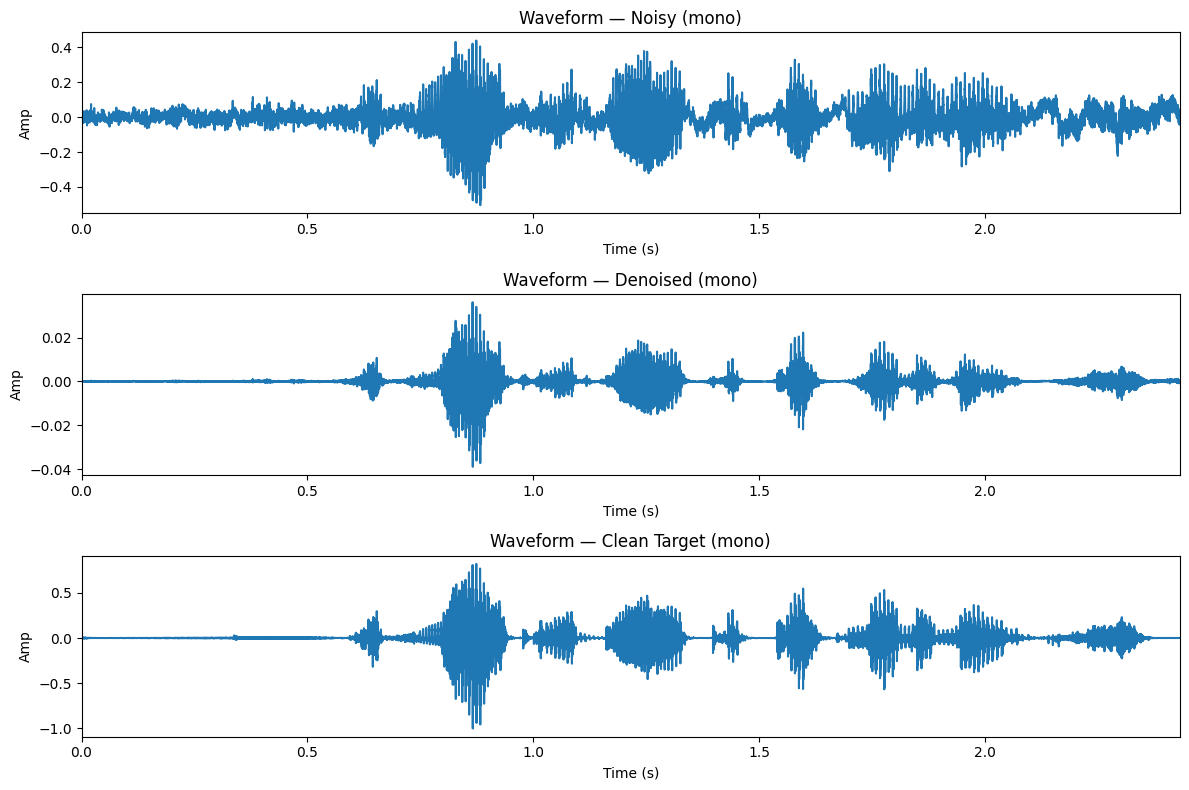

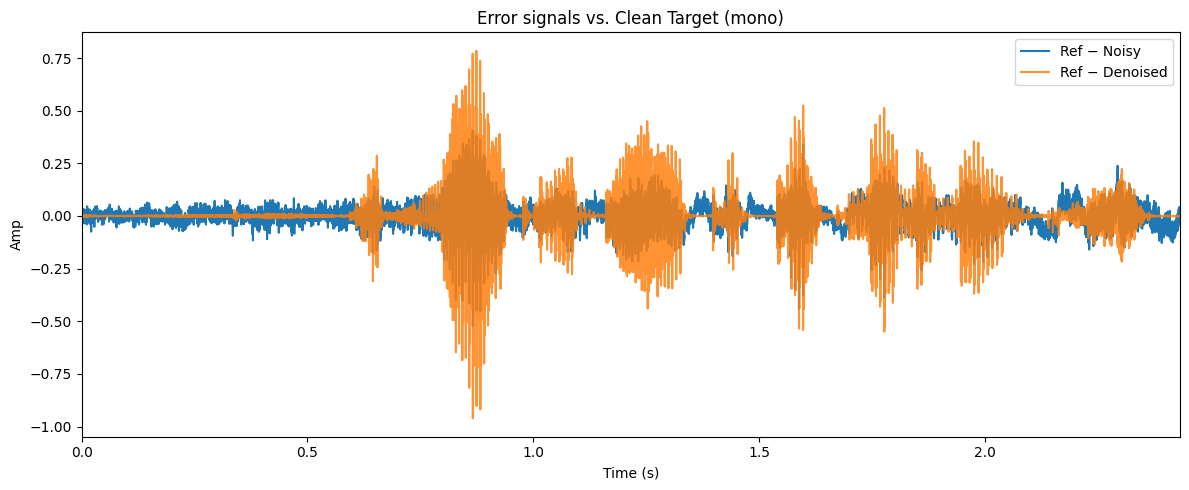

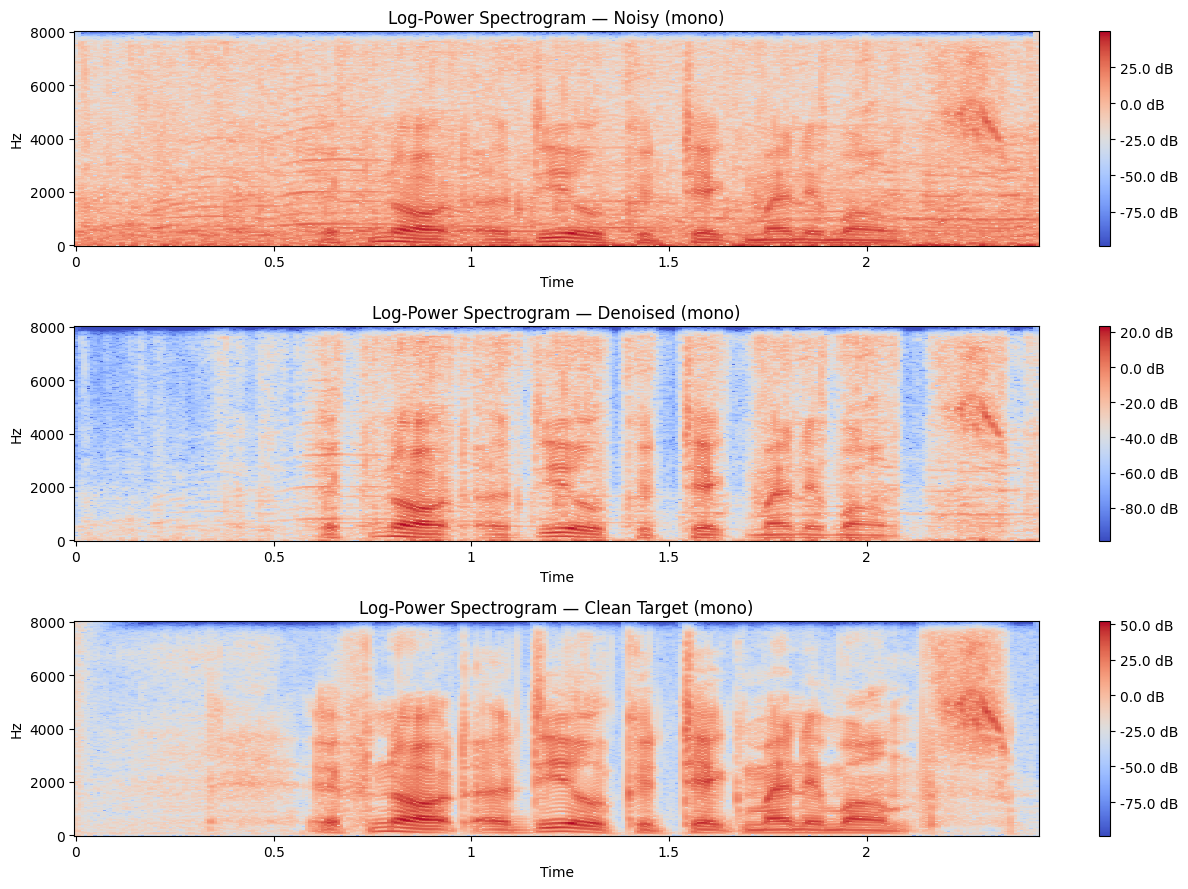

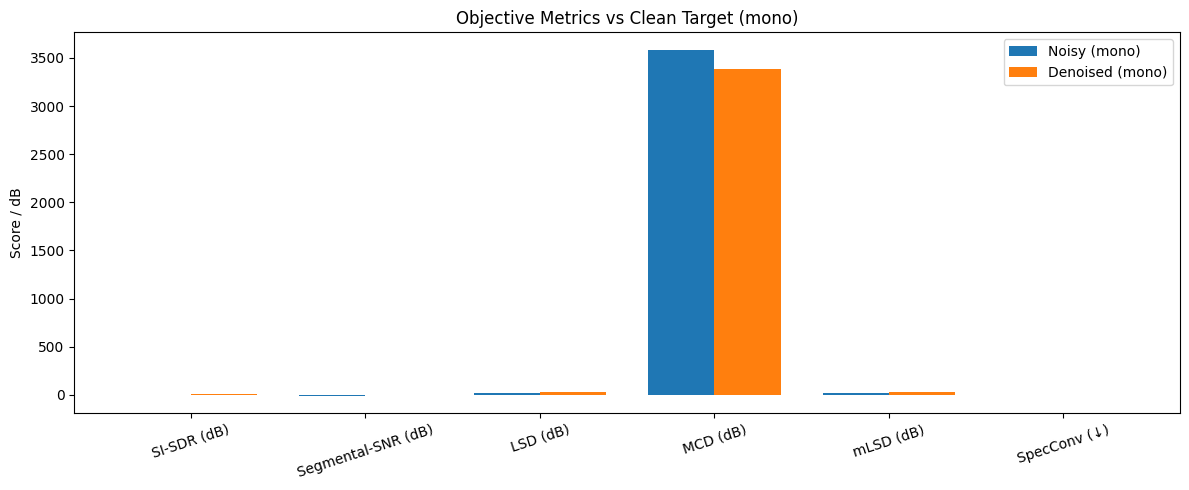

In [ ]:
# ===============================
# Visualization & Evaluation — Stage-1 Mono Denoising
#  * Pull one sample (prefers test_ds_mono)
#  * Predict mono with current model (mask on noisy mono STFT)
#  * Metrics vs mono clean target (enhanced-mono or clean)
#  * Plots: waveforms, errors, spectrograms, metric bars
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display
import torch
from IPython.display import display

# ---- 0) Numpy dtype shims for some librosa versions ----
if not hasattr(np, "complex"): np.complex = np.complex128
if not hasattr(np, "bool"):    np.bool    = np.bool_
if not hasattr(np, "object"):  np.object  = np.object_
if not hasattr(np, "float"):   np.float   = float

# ---- 1) Pull globals / fallbacks ----
DEVICE    = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR = int(globals().get("TARGET_SR", 16000))
N_FFT     = int(globals().get("N_FFT", 512))
HOP       = int(globals().get("HOP", 128))
WIN       = int(globals().get("WIN", 512))
USE_PHASE_HEAD = bool(globals().get("USE_PHASE_HEAD", False))

assert 'stft_mag_phase' in globals() and 'istft_from_mag_phase' in globals(), "The STFT/ISTFT helper functions stft_mag_phase/istft_from_mag_phase are missing."

mono_model = globals().get("mono_model", None)
assert mono_model is not None, "The mono_model is not defined. Please build and load the Stage-1 model first."

dataset = globals().get("test_ds_mono", None)
if dataset is None:
    dataset = globals().get("test_ds", None)
if dataset is None and 'test_dl' in globals():
    try:
        dataset = globals()['test_dl'].dataset
    except Exception:
        pass
assert dataset is not None, "Test set not found: Please provide test_ds_mono or test_ds (or test_dl.dataset)."

# ---- 2) Metric functions (no PESQ/STOI) ----
def si_sdr(ref, est, eps=1e-8):
    ref = ref - np.mean(ref)
    est = est - np.mean(est)
    t = (np.sum(est*ref) / (np.sum(ref*ref) + eps)) * ref
    n = est - t
    ratio = (np.sum(t*t) + eps) / (np.sum(n*n) + eps)
    return 10.0 * np.log10(ratio + eps)

def segmental_snr(ref, est, sr, frame_ms=20, eps=1e-12):
    N = len(ref); L = max(1, int(sr * frame_ms / 1000.0))
    acc, num = 0.0, 0
    for i in range(0, N, L):
        r = ref[i:i+L]; e = est[i:i+L]
        if len(r) < 2: continue
        snr = 10*np.log10((np.sum(r*r)+eps) / (np.sum((r-e)*(r-e))+eps))
        acc += snr; num += 1
    return acc/num if num > 0 else np.nan

def log_spectral_distance_db(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    Rdb = 20*np.log10(R); Edb = 20*np.log10(E)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def mcd_db(ref, est, sr=TARGET_SR, n_mfcc=13, drop_c0=True, lifter=22, eps=1e-12):
    mfcc_r = librosa.feature.mfcc(y=ref, sr=sr, n_mfcc=n_mfcc)
    mfcc_e = librosa.feature.mfcc(y=est, sr=sr, n_mfcc=n_mfcc)
    if lifter:
        lif = 1 + (lifter/2.)*np.sin(np.pi*np.arange(n_mfcc)/lifter)[:, None]
        mfcc_r *= lif; mfcc_e *= lif
    if drop_c0 and mfcc_r.shape[0] > 1:
        mfcc_r = mfcc_r[1:, :]; mfcc_e = mfcc_e[1:, :]
    T = min(mfcc_r.shape[1], mfcc_e.shape[1])
    if T <= 1: return np.nan
    diff = mfcc_r[:, :T] - mfcc_e[:, :T]
    coef = 10.0/np.log(10.0) * np.sqrt(2.0)  # ≈ 6.14185
    return coef * np.mean(np.sqrt(np.sum(diff*diff, axis=0) + eps))

def mel_lsd_db(ref, est, sr=TARGET_SR, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    S_r = librosa.feature.melspectrogram(y=ref, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    S_e = librosa.feature.melspectrogram(y=est, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    L = min(S_r.shape[1], S_e.shape[1])
    S_r = S_r[:, :L]; S_e = S_e[:, :L]
    Rdb = 10*np.log10(S_r); Edb = 10*np.log10(S_e)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def spectral_convergence(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    num = np.linalg.norm(R - E, ord='fro')
    den = np.linalg.norm(R, ord='fro') + eps
    return float(num / den)

# ---- 3) Mono forward (Compatible with or not with phase head) ----
@torch.no_grad()
def predict_mono(noisy_1d: torch.Tensor):
    """
    noisy_1d: torch.Tensor [T] (CPU)
    returns: est_deno [T] (np.float32)
    """
    mono_model.eval()
    x = noisy_1d.unsqueeze(0).to(DEVICE)  # [1,T]

    mag_n, ph_n = stft_mag_phase(x)                   # [1,F,T], complex
    inp = torch.log1p(mag_n).unsqueeze(1)             # [1,1,F,T]
    out = mono_model(inp)

    if isinstance(out, (tuple, list)) and len(out) == 2:
        mask, dphi = out                               # [1,1,F,T], [1,1,F,T]
        if mask.dim() == 3: mask = mask.unsqueeze(1)
        est_mag = mask[:, 0] * mag_n                  # [1,F,T]
        # 相位旋转（若有相位头）
        eps = 1e-8
        unit = ph_n / (torch.abs(ph_n) + eps)         # e^{j φ_noisy}
        rot  = torch.complex(torch.cos(dphi[:, 0]), torch.sin(dphi[:, 0]))
        Xest = est_mag * (unit * rot)
        # window 必须是实数 dtype（避免 complex window 报错）
        win = torch.hann_window(WIN, device=Xest.device, dtype=torch.float32)
        T_len = x.shape[-1]
        est = torch.istft(Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                          window=win, center=True, length=T_len)  # [1,T]
    else:
        mask = out
        if mask.dim() == 3: mask = mask.unsqueeze(1)  # [1,1,F,T]
        est_mag = mask[:, 0] * mag_n
        # 使用 noisy 相位复原
        T_len = x.shape[-1]
        est = istft_from_mag_phase(est_mag, ph_n)     # [1,T]

    return est[0].detach().float().cpu().numpy().astype(np.float32, copy=False)

# ---- 4) Fetch one sample & predict ----
with torch.no_grad():
    idx = int(np.random.randint(0, len(dataset)))
    item = dataset[idx]
    if isinstance(item, (tuple, list)) and len(item) >= 2:
        noisy_t, clean_t = item[0], item[1]
    else:
        noisy_t, clean_t = item, item

    if torch.is_tensor(clean_t) and clean_t.dim() == 3:
        clean_t = clean_t.mean(dim=0)  # [T]
    elif torch.is_tensor(clean_t) and clean_t.dim() == 2 and clean_t.shape[0] == 2:
        clean_t = clean_t.mean(dim=0)

    est = predict_mono(noisy_t)  # [T]

# ---- 5) Numpy & length alignment ----
noisy = (noisy_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(noisy_t)
         else np.asarray(noisy_t, dtype=np.float32))
clean = (clean_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(clean_t)
         else np.asarray(clean_t, dtype=np.float32))

Lmin = int(min(len(noisy), len(clean), len(est)))
noisy = noisy[:Lmin]; clean = clean[:Lmin]; est = est[:Lmin]
sr = TARGET_SR

# ---- 6) Calculate metrics ----
def eval_pair(ref, deg, sr):
    return {
        "SI-SDR (dB)":        si_sdr(ref, deg),
        "Segmental-SNR (dB)": segmental_snr(ref, deg, sr),
        "LSD (dB)":           log_spectral_distance_db(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "MCD (dB)":           mcd_db(ref, deg, sr, n_mfcc=13, drop_c0=True, lifter=22),
        "mLSD (dB)":          mel_lsd_db(ref, deg, sr, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "SpecConv (↓)":       spectral_convergence(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
    }

metrics_noisy = eval_pair(clean, noisy, sr)
metrics_deno  = eval_pair(clean, est,   sr)

df = pd.DataFrame([metrics_noisy, metrics_deno],
                  index=["Noisy → CleanTarget(mono)", "Denoised → CleanTarget(mono)"])

def delta(a, b):
    if a is None or b is None or (isinstance(a, float) and np.isnan(a)) or (isinstance(b, float) and np.isnan(b)):
        return None
    return b - a

improve = {
    "Δ SI-SDR (dB)":   delta(metrics_noisy["SI-SDR (dB)"],        metrics_deno["SI-SDR (dB)"]),
    "Δ SegSNR (dB)":   delta(metrics_noisy["Segmental-SNR (dB)"], metrics_deno["Segmental-SNR (dB)"]),
    "Δ LSD (dB)↓":     delta(metrics_noisy["LSD (dB)"],           metrics_deno["LSD (dB)"]),
    "Δ MCD (dB)↓":     delta(metrics_noisy["MCD (dB)"],           metrics_deno["MCD (dB)"]),
    "Δ mLSD (dB)↓":    delta(metrics_noisy["mLSD (dB)"],          metrics_deno["mLSD (dB)"]),
    "Δ SpecConv↓":     delta(metrics_noisy["SpecConv (↓)"],       metrics_deno["SpecConv (↓)"]),
}
df_improve = pd.DataFrame([improve], index=["Improvement (Denoised − Noisy)"])

with pd.option_context("display.precision", 3):
    print(f"\n=== Objective Metrics (idx={idx}) ===")
    display(df)
    print("\n=== Improvements (Denoised − Noisy) ===")
    display(df_improve)

# ---- 7) Visualization: Waveforms & Spectra ----
dur = len(clean)/sr
t = np.arange(len(clean))/sr

plt.figure(figsize=(12, 8))
plt.subplot(3,1,1); plt.plot(t, noisy); plt.title("Waveform — Noisy (mono)");    plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,2); plt.plot(t, est);   plt.title("Waveform — Denoised (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,3); plt.plot(t, clean); plt.title("Waveform — Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.tight_layout(); plt.show()

# waveform error
err_noisy = clean - noisy
err_deno  = clean - est
plt.figure(figsize=(12,5))
plt.plot(t, err_noisy, label="Ref − Noisy")
plt.plot(t, err_deno,  label="Ref − Denoised", alpha=0.85)
plt.title("Error signals vs. Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur); plt.legend(); plt.tight_layout(); plt.show()

# Spectrum (logarithmic power spectrum) — Normalize with the average power of ref as a reference to avoid overall gain bias
def spec_db(y, sr, n_fft=N_FFT, hop=HOP, win_length=WIN, ref_power=1.0, eps=1e-12):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop, win_length=win_length))**2
    return 10*np.log10(S + eps) - 10*np.log10(ref_power + eps)

ref_pow = float(np.mean(clean.astype(np.float64)**2) + 1e-12)
S_noisy = spec_db(noisy, sr, ref_power=ref_pow)
S_deno  = spec_db(est,   sr, ref_power=ref_pow)
S_clean = spec_db(clean, sr, ref_power=ref_pow)

plt.figure(figsize=(13,9))
ax1 = plt.subplot(3,1,1); librosa.display.specshow(S_noisy, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Noisy (mono)");    plt.colorbar(ax=ax1, format="%.1f dB")
ax2 = plt.subplot(3,1,2); librosa.display.specshow(S_deno,  sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Denoised (mono)");  plt.colorbar(ax=ax2, format="%.1f dB")
ax3 = plt.subplot(3,1,3); librosa.display.specshow(S_clean, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Clean Target (mono)");     plt.colorbar(ax=ax3, format="%.1f dB")
plt.tight_layout(); plt.show()

# ---- 8) Indicator comparison bar chart ----
labels = ["SI-SDR (dB)", "Segmental-SNR (dB)", "LSD (dB)", "MCD (dB)", "mLSD (dB)", "SpecConv (↓)"]
noisy_vals = [metrics_noisy[k] for k in labels]
deno_vals  = [metrics_deno[k]  for k in labels]
x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(12,5))
plt.bar(x - w/2, noisy_vals, width=w, label="Noisy (mono)")
plt.bar(x + w/2, deno_vals,  width=w, label="Denoised (mono)")
plt.xticks(x, labels, rotation=18); plt.title("Objective Metrics vs Clean Target (mono)"); plt.ylabel("Score / dB")
plt.legend(); plt.tight_layout(); plt.show()



=== Objective Metrics (idx=347) ===


,SI-SDR (dB),Segmental-SNR (dB),LSD (dB),MCD (dB),mLSD (dB),SpecConv (↓)
Noisy → CleanTarget(mono),-0.590,-12.195,19.545,4040.568,18.829,0.843
Denoised → CleanTarget(mono),6.461,-0.051,26.773,3901.625,27.311,0.972



=== Improvements (Denoised − Noisy) ===


,Δ SI-SDR (dB),Δ SegSNR (dB),Δ LSD (dB)↓,Δ MCD (dB)↓,Δ mLSD (dB)↓,Δ SpecConv↓
Improvement (Denoised − Noisy),7.051,12.144,7.228,-138.943,8.482,0.129


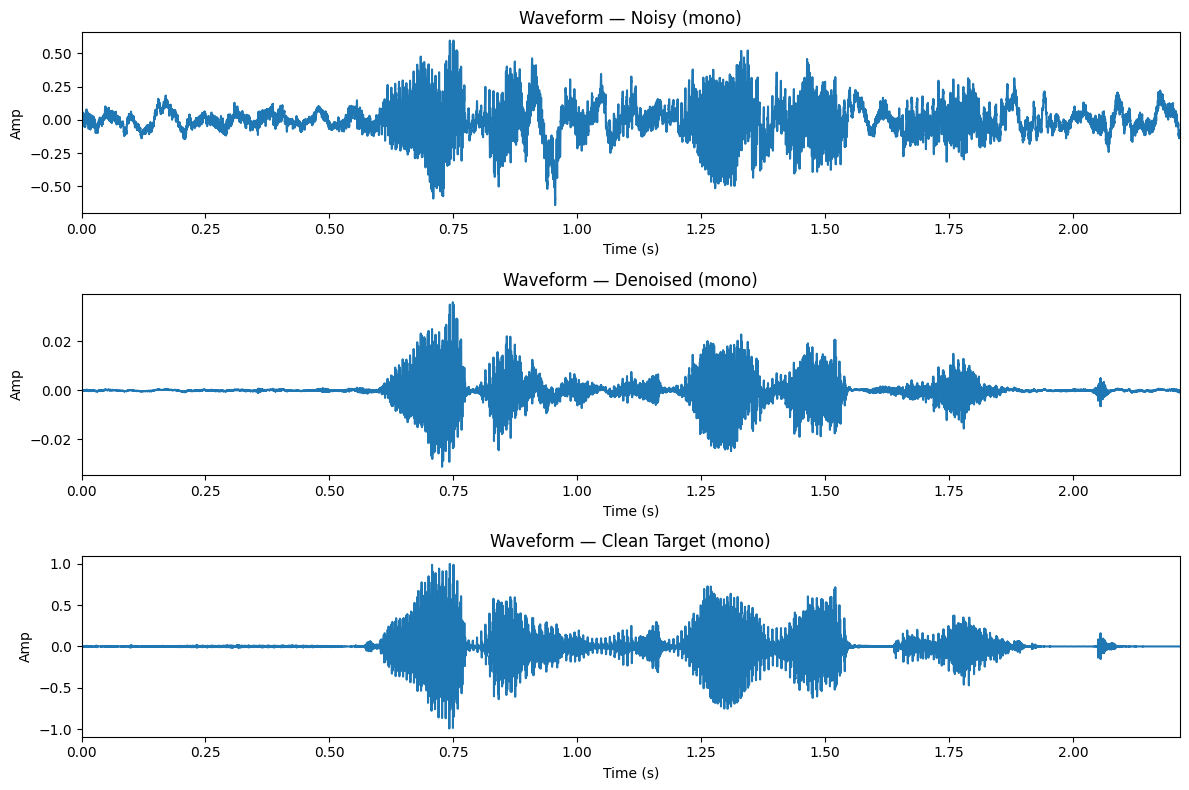

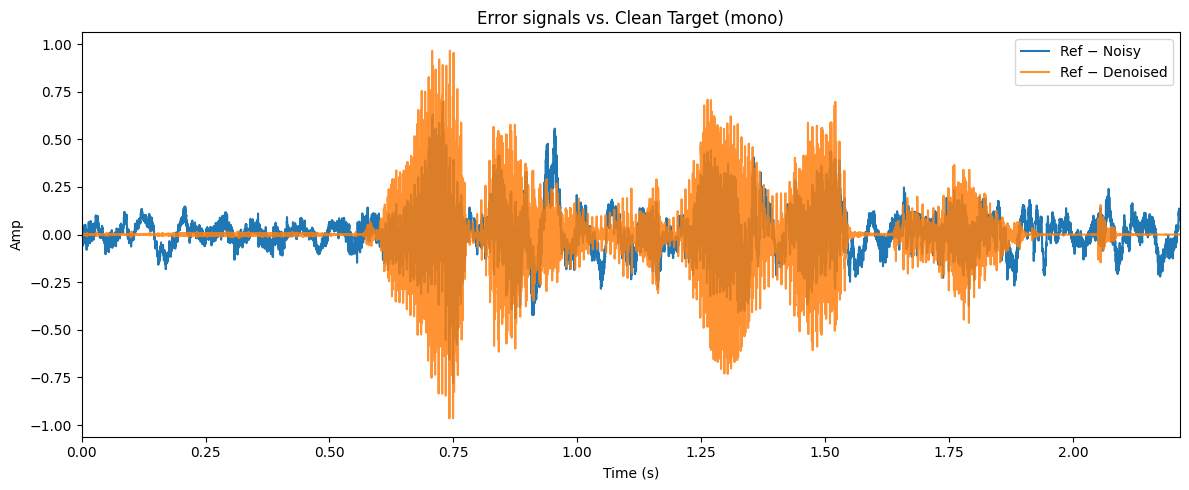

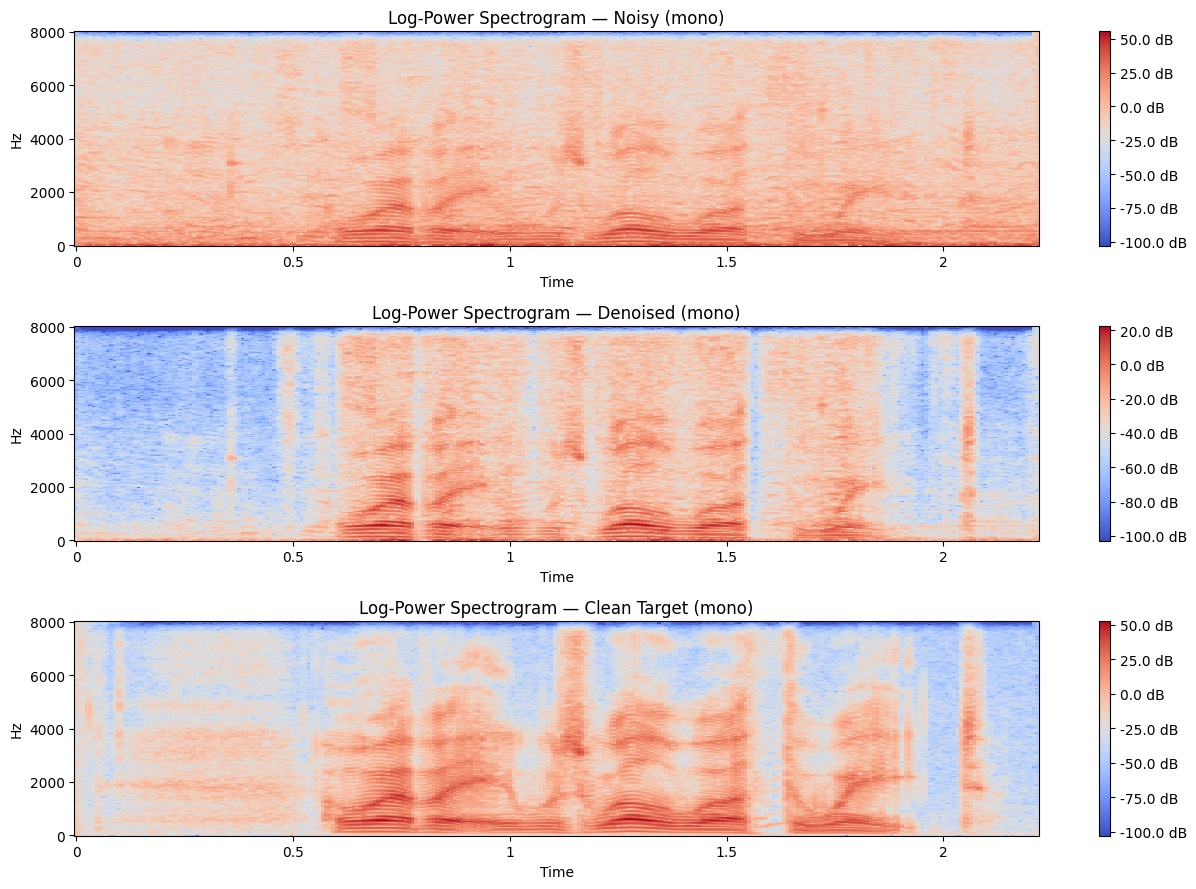

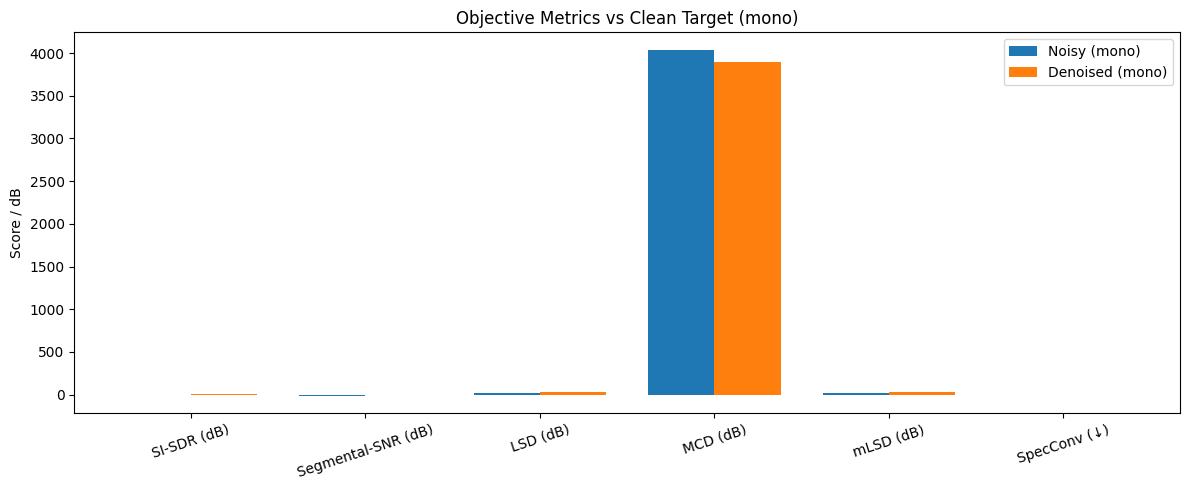

In [ ]:
# ===============================
# Visualization & Evaluation — Stage-1 Mono Denoising
#  * Pull one sample (prefers test_ds_mono)
#  * Predict mono with current model (mask on noisy mono STFT)
#  * Metrics vs mono clean target (enhanced-mono or clean)
#  * Plots: waveforms, errors, spectrograms, metric bars
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display
import torch
from IPython.display import display

# ---- 0) Numpy dtype shims for some librosa versions ----
if not hasattr(np, "complex"): np.complex = np.complex128
if not hasattr(np, "bool"):    np.bool    = np.bool_
if not hasattr(np, "object"):  np.object  = np.object_
if not hasattr(np, "float"):   np.float   = float

# ---- 1) Pull globals / fallbacks ----
DEVICE    = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR = int(globals().get("TARGET_SR", 16000))
N_FFT     = int(globals().get("N_FFT", 512))
HOP       = int(globals().get("HOP", 128))
WIN       = int(globals().get("WIN", 512))
USE_PHASE_HEAD = bool(globals().get("USE_PHASE_HEAD", False))

assert 'stft_mag_phase' in globals() and 'istft_from_mag_phase' in globals(), "The STFT/ISTFT helper functions stft_mag_phase/istft_from_mag_phase are missing."

mono_model = globals().get("mono_model", None)
assert mono_model is not None, "The mono_model is not defined. Please build and load the Stage-1 model first."

dataset = globals().get("test_ds_mono", None)
if dataset is None:
    dataset = globals().get("test_ds", None)
if dataset is None and 'test_dl' in globals():
    try:
        dataset = globals()['test_dl'].dataset
    except Exception:
        pass
assert dataset is not None, "Test set not found: Please provide test_ds_mono or test_ds (or test_dl.dataset)."

# ---- 2) Metric functions (no PESQ/STOI) ----
def si_sdr(ref, est, eps=1e-8):
    ref = ref - np.mean(ref)
    est = est - np.mean(est)
    t = (np.sum(est*ref) / (np.sum(ref*ref) + eps)) * ref
    n = est - t
    ratio = (np.sum(t*t) + eps) / (np.sum(n*n) + eps)
    return 10.0 * np.log10(ratio + eps)

def segmental_snr(ref, est, sr, frame_ms=20, eps=1e-12):
    N = len(ref); L = max(1, int(sr * frame_ms / 1000.0))
    acc, num = 0.0, 0
    for i in range(0, N, L):
        r = ref[i:i+L]; e = est[i:i+L]
        if len(r) < 2: continue
        snr = 10*np.log10((np.sum(r*r)+eps) / (np.sum((r-e)*(r-e))+eps))
        acc += snr; num += 1
    return acc/num if num > 0 else np.nan

def log_spectral_distance_db(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    Rdb = 20*np.log10(R); Edb = 20*np.log10(E)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def mcd_db(ref, est, sr=TARGET_SR, n_mfcc=13, drop_c0=True, lifter=22, eps=1e-12):
    mfcc_r = librosa.feature.mfcc(y=ref, sr=sr, n_mfcc=n_mfcc)
    mfcc_e = librosa.feature.mfcc(y=est, sr=sr, n_mfcc=n_mfcc)
    if lifter:
        lif = 1 + (lifter/2.)*np.sin(np.pi*np.arange(n_mfcc)/lifter)[:, None]
        mfcc_r *= lif; mfcc_e *= lif
    if drop_c0 and mfcc_r.shape[0] > 1:
        mfcc_r = mfcc_r[1:, :]; mfcc_e = mfcc_e[1:, :]
    T = min(mfcc_r.shape[1], mfcc_e.shape[1])
    if T <= 1: return np.nan
    diff = mfcc_r[:, :T] - mfcc_e[:, :T]
    coef = 10.0/np.log(10.0) * np.sqrt(2.0)  # ≈ 6.14185
    return coef * np.mean(np.sqrt(np.sum(diff*diff, axis=0) + eps))

def mel_lsd_db(ref, est, sr=TARGET_SR, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    S_r = librosa.feature.melspectrogram(y=ref, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    S_e = librosa.feature.melspectrogram(y=est, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    L = min(S_r.shape[1], S_e.shape[1])
    S_r = S_r[:, :L]; S_e = S_e[:, :L]
    Rdb = 10*np.log10(S_r); Edb = 10*np.log10(S_e)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def spectral_convergence(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    num = np.linalg.norm(R - E, ord='fro')
    den = np.linalg.norm(R, ord='fro') + eps
    return float(num / den)

# ---- 3) Mono forward (Compatible with or not with phase head) ----
@torch.no_grad()
def predict_mono(noisy_1d: torch.Tensor):
    """
    noisy_1d: torch.Tensor [T] (CPU)
    returns: est_deno [T] (np.float32)
    """
    mono_model.eval()
    x = noisy_1d.unsqueeze(0).to(DEVICE)  # [1,T]

    mag_n, ph_n = stft_mag_phase(x)                   # [1,F,T], complex
    inp = torch.log1p(mag_n).unsqueeze(1)             # [1,1,F,T]
    out = mono_model(inp)

    if isinstance(out, (tuple, list)) and len(out) == 2:
        mask, dphi = out                               # [1,1,F,T], [1,1,F,T]
        if mask.dim() == 3: mask = mask.unsqueeze(1)
        est_mag = mask[:, 0] * mag_n                  # [1,F,T]
        eps = 1e-8
        unit = ph_n / (torch.abs(ph_n) + eps)         # e^{j φ_noisy}
        rot  = torch.complex(torch.cos(dphi[:, 0]), torch.sin(dphi[:, 0]))
        Xest = est_mag * (unit * rot)
        win = torch.hann_window(WIN, device=Xest.device, dtype=torch.float32)
        T_len = x.shape[-1]
        est = torch.istft(Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                          window=win, center=True, length=T_len)  # [1,T]
    else:
        mask = out
        if mask.dim() == 3: mask = mask.unsqueeze(1)  # [1,1,F,T]
        est_mag = mask[:, 0] * mag_n
        T_len = x.shape[-1]
        est = istft_from_mag_phase(est_mag, ph_n)     # [1,T]

    return est[0].detach().float().cpu().numpy().astype(np.float32, copy=False)

# ---- 4) Fetch one sample & predict ----
with torch.no_grad():
    idx = int(np.random.randint(0, len(dataset)))
    item = dataset[idx]
    if isinstance(item, (tuple, list)) and len(item) >= 2:
        noisy_t, clean_t = item[0], item[1]
    else:
        noisy_t, clean_t = item, item

    if torch.is_tensor(clean_t) and clean_t.dim() == 3:
        clean_t = clean_t.mean(dim=0)  # [T]
    elif torch.is_tensor(clean_t) and clean_t.dim() == 2 and clean_t.shape[0] == 2:
        clean_t = clean_t.mean(dim=0)

    est = predict_mono(noisy_t)  # [T]

# ---- 5) Numpy & length alignment ----
noisy = (noisy_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(noisy_t)
         else np.asarray(noisy_t, dtype=np.float32))
clean = (clean_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(clean_t)
         else np.asarray(clean_t, dtype=np.float32))

Lmin = int(min(len(noisy), len(clean), len(est)))
noisy = noisy[:Lmin]; clean = clean[:Lmin]; est = est[:Lmin]
sr = TARGET_SR

# ---- 6) Calculate metrics ----
def eval_pair(ref, deg, sr):
    return {
        "SI-SDR (dB)":        si_sdr(ref, deg),
        "Segmental-SNR (dB)": segmental_snr(ref, deg, sr),
        "LSD (dB)":           log_spectral_distance_db(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "MCD (dB)":           mcd_db(ref, deg, sr, n_mfcc=13, drop_c0=True, lifter=22),
        "mLSD (dB)":          mel_lsd_db(ref, deg, sr, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "SpecConv (↓)":       spectral_convergence(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
    }

metrics_noisy = eval_pair(clean, noisy, sr)
metrics_deno  = eval_pair(clean, est,   sr)

df = pd.DataFrame([metrics_noisy, metrics_deno],
                  index=["Noisy → CleanTarget(mono)", "Denoised → CleanTarget(mono)"])

def delta(a, b):
    if a is None or b is None or (isinstance(a, float) and np.isnan(a)) or (isinstance(b, float) and np.isnan(b)):
        return None
    return b - a

improve = {
    "Δ SI-SDR (dB)":   delta(metrics_noisy["SI-SDR (dB)"],        metrics_deno["SI-SDR (dB)"]),
    "Δ SegSNR (dB)":   delta(metrics_noisy["Segmental-SNR (dB)"], metrics_deno["Segmental-SNR (dB)"]),
    "Δ LSD (dB)↓":     delta(metrics_noisy["LSD (dB)"],           metrics_deno["LSD (dB)"]),
    "Δ MCD (dB)↓":     delta(metrics_noisy["MCD (dB)"],           metrics_deno["MCD (dB)"]),
    "Δ mLSD (dB)↓":    delta(metrics_noisy["mLSD (dB)"],          metrics_deno["mLSD (dB)"]),
    "Δ SpecConv↓":     delta(metrics_noisy["SpecConv (↓)"],       metrics_deno["SpecConv (↓)"]),
}
df_improve = pd.DataFrame([improve], index=["Improvement (Denoised − Noisy)"])

with pd.option_context("display.precision", 3):
    print(f"\n=== Objective Metrics (idx={idx}) ===")
    display(df)
    print("\n=== Improvements (Denoised − Noisy) ===")
    display(df_improve)

# ---- 7) Visualization: Waveforms & Spectra ----
dur = len(clean)/sr
t = np.arange(len(clean))/sr

plt.figure(figsize=(12, 8))
plt.subplot(3,1,1); plt.plot(t, noisy); plt.title("Waveform — Noisy (mono)");    plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,2); plt.plot(t, est);   plt.title("Waveform — Denoised (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,3); plt.plot(t, clean); plt.title("Waveform — Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.tight_layout(); plt.show()

# waveform error
err_noisy = clean - noisy
err_deno  = clean - est
plt.figure(figsize=(12,5))
plt.plot(t, err_noisy, label="Ref − Noisy")
plt.plot(t, err_deno,  label="Ref − Denoised", alpha=0.85)
plt.title("Error signals vs. Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur); plt.legend(); plt.tight_layout(); plt.show()

# Spectrum (logarithmic power spectrum) - Use the average power of ref as a reference for normalization to avoid overall gain bias
def spec_db(y, sr, n_fft=N_FFT, hop=HOP, win_length=WIN, ref_power=1.0, eps=1e-12):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop, win_length=win_length))**2
    return 10*np.log10(S + eps) - 10*np.log10(ref_power + eps)

ref_pow = float(np.mean(clean.astype(np.float64)**2) + 1e-12)
S_noisy = spec_db(noisy, sr, ref_power=ref_pow)
S_deno  = spec_db(est,   sr, ref_power=ref_pow)
S_clean = spec_db(clean, sr, ref_power=ref_pow)

plt.figure(figsize=(13,9))
ax1 = plt.subplot(3,1,1); librosa.display.specshow(S_noisy, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Noisy (mono)");    plt.colorbar(ax=ax1, format="%.1f dB")
ax2 = plt.subplot(3,1,2); librosa.display.specshow(S_deno,  sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Denoised (mono)");  plt.colorbar(ax=ax2, format="%.1f dB")
ax3 = plt.subplot(3,1,3); librosa.display.specshow(S_clean, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Clean Target (mono)");     plt.colorbar(ax=ax3, format="%.1f dB")
plt.tight_layout(); plt.show()

# ---- 8) Indicator comparison bar chart ----
labels = ["SI-SDR (dB)", "Segmental-SNR (dB)", "LSD (dB)", "MCD (dB)", "mLSD (dB)", "SpecConv (↓)"]
noisy_vals = [metrics_noisy[k] for k in labels]
deno_vals  = [metrics_deno[k]  for k in labels]
x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(12,5))
plt.bar(x - w/2, noisy_vals, width=w, label="Noisy (mono)")
plt.bar(x + w/2, deno_vals,  width=w, label="Denoised (mono)")
plt.xticks(x, labels, rotation=18); plt.title("Objective Metrics vs Clean Target (mono)"); plt.ylabel("Score / dB")
plt.legend(); plt.tight_layout(); plt.show()



=== Objective Metrics (idx=282) ===


,SI-SDR (dB),Segmental-SNR (dB),LSD (dB),MCD (dB),mLSD (dB),SpecConv (↓)
Noisy → CleanTarget(mono),1.231,-13.157,13.075,3536.516,12.192,0.681
Denoised → CleanTarget(mono),8.668,0.049,31.213,3321.543,32.535,0.972



=== Improvements (Denoised − Noisy) ===


,Δ SI-SDR (dB),Δ SegSNR (dB),Δ LSD (dB)↓,Δ MCD (dB)↓,Δ mLSD (dB)↓,Δ SpecConv↓
Improvement (Denoised − Noisy),7.438,13.206,18.138,-214.973,20.342,0.29


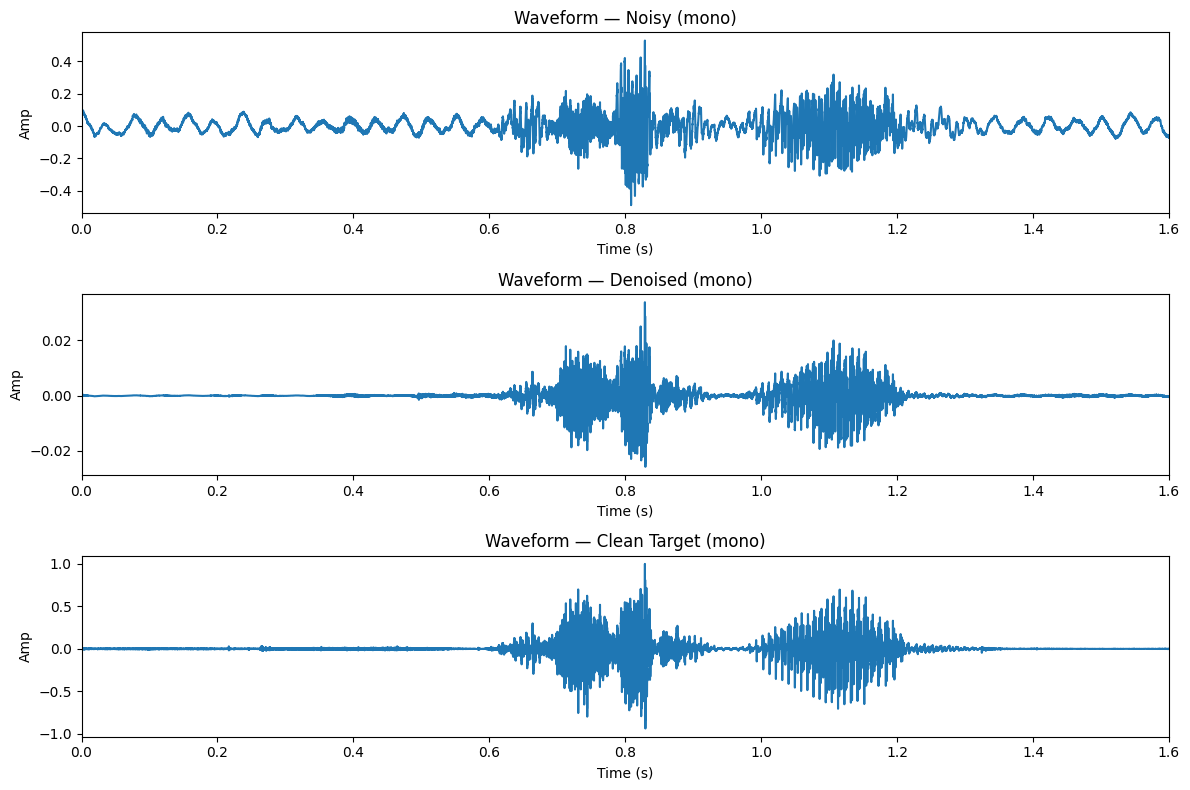

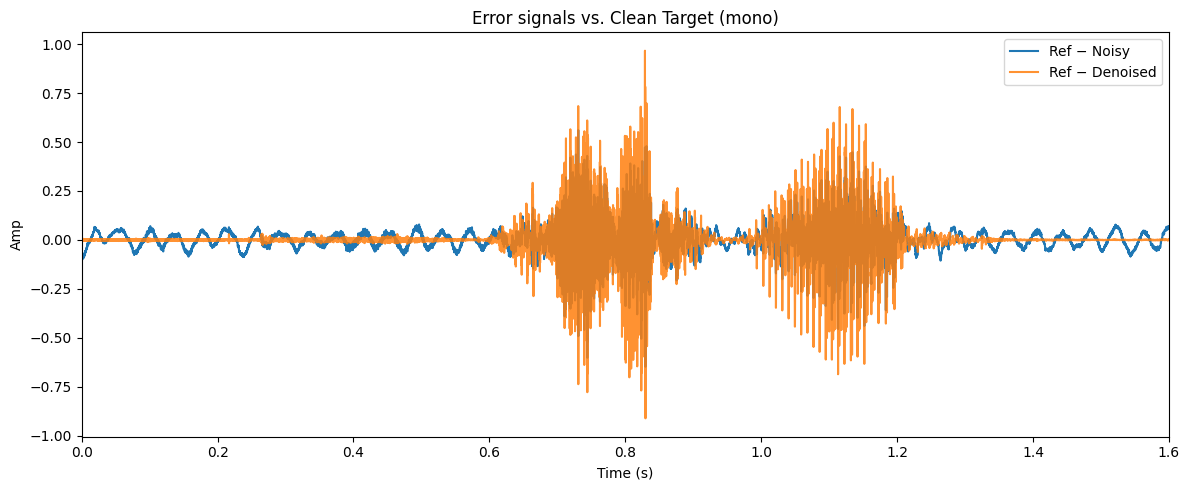

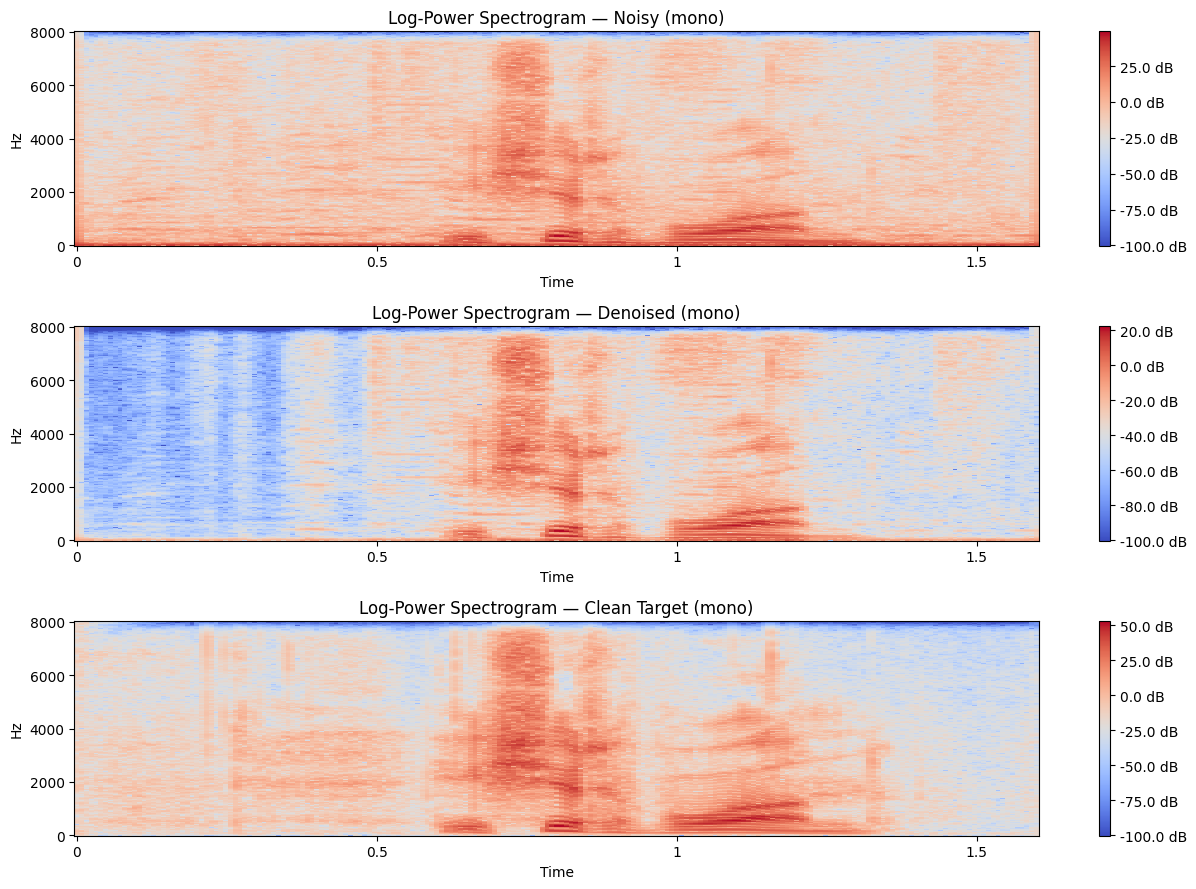

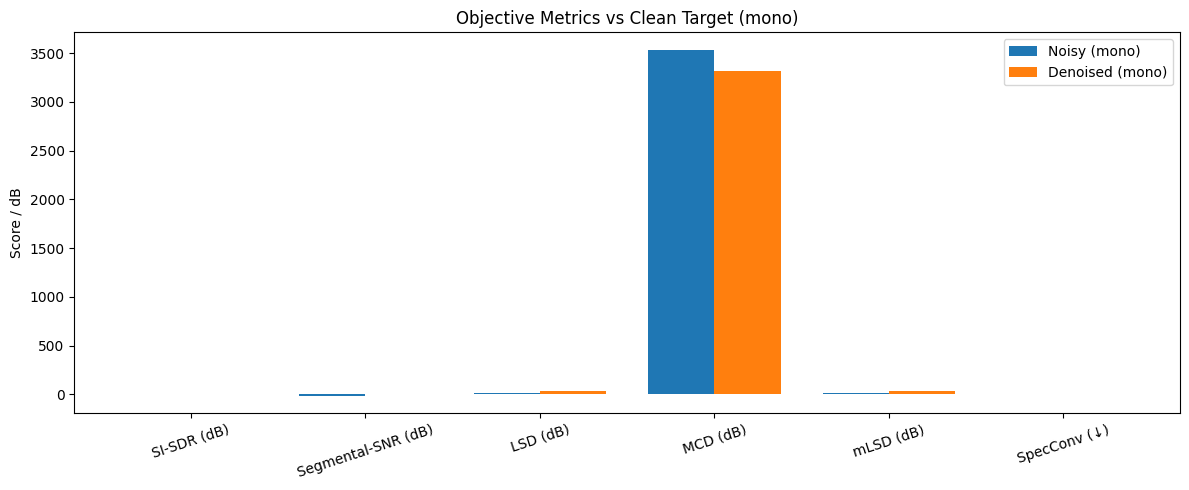

In [ ]:
# ===============================
# Visualization & Evaluation — Stage-1 Mono Denoising
#  * Pull one sample (prefers test_ds_mono)
#  * Predict mono with current model (mask on noisy mono STFT)
#  * Metrics vs mono clean target (enhanced-mono or clean)
#  * Plots: waveforms, errors, spectrograms, metric bars
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display
import torch
from IPython.display import display

# ---- 0) Numpy dtype shims for some librosa versions ----
if not hasattr(np, "complex"): np.complex = np.complex128
if not hasattr(np, "bool"):    np.bool    = np.bool_
if not hasattr(np, "object"):  np.object  = np.object_
if not hasattr(np, "float"):   np.float   = float

# ---- 1) Pull globals / fallbacks ----
DEVICE    = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR = int(globals().get("TARGET_SR", 16000))
N_FFT     = int(globals().get("N_FFT", 512))
HOP       = int(globals().get("HOP", 128))
WIN       = int(globals().get("WIN", 512))
USE_PHASE_HEAD = bool(globals().get("USE_PHASE_HEAD", False))

assert 'stft_mag_phase' in globals() and 'istft_from_mag_phase' in globals(), "The STFT/ISTFT helper functions stft_mag_phase/istft_from_mag_phase are missing."

mono_model = globals().get("mono_model", None)
assert mono_model is not None, "The mono_model is not defined. Please build and load the Stage-1 model first."

dataset = globals().get("test_ds_mono", None)
if dataset is None:
    dataset = globals().get("test_ds", None)
if dataset is None and 'test_dl' in globals():
    try:
        dataset = globals()['test_dl'].dataset
    except Exception:
        pass
assert dataset is not None, "Test set not found: Please provide test_ds_mono or test_ds (or test_dl.dataset)."

# ---- 2) Metric functions (no PESQ/STOI) ----
def si_sdr(ref, est, eps=1e-8):
    ref = ref - np.mean(ref)
    est = est - np.mean(est)
    t = (np.sum(est*ref) / (np.sum(ref*ref) + eps)) * ref
    n = est - t
    ratio = (np.sum(t*t) + eps) / (np.sum(n*n) + eps)
    return 10.0 * np.log10(ratio + eps)

def segmental_snr(ref, est, sr, frame_ms=20, eps=1e-12):
    N = len(ref); L = max(1, int(sr * frame_ms / 1000.0))
    acc, num = 0.0, 0
    for i in range(0, N, L):
        r = ref[i:i+L]; e = est[i:i+L]
        if len(r) < 2: continue
        snr = 10*np.log10((np.sum(r*r)+eps) / (np.sum((r-e)*(r-e))+eps))
        acc += snr; num += 1
    return acc/num if num > 0 else np.nan

def log_spectral_distance_db(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    Rdb = 20*np.log10(R); Edb = 20*np.log10(E)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def mcd_db(ref, est, sr=TARGET_SR, n_mfcc=13, drop_c0=True, lifter=22, eps=1e-12):
    mfcc_r = librosa.feature.mfcc(y=ref, sr=sr, n_mfcc=n_mfcc)
    mfcc_e = librosa.feature.mfcc(y=est, sr=sr, n_mfcc=n_mfcc)
    if lifter:
        lif = 1 + (lifter/2.)*np.sin(np.pi*np.arange(n_mfcc)/lifter)[:, None]
        mfcc_r *= lif; mfcc_e *= lif
    if drop_c0 and mfcc_r.shape[0] > 1:
        mfcc_r = mfcc_r[1:, :]; mfcc_e = mfcc_e[1:, :]
    T = min(mfcc_r.shape[1], mfcc_e.shape[1])
    if T <= 1: return np.nan
    diff = mfcc_r[:, :T] - mfcc_e[:, :T]
    coef = 10.0/np.log(10.0) * np.sqrt(2.0)  # ≈ 6.14185
    return coef * np.mean(np.sqrt(np.sum(diff*diff, axis=0) + eps))

def mel_lsd_db(ref, est, sr=TARGET_SR, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    S_r = librosa.feature.melspectrogram(y=ref, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    S_e = librosa.feature.melspectrogram(y=est, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    L = min(S_r.shape[1], S_e.shape[1])
    S_r = S_r[:, :L]; S_e = S_e[:, :L]
    Rdb = 10*np.log10(S_r); Edb = 10*np.log10(S_e)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def spectral_convergence(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    num = np.linalg.norm(R - E, ord='fro')
    den = np.linalg.norm(R, ord='fro') + eps
    return float(num / den)

# ---- 3) Mono forward ----
@torch.no_grad()
def predict_mono(noisy_1d: torch.Tensor):
    """
    noisy_1d: torch.Tensor [T] (CPU)
    returns: est_deno [T] (np.float32)
    """
    mono_model.eval()
    x = noisy_1d.unsqueeze(0).to(DEVICE)  # [1,T]

    mag_n, ph_n = stft_mag_phase(x)                   # [1,F,T], complex
    inp = torch.log1p(mag_n).unsqueeze(1)             # [1,1,F,T]
    out = mono_model(inp)

    if isinstance(out, (tuple, list)) and len(out) == 2:
        mask, dphi = out                               # [1,1,F,T], [1,1,F,T]
        if mask.dim() == 3: mask = mask.unsqueeze(1)
        est_mag = mask[:, 0] * mag_n                  # [1,F,T]
        eps = 1e-8
        unit = ph_n / (torch.abs(ph_n) + eps)         # e^{j φ_noisy}
        rot  = torch.complex(torch.cos(dphi[:, 0]), torch.sin(dphi[:, 0]))
        Xest = est_mag * (unit * rot)
        win = torch.hann_window(WIN, device=Xest.device, dtype=torch.float32)
        T_len = x.shape[-1]
        est = torch.istft(Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                          window=win, center=True, length=T_len)  # [1,T]
    else:
        mask = out
        if mask.dim() == 3: mask = mask.unsqueeze(1)  # [1,1,F,T]
        est_mag = mask[:, 0] * mag_n
        T_len = x.shape[-1]
        est = istft_from_mag_phase(est_mag, ph_n)     # [1,T]

    return est[0].detach().float().cpu().numpy().astype(np.float32, copy=False)

# ---- 4) Fetch one sample & predict ----
with torch.no_grad():
    idx = int(np.random.randint(0, len(dataset)))
    item = dataset[idx]
    if isinstance(item, (tuple, list)) and len(item) >= 2:
        noisy_t, clean_t = item[0], item[1]
    else:
        noisy_t, clean_t = item, item

    if torch.is_tensor(clean_t) and clean_t.dim() == 3:
        clean_t = clean_t.mean(dim=0)  # [T]
    elif torch.is_tensor(clean_t) and clean_t.dim() == 2 and clean_t.shape[0] == 2:
        clean_t = clean_t.mean(dim=0)

    est = predict_mono(noisy_t)  # [T]

# ---- 5) Numpy & length alignment ----
noisy = (noisy_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(noisy_t)
         else np.asarray(noisy_t, dtype=np.float32))
clean = (clean_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(clean_t)
         else np.asarray(clean_t, dtype=np.float32))

Lmin = int(min(len(noisy), len(clean), len(est)))
noisy = noisy[:Lmin]; clean = clean[:Lmin]; est = est[:Lmin]
sr = TARGET_SR

# ---- 6) Calculate metrics ----
def eval_pair(ref, deg, sr):
    return {
        "SI-SDR (dB)":        si_sdr(ref, deg),
        "Segmental-SNR (dB)": segmental_snr(ref, deg, sr),
        "LSD (dB)":           log_spectral_distance_db(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "MCD (dB)":           mcd_db(ref, deg, sr, n_mfcc=13, drop_c0=True, lifter=22),
        "mLSD (dB)":          mel_lsd_db(ref, deg, sr, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "SpecConv (↓)":       spectral_convergence(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
    }

metrics_noisy = eval_pair(clean, noisy, sr)
metrics_deno  = eval_pair(clean, est,   sr)

df = pd.DataFrame([metrics_noisy, metrics_deno],
                  index=["Noisy → CleanTarget(mono)", "Denoised → CleanTarget(mono)"])

def delta(a, b):
    if a is None or b is None or (isinstance(a, float) and np.isnan(a)) or (isinstance(b, float) and np.isnan(b)):
        return None
    return b - a

improve = {
    "Δ SI-SDR (dB)":   delta(metrics_noisy["SI-SDR (dB)"],        metrics_deno["SI-SDR (dB)"]),
    "Δ SegSNR (dB)":   delta(metrics_noisy["Segmental-SNR (dB)"], metrics_deno["Segmental-SNR (dB)"]),
    "Δ LSD (dB)↓":     delta(metrics_noisy["LSD (dB)"],           metrics_deno["LSD (dB)"]),
    "Δ MCD (dB)↓":     delta(metrics_noisy["MCD (dB)"],           metrics_deno["MCD (dB)"]),
    "Δ mLSD (dB)↓":    delta(metrics_noisy["mLSD (dB)"],          metrics_deno["mLSD (dB)"]),
    "Δ SpecConv↓":     delta(metrics_noisy["SpecConv (↓)"],       metrics_deno["SpecConv (↓)"]),
}
df_improve = pd.DataFrame([improve], index=["Improvement (Denoised − Noisy)"])

with pd.option_context("display.precision", 3):
    print(f"\n=== Objective Metrics (idx={idx}) ===")
    display(df)
    print("\n=== Improvements (Denoised − Noisy) ===")
    display(df_improve)

# ---- 7) Visualization: Waveforms & Spectra ----
dur = len(clean)/sr
t = np.arange(len(clean))/sr

plt.figure(figsize=(12, 8))
plt.subplot(3,1,1); plt.plot(t, noisy); plt.title("Waveform — Noisy (mono)");    plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,2); plt.plot(t, est);   plt.title("Waveform — Denoised (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,3); plt.plot(t, clean); plt.title("Waveform — Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.tight_layout(); plt.show()

# waveform error
err_noisy = clean - noisy
err_deno  = clean - est
plt.figure(figsize=(12,5))
plt.plot(t, err_noisy, label="Ref − Noisy")
plt.plot(t, err_deno,  label="Ref − Denoised", alpha=0.85)
plt.title("Error signals vs. Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur); plt.legend(); plt.tight_layout(); plt.show()

# Spectrum (logarithmic power spectrum) - Normalize with the average power of ref as the reference to avoid overall gain bias.
def spec_db(y, sr, n_fft=N_FFT, hop=HOP, win_length=WIN, ref_power=1.0, eps=1e-12):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop, win_length=win_length))**2
    return 10*np.log10(S + eps) - 10*np.log10(ref_power + eps)

ref_pow = float(np.mean(clean.astype(np.float64)**2) + 1e-12)
S_noisy = spec_db(noisy, sr, ref_power=ref_pow)
S_deno  = spec_db(est,   sr, ref_power=ref_pow)
S_clean = spec_db(clean, sr, ref_power=ref_pow)

plt.figure(figsize=(13,9))
ax1 = plt.subplot(3,1,1); librosa.display.specshow(S_noisy, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Noisy (mono)");    plt.colorbar(ax=ax1, format="%.1f dB")
ax2 = plt.subplot(3,1,2); librosa.display.specshow(S_deno,  sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Denoised (mono)");  plt.colorbar(ax=ax2, format="%.1f dB")
ax3 = plt.subplot(3,1,3); librosa.display.specshow(S_clean, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Clean Target (mono)");     plt.colorbar(ax=ax3, format="%.1f dB")
plt.tight_layout(); plt.show()

# ---- 8) Indicator comparison bar chart ----
labels = ["SI-SDR (dB)", "Segmental-SNR (dB)", "LSD (dB)", "MCD (dB)", "mLSD (dB)", "SpecConv (↓)"]
noisy_vals = [metrics_noisy[k] for k in labels]
deno_vals  = [metrics_deno[k]  for k in labels]
x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(12,5))
plt.bar(x - w/2, noisy_vals, width=w, label="Noisy (mono)")
plt.bar(x + w/2, deno_vals,  width=w, label="Denoised (mono)")
plt.xticks(x, labels, rotation=18); plt.title("Objective Metrics vs Clean Target (mono)"); plt.ylabel("Score / dB")
plt.legend(); plt.tight_layout(); plt.show()



=== Objective Metrics (idx=74) ===


,SI-SDR (dB),Segmental-SNR (dB),LSD (dB),MCD (dB),mLSD (dB),SpecConv (↓)
Noisy → CleanTarget(mono),1.670,-11.270,13.213,3237.331,11.444,0.694
Denoised → CleanTarget(mono),9.011,0.088,33.613,3024.508,34.933,0.965



=== Improvements (Denoised − Noisy) ===


,Δ SI-SDR (dB),Δ SegSNR (dB),Δ LSD (dB)↓,Δ MCD (dB)↓,Δ mLSD (dB)↓,Δ SpecConv↓
Improvement (Denoised − Noisy),7.341,11.359,20.401,-212.823,23.489,0.272


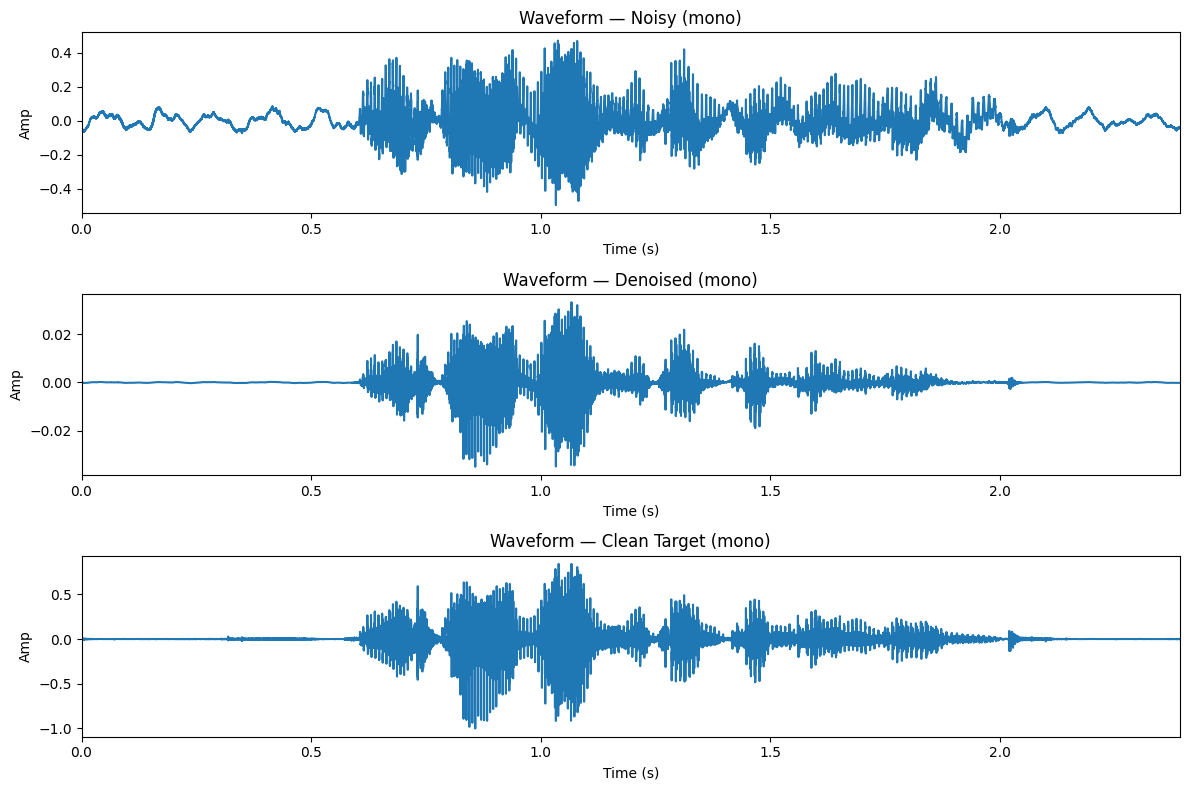

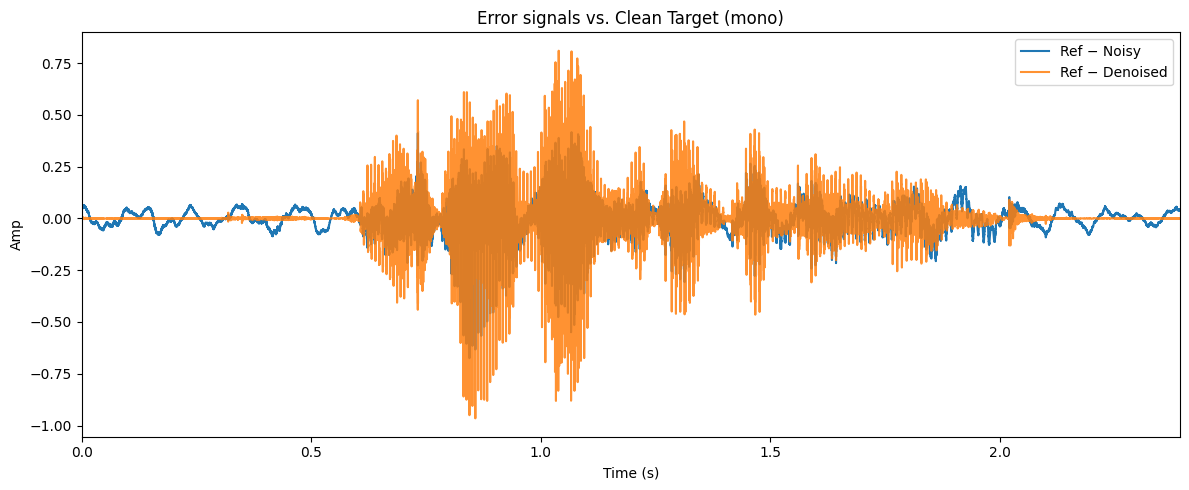

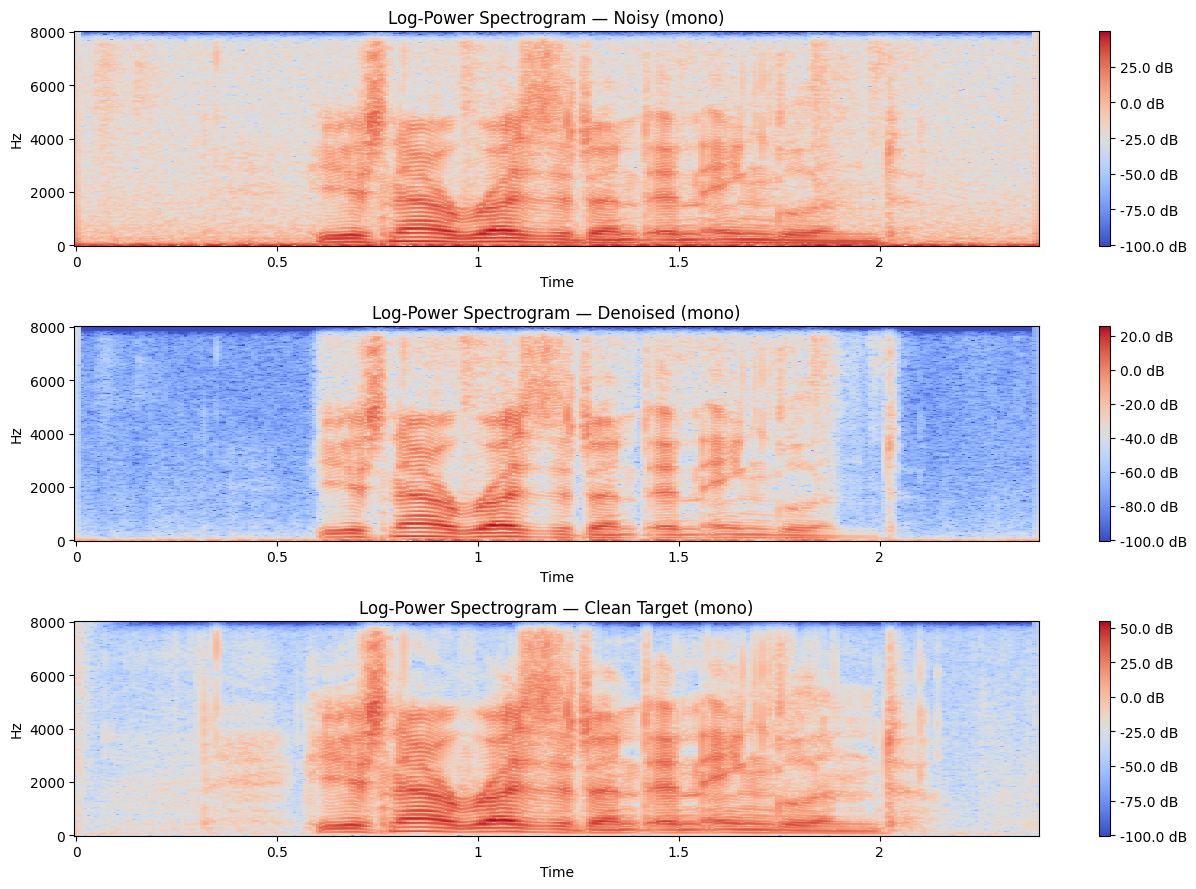

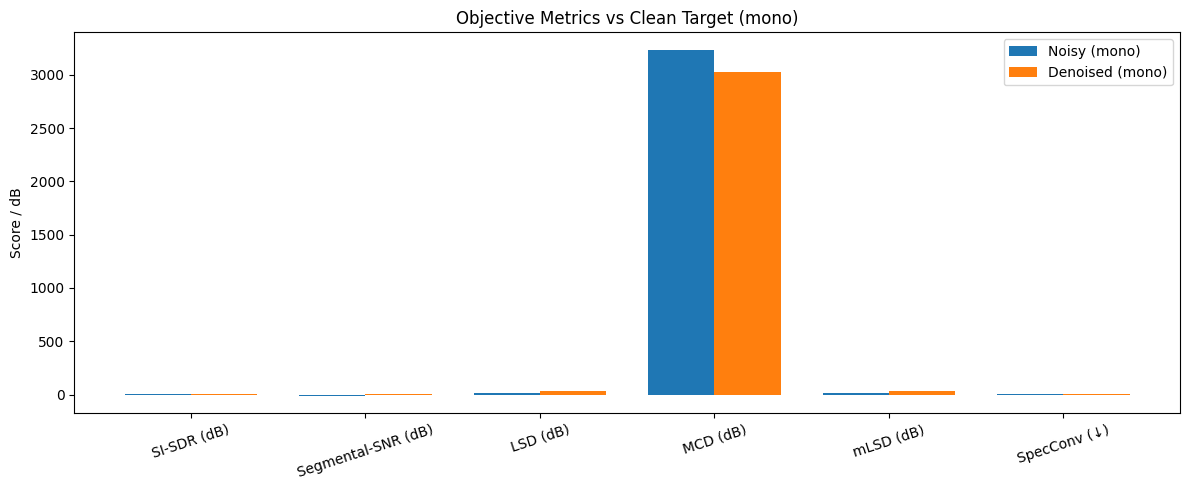

In [ ]:
# ===============================
# Visualization & Evaluation — Stage-1 Mono Denoising
#  * Pull one sample (prefers test_ds_mono)
#  * Predict mono with current model (mask on noisy mono STFT)
#  * Metrics vs mono clean target (enhanced-mono or clean)
#  * Plots: waveforms, errors, spectrograms, metric bars
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display
import torch
from IPython.display import display

# ---- 0) Numpy dtype shims for some librosa versions ----
if not hasattr(np, "complex"): np.complex = np.complex128
if not hasattr(np, "bool"):    np.bool    = np.bool_
if not hasattr(np, "object"):  np.object  = np.object_
if not hasattr(np, "float"):   np.float   = float

# ---- 1) Pull globals / fallbacks ----
DEVICE    = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR = int(globals().get("TARGET_SR", 16000))
N_FFT     = int(globals().get("N_FFT", 512))
HOP       = int(globals().get("HOP", 128))
WIN       = int(globals().get("WIN", 512))
USE_PHASE_HEAD = bool(globals().get("USE_PHASE_HEAD", False))

assert 'stft_mag_phase' in globals() and 'istft_from_mag_phase' in globals(), "The STFT/ISTFT helper functions stft_mag_phase/istft_from_mag_phase are missing."

mono_model = globals().get("mono_model", None)
assert mono_model is not None, "The mono_model is not defined. Please build and load the Stage-1 model first."

dataset = globals().get("test_ds_mono", None)
if dataset is None:
    dataset = globals().get("test_ds", None)
if dataset is None and 'test_dl' in globals():
    try:
        dataset = globals()['test_dl'].dataset
    except Exception:
        pass
assert dataset is not None, "Test set not found: Please provide test_ds_mono or test_ds (or test_dl.dataset)."

# ---- 2) Metric functions (no PESQ/STOI) ----
def si_sdr(ref, est, eps=1e-8):
    ref = ref - np.mean(ref)
    est = est - np.mean(est)
    t = (np.sum(est*ref) / (np.sum(ref*ref) + eps)) * ref
    n = est - t
    ratio = (np.sum(t*t) + eps) / (np.sum(n*n) + eps)
    return 10.0 * np.log10(ratio + eps)

def segmental_snr(ref, est, sr, frame_ms=20, eps=1e-12):
    N = len(ref); L = max(1, int(sr * frame_ms / 1000.0))
    acc, num = 0.0, 0
    for i in range(0, N, L):
        r = ref[i:i+L]; e = est[i:i+L]
        if len(r) < 2: continue
        snr = 10*np.log10((np.sum(r*r)+eps) / (np.sum((r-e)*(r-e))+eps))
        acc += snr; num += 1
    return acc/num if num > 0 else np.nan

def log_spectral_distance_db(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    Rdb = 20*np.log10(R); Edb = 20*np.log10(E)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def mcd_db(ref, est, sr=TARGET_SR, n_mfcc=13, drop_c0=True, lifter=22, eps=1e-12):
    mfcc_r = librosa.feature.mfcc(y=ref, sr=sr, n_mfcc=n_mfcc)
    mfcc_e = librosa.feature.mfcc(y=est, sr=sr, n_mfcc=n_mfcc)
    if lifter:
        lif = 1 + (lifter/2.)*np.sin(np.pi*np.arange(n_mfcc)/lifter)[:, None]
        mfcc_r *= lif; mfcc_e *= lif
    if drop_c0 and mfcc_r.shape[0] > 1:
        mfcc_r = mfcc_r[1:, :]; mfcc_e = mfcc_e[1:, :]
    T = min(mfcc_r.shape[1], mfcc_e.shape[1])
    if T <= 1: return np.nan
    diff = mfcc_r[:, :T] - mfcc_e[:, :T]
    coef = 10.0/np.log(10.0) * np.sqrt(2.0)  # ≈ 6.14185
    return coef * np.mean(np.sqrt(np.sum(diff*diff, axis=0) + eps))

def mel_lsd_db(ref, est, sr=TARGET_SR, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    S_r = librosa.feature.melspectrogram(y=ref, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    S_e = librosa.feature.melspectrogram(y=est, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    L = min(S_r.shape[1], S_e.shape[1])
    S_r = S_r[:, :L]; S_e = S_e[:, :L]
    Rdb = 10*np.log10(S_r); Edb = 10*np.log10(S_e)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def spectral_convergence(ref, est, n_fft=N_FFT, hop=HOP, win_length=WIN, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    num = np.linalg.norm(R - E, ord='fro')
    den = np.linalg.norm(R, ord='fro') + eps
    return float(num / den)

# ---- 3) Mono forward ----
@torch.no_grad()
def predict_mono(noisy_1d: torch.Tensor):
    """
    noisy_1d: torch.Tensor [T] (CPU)
    returns: est_deno [T] (np.float32)
    """
    mono_model.eval()
    x = noisy_1d.unsqueeze(0).to(DEVICE)  # [1,T]

    mag_n, ph_n = stft_mag_phase(x)                   # [1,F,T], complex
    inp = torch.log1p(mag_n).unsqueeze(1)             # [1,1,F,T]
    out = mono_model(inp)

    if isinstance(out, (tuple, list)) and len(out) == 2:
        mask, dphi = out                               # [1,1,F,T], [1,1,F,T]
        if mask.dim() == 3: mask = mask.unsqueeze(1)
        est_mag = mask[:, 0] * mag_n                  # [1,F,T]
        eps = 1e-8
        unit = ph_n / (torch.abs(ph_n) + eps)         # e^{j φ_noisy}
        rot  = torch.complex(torch.cos(dphi[:, 0]), torch.sin(dphi[:, 0]))
        Xest = est_mag * (unit * rot)
        win = torch.hann_window(WIN, device=Xest.device, dtype=torch.float32)
        T_len = x.shape[-1]
        est = torch.istft(Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                          window=win, center=True, length=T_len)  # [1,T]
    else:
        mask = out
        if mask.dim() == 3: mask = mask.unsqueeze(1)  # [1,1,F,T]
        est_mag = mask[:, 0] * mag_n
        T_len = x.shape[-1]
        est = istft_from_mag_phase(est_mag, ph_n)     # [1,T]

    return est[0].detach().float().cpu().numpy().astype(np.float32, copy=False)

# ---- 4) Fetch one sample & predict ----
with torch.no_grad():
    idx = int(np.random.randint(0, len(dataset)))
    item = dataset[idx]
    if isinstance(item, (tuple, list)) and len(item) >= 2:
        noisy_t, clean_t = item[0], item[1]
    else:
        noisy_t, clean_t = item, item

    if torch.is_tensor(clean_t) and clean_t.dim() == 3:
        clean_t = clean_t.mean(dim=0)  # [T]
    elif torch.is_tensor(clean_t) and clean_t.dim() == 2 and clean_t.shape[0] == 2:
        clean_t = clean_t.mean(dim=0)

    est = predict_mono(noisy_t)  # [T]

# ---- 5) Numpy & length alignment ----
noisy = (noisy_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(noisy_t)
         else np.asarray(noisy_t, dtype=np.float32))
clean = (clean_t.detach().cpu().numpy().astype(np.float32) if torch.is_tensor(clean_t)
         else np.asarray(clean_t, dtype=np.float32))

Lmin = int(min(len(noisy), len(clean), len(est)))
noisy = noisy[:Lmin]; clean = clean[:Lmin]; est = est[:Lmin]
sr = TARGET_SR

# ---- 6) Calculate metrics ----
def eval_pair(ref, deg, sr):
    return {
        "SI-SDR (dB)":        si_sdr(ref, deg),
        "Segmental-SNR (dB)": segmental_snr(ref, deg, sr),
        "LSD (dB)":           log_spectral_distance_db(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "MCD (dB)":           mcd_db(ref, deg, sr, n_mfcc=13, drop_c0=True, lifter=22),
        "mLSD (dB)":          mel_lsd_db(ref, deg, sr, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "SpecConv (↓)":       spectral_convergence(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
    }

metrics_noisy = eval_pair(clean, noisy, sr)
metrics_deno  = eval_pair(clean, est,   sr)

df = pd.DataFrame([metrics_noisy, metrics_deno],
                  index=["Noisy → CleanTarget(mono)", "Denoised → CleanTarget(mono)"])

def delta(a, b):
    if a is None or b is None or (isinstance(a, float) and np.isnan(a)) or (isinstance(b, float) and np.isnan(b)):
        return None
    return b - a

improve = {
    "Δ SI-SDR (dB)":   delta(metrics_noisy["SI-SDR (dB)"],        metrics_deno["SI-SDR (dB)"]),
    "Δ SegSNR (dB)":   delta(metrics_noisy["Segmental-SNR (dB)"], metrics_deno["Segmental-SNR (dB)"]),
    "Δ LSD (dB)↓":     delta(metrics_noisy["LSD (dB)"],           metrics_deno["LSD (dB)"]),
    "Δ MCD (dB)↓":     delta(metrics_noisy["MCD (dB)"],           metrics_deno["MCD (dB)"]),
    "Δ mLSD (dB)↓":    delta(metrics_noisy["mLSD (dB)"],          metrics_deno["mLSD (dB)"]),
    "Δ SpecConv↓":     delta(metrics_noisy["SpecConv (↓)"],       metrics_deno["SpecConv (↓)"]),
}
df_improve = pd.DataFrame([improve], index=["Improvement (Denoised − Noisy)"])

with pd.option_context("display.precision", 3):
    print(f"\n=== Objective Metrics (idx={idx}) ===")
    display(df)
    print("\n=== Improvements (Denoised − Noisy) ===")
    display(df_improve)

# ---- 7) Visualization: Waveforms & Spectra ----
dur = len(clean)/sr
t = np.arange(len(clean))/sr

plt.figure(figsize=(12, 8))
plt.subplot(3,1,1); plt.plot(t, noisy); plt.title("Waveform — Noisy (mono)");    plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,2); plt.plot(t, est);   plt.title("Waveform — Denoised (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,3); plt.plot(t, clean); plt.title("Waveform — Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.tight_layout(); plt.show()

# waveform error
err_noisy = clean - noisy
err_deno  = clean - est
plt.figure(figsize=(12,5))
plt.plot(t, err_noisy, label="Ref − Noisy")
plt.plot(t, err_deno,  label="Ref − Denoised", alpha=0.85)
plt.title("Error signals vs. Clean Target (mono)"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur); plt.legend(); plt.tight_layout(); plt.show()

# Spectrum (logarithmic power spectrum) - Normalize with the average power of ref as the reference to avoid overall gain bias.
def spec_db(y, sr, n_fft=N_FFT, hop=HOP, win_length=WIN, ref_power=1.0, eps=1e-12):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop, win_length=win_length))**2
    return 10*np.log10(S + eps) - 10*np.log10(ref_power + eps)

ref_pow = float(np.mean(clean.astype(np.float64)**2) + 1e-12)
S_noisy = spec_db(noisy, sr, ref_power=ref_pow)
S_deno  = spec_db(est,   sr, ref_power=ref_pow)
S_clean = spec_db(clean, sr, ref_power=ref_pow)

plt.figure(figsize=(13,9))
ax1 = plt.subplot(3,1,1); librosa.display.specshow(S_noisy, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Noisy (mono)");    plt.colorbar(ax=ax1, format="%.1f dB")
ax2 = plt.subplot(3,1,2); librosa.display.specshow(S_deno,  sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Denoised (mono)");  plt.colorbar(ax=ax2, format="%.1f dB")
ax3 = plt.subplot(3,1,3); librosa.display.specshow(S_clean, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Clean Target (mono)");     plt.colorbar(ax=ax3, format="%.1f dB")
plt.tight_layout(); plt.show()

# ---- 8) Indicator comparison bar chart ----
labels = ["SI-SDR (dB)", "Segmental-SNR (dB)", "LSD (dB)", "MCD (dB)", "mLSD (dB)", "SpecConv (↓)"]
noisy_vals = [metrics_noisy[k] for k in labels]
deno_vals  = [metrics_deno[k]  for k in labels]
x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(12,5))
plt.bar(x - w/2, noisy_vals, width=w, label="Noisy (mono)")
plt.bar(x + w/2, deno_vals,  width=w, label="Denoised (mono)")
plt.xticks(x, labels, rotation=18); plt.title("Objective Metrics vs Clean Target (mono)"); plt.ylabel("Score / dB")
plt.legend(); plt.tight_layout(); plt.show()


In [74]:
# =========================================
# Stage-2 Spatialization — Clean→Stereo Teacher Datasets
#  - Input : clean mono (optionally first enhanced by ENHANCER_MONO for perceptual quality)
#  - Target: stereo teacher produced by ENHANCER_STEREO.enhance(clean)
#  - Does not use noisy / remote degraded signals; no remote augmentation
# =========================================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# Reuse your existing utilities/variables:
# - read_mono_resample, pad_or_trim
# - ENHANCER_MONO, ENHANCER_STEREO
# - CLEAN_TR, CLEAN_TE, TARGET_SR, SEGMENT_SAM, BATCH_SIZE, MAX_TRAIN_PAIRS, PAIR_SUBSET_SEED

class CleanToStereoTeacherDataset(Dataset):
    """
    Stage-2 spatialization training/test dataset (no noise):
      Input :  clean_in   ([T], either raw clean or ENHANCER_MONO(clean))
      Target:  stereo_tgt ([2,T], generated by ENHANCER_STEREO(clean))
    """
    def __init__(self,
                 clean_dir,
                 target_sr=16000,
                 segment_sam=None,
                 train=True,
                 max_pairs=None,
                 enhancer_in=None,        # None: use raw clean; otherwise apply perceptual mono enhancement first
                 enhancer_target=None):   # Required: ENHANCER_STEREO
        self.clean_dir = Path(clean_dir)
        self.segment_sam = segment_sam
        self.target_sr = target_sr
        self.train = train
        self.max_pairs = max_pairs
        self.enhancer_in = enhancer_in
        self.enhancer_target = enhancer_target

        if self.enhancer_target is None or not getattr(self.enhancer_target, "produce_stereo_target", False):
            raise ValueError("enhancer_target must be a stereo-capable ENHANCER_STEREO (produce_stereo_target=True).")

        clean_files = sorted(list(self.clean_dir.glob("*.wav")))
        if not clean_files:
            raise RuntimeError(f"No clean wavs found in: {self.clean_dir}")

        # Only clean -> clean (no noisy)
        pairs = [(None, cf) for cf in clean_files]

        if self.train and (max_pairs is not None) and (len(pairs) > max_pairs):
            rng = np.random.default_rng(PAIR_SUBSET_SEED)
            idx = rng.choice(len(pairs), size=max_pairs, replace=False)
            self.pairs = [pairs[i] for i in idx]
            print(f"[Stage-2] Train pairs: {len(self.pairs)} / {len(pairs)} (subset, seed={PAIR_SUBSET_SEED})")
        else:
            self.pairs = pairs
            print(f"[Stage-2] {'Train' if train else 'Eval'} pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        _, cf = self.pairs[idx]
        clean, _ = read_mono_resample(cf, self.target_sr)  # [T] float32

        # Input: raw clean or perceptually enhanced mono (still mono)
        if self.enhancer_in is None:
            x_in = clean
        else:
            x_in = self.enhancer_in.enhance(clean)  # mono output
            if np.ndim(x_in) != 1:  # Safety: if mistakenly stereo, downmix
                x_in = np.asarray(x_in, dtype=np.float32)
                if x_in.ndim == 2 and x_in.shape[1] == 2:
                    x_in = x_in.mean(axis=1)
                else:
                    x_in = np.squeeze(x_in).astype(np.float32)

        # Target: stereo teacher
        st = self.enhancer_target.enhance(clean)  # [T,2]
        if np.ndim(st) != 2 or st.shape[1] != 2:
            raise RuntimeError("ENHANCER_STEREO output must be stereo [T,2].")

        # For training, optionally segment into chunks
        if self.train and (self.segment_sam is not None):
            L = min(len(x_in), st.shape[0])
            if L >= self.segment_sam:
                start = np.random.randint(0, L - self.segment_sam + 1)
                x_in = x_in[start:start+self.segment_sam]
                st   = st[start:start+self.segment_sam, :]
            else:
                x_in = pad_or_trim(x_in, self.segment_sam)
                tgt  = np.zeros((self.segment_sam, 2), dtype=np.float32)
                tgt[:L] = st[:L]
                st = tgt

        # Package as tensors
        x_t  = torch.from_numpy(x_in.astype(np.float32))             # [T]
        st_t = torch.from_numpy(st.astype(np.float32)).permute(1,0)  # [2,T]
        return x_t, st_t


# =========================
# Build Stage-2 datasets/loaders (no noise)
# =========================

# Options:
#   enhancer_in = None            → use raw clean as Stage-2 input
#   enhancer_in = ENHANCER_MONO   → apply light perceptual enhancement first (more “ear-pleasing” mono input)
enhancer_input_choice = ENHANCER_MONO   # or set to None

# Training set (clean→stereo teacher)
train_ds_spatial_clean = CleanToStereoTeacherDataset(
    clean_dir=CLEAN_TR,
    target_sr=TARGET_SR,
    segment_sam=SEGMENT_SAM,         # Training: cut into ~2s segments
    train=True,
    max_pairs=MAX_TRAIN_PAIRS,
    enhancer_in=enhancer_input_choice,
    enhancer_target=ENHANCER_STEREO
)

# Test set (clean→stereo teacher, full-length evaluation)
test_ds_spatial_clean = CleanToStereoTeacherDataset(
    clean_dir=CLEAN_TE,
    target_sr=TARGET_SR,
    segment_sam=None,                # Testing: no segmentation
    train=False,
    max_pairs=None,
    enhancer_in=enhancer_input_choice,
    enhancer_target=ENHANCER_STEREO
)

# DataLoaders
train_dl_spatial_clean = DataLoader(
    train_ds_spatial_clean, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
)
test_dl_spatial_clean = DataLoader(
    test_ds_spatial_clean, batch_size=1, shuffle=False, num_workers=0
)

print("\n[Stage-2] Built loaders (Clean→StereoTeacher):")
print(f" - train_dl_spatial_clean: {len(train_ds_spatial_clean)} samples, batch={BATCH_SIZE}, seg={SEGMENT_SAM}")
print(f" - test_dl_spatial_clean : {len(test_ds_spatial_clean)} samples (full length)")


[Stage-2] Train pairs: 300 / 11572 (subset, seed=2025)
[Stage-2] Eval pairs: 824

[Stage-2] Built loaders (Clean→StereoTeacher):
 - train_dl_spatial_clean: 300 samples, batch=8, seg=32000
 - test_dl_spatial_clean : 824 samples (full length)


In [75]:
# =========================================
# Preview: Stage-2 (Clean → StereoTeacher) dataset samples
#  - Play input mono and target stereo
#  - Compatible with torch.Tensor / np.ndarray
#  - Playback via in-memory WAV byte stream to avoid ushort errors
# Dependencies:
#   train_ds_spatial_clean, test_ds_spatial_clean (the datasets you just built)
#   TARGET_SR
# =========================================
import numpy as np
import torch
from typing import Optional
from IPython.display import Audio, display

# ---------- Generic audio playback utility ----------
def _finalize_shape_for_audio(x: np.ndarray, expect_stereo: Optional[bool] = None) -> np.ndarray:
    """
    Standardize to shapes accepted by IPython.display.Audio:
      - Mono : [T]
      - Stereo: [T, 2]
    """
    x = np.asarray(x)
    x = np.squeeze(x)

    if x.ndim == 1:
        return x.astype(np.float32, copy=False)

    if x.ndim == 2:
        r, c = x.shape
        if r < c:   # unify to [T, C]
            x = x.T
            r, c = x.shape

        if expect_stereo is True:
            if c == 2:
                return x.astype(np.float32, copy=False)
            elif c == 1:
                return np.repeat(x, 2, axis=1).astype(np.float32, copy=False)
            else:
                return x[:, :2].astype(np.float32, copy=False)
        elif expect_stereo is False:
            if c == 1:
                return x[:, 0].astype(np.float32, copy=False)
            else:
                return x.mean(axis=1).astype(np.float32, copy=False)
        else:
            if c == 1:
                return x[:, 0].astype(np.float32, copy=False)
            else:
                return x[:, :2].astype(np.float32, copy=False)

    # >2D: squeeze and process recursively
    x = np.squeeze(x)
    if x.ndim == 1:
        return x.astype(np.float32, copy=False)
    if x.ndim == 2:
        return _finalize_shape_for_audio(x, expect_stereo=expect_stereo)
    return x.reshape(-1).astype(np.float32, copy=False)

def _safe_audio_play(arr, sr, force_stereo: Optional[bool] = None, label: str = "", peak_norm: bool = True):
    """
    Always write to an in-memory WAV buffer for playback; supports forced stereo/mono output.
    If peak_norm=True, peak-normalize to <=1 before playback (does not alter relative loudness).
    """
    x = _finalize_shape_for_audio(arr, expect_stereo=force_stereo)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)

    if peak_norm and x.size:
        peak = float(np.max(np.abs(x)))
        if peak > 1.0:
            x = x / (peak + 1e-12)

    # Shape check
    ok = (x.ndim == 1) or (x.ndim == 2 and x.shape[1] in (1, 2))
    if not ok:
        raise ValueError(f"[Audio:{label}] invalid shape {x.shape}; expected [T] or [T,2].")

    # Print info
    ch = 1 if x.ndim == 1 else x.shape[1]
    ln = x.shape[0]
    sr_int = int(sr)
    print(f"  -> play shape: {x.shape} (T={ln}, ch={ch}), sr={sr_int} [{label}]")

    # Write in-memory WAV (PCM16)
    import io, wave
    buf = io.BytesIO()
    with wave.open(buf, 'wb') as wf:
        wf.setnchannels(1 if x.ndim == 1 else int(x.shape[1]))
        wf.setsampwidth(2)          # 16-bit PCM
        wf.setframerate(sr_int)
        data_i16 = (np.clip(x, -1.0, 1.0) * 32767.0).astype('<i2', copy=False)
        wf.writeframes(data_i16.tobytes())

    buf.seek(0)
    wav_bytes = buf.read()
    display(Audio(data=wav_bytes))  # sr included in WAV header

def _to_numpy_1d(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().astype(np.float32)
    return np.asarray(x, dtype=np.float32)

def _to_numpy_2t(x2t):
    """
    Convert [2, T] → [T, 2] as numpy
    """
    if torch.is_tensor(x2t):
        x2t = x2t.detach().cpu().numpy().astype(np.float32)
    else:
        x2t = np.asarray(x2t, dtype=np.float32)
    if x2t.ndim == 2 and x2t.shape[0] == 2:
        x2t = x2t.transpose(1, 0)  # [T,2]
    return x2t

def _apply_post_gain_db(x, db):
    if db is None or abs(db) < 1e-6:
        return x
    g = 10.0**(db/20.0)
    return (x * g).astype(np.float32, copy=False)

# ---------- Stage-2 audio preview entry ----------
def listen_stage2_dataset_sample(dataset,
                                 sample_idx: Optional[int] = None,
                                 post_gain_db_input: float = 0.0,
                                 post_gain_db_target: float = 0.0,
                                 match_rms_to: Optional[str] = None):
    """
    Play one sample from the dataset:
      - Input : mono
      - Target: stereo
    Args:
      sample_idx         : choose sample index; None → random
      post_gain_db_input : post gain applied to input during playback (dB)
      post_gain_db_target: post gain applied to target during playback (dB)
      match_rms_to       : {'input','target',None}; RMS matching for subjective comparison
    """
    assert dataset is not None and len(dataset) > 0, "Dataset is empty."

    idx = int(np.random.randint(len(dataset)) if sample_idx is None else sample_idx)
    x_t, st_t = dataset[idx]   # x_t:[T]  st_t:[2,T]

    sr_play = int(globals().get("TARGET_SR", 16000))
    x_np  = _to_numpy_1d(x_t)        # [T]
    st_np = _to_numpy_2t(st_t)       # [T,2]

    # Length & duration
    Lmin = min(len(x_np), st_np.shape[0])
    x_np  = x_np[:Lmin]
    st_np = st_np[:Lmin, :]
    dur_s = Lmin / sr_play
    print(f"[Stage-2 preview] idx={idx} | dur={dur_s:.2f}s | sr={sr_play}")

    # Optional RMS matching (for playback only)
    def _rms(a): return float(np.sqrt(np.mean(a.astype(np.float64)**2) + 1e-12))
    if match_rms_to in ("input", "target"):
        rms_in  = _rms(x_np)
        rms_tgt = _rms(st_np.mean(axis=1))
        if match_rms_to == "input" and rms_tgt > 0:
            st_np = st_np * (rms_in / rms_tgt)
            print(f"  - RMS matched target → input (ratio={rms_in/(rms_tgt+1e-12):.3f})")
        elif match_rms_to == "target" and rms_in > 0:
            x_np = x_np * (rms_tgt / rms_in)
            print(f"  - RMS matched input → target (ratio={rms_tgt/(rms_in+1e-12):.3f})")

    # Post gain (playback only)
    x_np  = _apply_post_gain_db(x_np,  post_gain_db_input)
    st_np = _apply_post_gain_db(st_np, post_gain_db_target)

    # Playback
    print("Play: Stage-2 Input (mono)")
    _safe_audio_play(x_np,  sr_play, force_stereo=False, label="stage2_input")

    print("Play: Stage-2 Target (stereo teacher)")
    _safe_audio_play(st_np, sr_play, force_stereo=True,  label="stage2_target")

# ======== Example: directly preview one sample ========
# Training set
listen_stage2_dataset_sample(train_ds_spatial_clean,
                             sample_idx=None,            # None → random
                             post_gain_db_input=0.0,
                             post_gain_db_target=0.0,
                             match_rms_to=None)          # Optional: 'input' or 'target'

# Test set
listen_stage2_dataset_sample(test_ds_spatial_clean,
                             sample_idx=None,
                             post_gain_db_input=0.0,
                             post_gain_db_target=0.0,
                             match_rms_to=None)


[Stage-2 preview] idx=227 | dur=2.00s | sr=16000
Play: Stage-2 Input (mono)
  -> play shape: (32000,) (T=32000, ch=1), sr=16000 [stage2_input]


Play: Stage-2 Target (stereo teacher)
  -> play shape: (32000, 2) (T=32000, ch=2), sr=16000 [stage2_target]


[Stage-2 preview] idx=815 | dur=2.30s | sr=16000
Play: Stage-2 Input (mono)
  -> play shape: (36770,) (T=36770, ch=1), sr=16000 [stage2_input]


Play: Stage-2 Target (stereo teacher)
  -> play shape: (36770, 2) (T=36770, ch=2), sr=16000 [stage2_target]


In [76]:
# =========================================================
# Stage-2 Spatialization (ResNet)
#  - Input : mono waveform  (recommended: use Stage-1 denoised result or ENHANCER_MONO(clean))
#  - Target: stereo teacher (ENHANCER_STEREO(clean))
#  - Feat  : log1p(|STFT|)  → [B,1,F,T]
#  - Model : 2D-ResNet (preserving F,T resolution) → mask [B,2,F,T] (+ optional Δφ)
#  - Loss  : SpecMSE + TimeL1 + Downmix-SI-SDR + Spatial (ILD/IPD/IACC) + Δφ smoothness
#  - AMP   : supports mixed precision; ISTFT uses explicit length to avoid energy “dilution”
# =========================================================
import math, time, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

# ---------- Reuse / fallback some global hyperparameters ----------
DEVICE    = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR = int(globals().get("TARGET_SR", 16000))
N_FFT     = int(globals().get("N_FFT", 512))
HOP       = int(globals().get("HOP", 128))
WIN       = int(globals().get("WIN", N_FFT))
# WINDOW may be a float window on CPU; here we define a helper to ensure correct dtype/device
def _win_like(x):
    return torch.hann_window(WIN, device=x.device, dtype=x.real.dtype if torch.is_complex(x) else x.dtype)

LR            = float(globals().get("LR", 1e-3))
EPOCHS        = int(globals().get("EPOCHS", 10))
BATCH_SIZE    = int(globals().get("BATCH_SIZE", 8))
LAMBDA_SPEC   = float(globals().get("LAMBDA_SPEC", 1.0))
LAMBDA_SISDR  = float(globals().get("LAMBDA_SISDR", 1.0))
USE_PHASE_HEAD= bool(globals().get("USE_PHASE_HEAD", True))  # can be disabled

# Try to reuse your previously constructed loaders (Clean → StereoTeacher)
train_dl = globals().get("train_dl_spatial_clean", None)
test_dl  = globals().get("test_dl_spatial_clean",  None)

# ---------- STFT helpers ----------
def stft_mag_phase(x):
    """
    x: [B,T] mono
    return: mag [B,F,T], X_complex [B,F,T] (complex)
    """
    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(x), center=True, return_complex=True
    )
    mag = torch.abs(X)
    return mag, X

def istft_from_mag_phase(mag, phase_complex, length=None):
    eps  = 1e-8
    unit = phase_complex / (torch.abs(phase_complex) + eps)   # e^{jφ}
    Xest = mag * unit
    x = torch.istft(
        Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(Xest), center=True, length=length
    )
    return x   # [B,T]

# ---------- Spatial losses ----------
def spec_mse_loss(mag_est, mag_tgt):
    return F.mse_loss(torch.log1p(mag_est), torch.log1p(mag_tgt))

def time_l1_loss(x_est, x_tgt):
    L = min(x_est.shape[-1], x_tgt.shape[-1])
    return F.l1_loss(x_est[..., :L], x_tgt[..., :L])

def sisdr_loss(x, s, eps=1e-8):
    x = x - x.mean(dim=-1, keepdim=True)
    s = s - s.mean(dim=-1, keepdim=True)
    alpha = torch.sum(x*s, dim=-1, keepdim=True) / (torch.sum(s*s, dim=-1, keepdim=True)+eps)
    s_hat = alpha * s
    e = x - s_hat
    sisdr = 10.0*torch.log10((torch.sum(s_hat**2, dim=-1)+eps)/(torch.sum(e**2, dim=-1)+eps))
    return -sisdr.mean()

def ild_loss(est_L, est_R, tgt_L, tgt_R, eps=1e-8):
    def ild(a, b):
        ra = torch.sqrt((a**2).mean(dim=-1)+eps)
        rb = torch.sqrt((b**2).mean(dim=-1)+eps)
        return 20*torch.log10(ra+eps) - 20*torch.log10(rb+eps)
    return F.mse_loss(ild(est_L,est_R), ild(tgt_L,tgt_R))

def ild_fb_loss(est_L, est_R, tgt_L, tgt_R, n_fft=N_FFT, hop=HOP, win=WIN, eps=1e-8):
    def band_rms(x):
        X = torch.stft(x, n_fft=n_fft, hop_length=hop, win_length=win,
                       window=torch.hann_window(win, device=x.device), return_complex=True)
        mag = torch.abs(X)
        return torch.sqrt((mag**2).mean(dim=-1)+eps)  # [B,F]
    eL,eR = band_rms(est_L), band_rms(est_R)
    tL,tR = band_rms(tgt_L), band_rms(tgt_R)
    ild_e = 20*torch.log10(eL+eps) - 20*torch.log10(eR+eps)
    ild_t = 20*torch.log10(tL+eps) - 20*torch.log10(tR+eps)
    return F.mse_loss(ild_e, ild_t)

def ipd_fb_loss(est_L, est_R, tgt_L, tgt_R, n_fft=N_FFT, hop=HOP, win=WIN):
    def phase(x):
        X = torch.stft(x, n_fft=n_fft, hop_length=hop, win_length=win,
                       window=torch.hann_window(win, device=x.device), return_complex=True)
        return torch.angle(X)
    pLe, pRe = phase(est_L), phase(est_R)
    pLt, pRt = phase(tgt_L), phase(tgt_R)
    ipd_e = torch.atan2(torch.sin(pLe-pRe), torch.cos(pLe-pRe))
    ipd_t = torch.atan2(torch.sin(pLt-pRt), torch.cos(pLt-pRt))
    return F.l1_loss(ipd_e, ipd_t)

def iacc_frame_loss(est_L, est_R, tgt_L, tgt_R, frame=1024, hop=512, max_lag=8, eps=1e-8):
    def frame_gcc_max(a, b):
        B,T = a.shape
        if T < frame:
            a = F.pad(a, (0, frame-T)); b = F.pad(b, (0, frame-T))
        A = a.unfold(-1, frame, hop)   # [B, nfrm, frame]
        Bx= b.unfold(-1, frame, hop)
        An = A / (A.pow(2).sum(-1, keepdim=True).sqrt()+eps)
        Bn = Bx/ (Bx.pow(2).sum(-1, keepdim=True).sqrt()+eps)
        vals = []
        for lag in range(-max_lag, max_lag+1):
            if lag < 0:  v = (An[..., :frame+lag] * Bn[..., -lag:]).sum(-1)
            elif lag> 0: v = (An[..., lag:] * Bn[..., :frame-lag]).sum(-1)
            else:        v = (An * Bn).sum(-1)
            vals.append(v)
        V = torch.stack(vals, dim=-1)  # [B, nfrm, 2*max_lag+1]
        return V.max(dim=-1).values
    c_est = frame_gcc_max(est_L, est_R)
    c_tgt = frame_gcc_max(tgt_L, tgt_R)
    return F.l1_loss(c_est, c_tgt)


In [78]:
# =========================================================
# Safe STFT helpers + ResFCSpatializer (τ -> Δϕ)
# Directly replace the corresponding part in your current code
# =========================================================
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- Global parameters (reuse your existing globals) ----------
DEVICE    = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR = int(globals().get("TARGET_SR", 16000))
N_FFT     = int(globals().get("N_FFT", 512))
HOP       = int(globals().get("HOP", 128))
WIN       = int(globals().get("WIN", N_FFT))
USE_PHASE_HEAD = bool(globals().get("USE_PHASE_HEAD", True))

def _win_like(x):
    # Same as your original: construct Hann window based on x's dtype/device
    return torch.hann_window(WIN, device=x.device,
                             dtype=(x.real.dtype if torch.is_complex(x) else x.dtype))

# ---------- STFT function compatible with 1D/2D input ----------
def stft_mag_phase_safe(x):
    """
    x: [B,T] or [T]; if 1D it is automatically treated as [1,T]
    return: mag [B,F,T], X_complex [B,F,T] (complex)
    """
    squeeze_back = False
    if x.dim() == 1:   # [T] -> [1,T]
        x = x.unsqueeze(0)
        squeeze_back = True
    elif x.dim() != 2:
        raise ValueError(f"stft_mag_phase_safe expects [B,T] or [T], got {tuple(x.shape)}")

    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(x), center=True, return_complex=True
    )
    mag = torch.abs(X)
    # Do not squeeze; keep [B,F,T] unified so later code works
    return mag, X

def istft_from_mag_phase(mag, phase_complex, length=None):
    eps  = 1e-8
    unit = phase_complex / (torch.abs(phase_complex) + eps)   # e^{jφ}
    Xest = mag * unit
    x = torch.istft(
        Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(Xest), center=True, length=length
    )
    return x   # [B,T]

# =========================================================
# Residual fully-connected network (Res-MLP, frame-wise band vector processing)
# + directly predict ITD τ(t) and construct Δϕ(f,t)=ω·τ(t)
# =========================================================
class ResMLPBlock(nn.Module):
    def __init__(self, dim, hidden_mult=4, dropout=0.0, use_ln=True):
        super().__init__()
        self.use_ln = use_ln
        self.ln1 = nn.LayerNorm(dim) if use_ln else nn.Identity()
        self.fc1 = nn.Linear(dim, dim * hidden_mult)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc2 = nn.Linear(dim * hidden_mult, dim)
        self.ln2 = nn.LayerNorm(dim) if use_ln else nn.Identity()

    def forward(self, x):  # [B,T,Dim]
        h = self.ln1(x)
        h = self.fc1(h)
        h = self.act(h)
        h = self.drop(h)
        h = self.fc2(h)
        h = self.ln2(h)
        return x + h

class TauHead(nn.Module):
    """
    Input:  h [B,T,H] -> Output: τ(t) [B,T] (seconds), limited to ±tau_limit_ms
    """
    def __init__(self, hidden_dim, tau_limit_ms=0.8, use_temporal=True):
        super().__init__()
        self.tau_limit = float(tau_limit_ms) / 1000.0
        self.use_temporal = bool(use_temporal)
        if self.use_temporal:
            self.gru = nn.GRU(hidden_dim, hidden_dim // 2, batch_first=True, bidirectional=True)
            out_dim = hidden_dim
        else:
            self.gru = None
            out_dim = hidden_dim
        self.fc_tau = nn.Linear(out_dim, 1)

    def forward(self, h):  # [B,T,H]
        if self.gru is not None:
            h, _ = self.gru(h)
        tau = torch.tanh(self.fc_tau(h)).squeeze(-1)  # [B,T] in (-1,1)
        tau = tau * self.tau_limit
        return tau

class ResFCSpatializer(nn.Module):
    """
    Input:  x = [B,1,F,T]  (log1p|STFT|)
    Output: masks = [B,2,F,T], and if phase head enabled also dphi = [B,2,F,T]
    Phase: predict τ(t) and construct Δϕ=ω·τ (left/right anti-symmetric)
    """
    def __init__(self,
                 f_bins: int,
                 hidden_dim: int = 512,
                 n_blocks: int = 6,
                 hidden_mult: int = 4,
                 dropout: float = 0.0,
                 use_ln: bool = True,
                 use_phase_head: bool = True,
                 mask_cap: float = 1.5,
                 phase_limit: float = math.pi/4,  # kept for compatibility, unused
                 sample_rate: int = None,
                 tau_limit_ms: float = 0.8,
                 tau_use_temporal: bool = True):
        super().__init__()
        self.f_bins = int(f_bins)
        self.use_phase_head = bool(use_phase_head)
        self.mask_cap = mask_cap
        self.sample_rate = int(sample_rate if sample_rate is not None else TARGET_SR)

        self.inp = nn.Linear(self.f_bins, hidden_dim)

        blocks = []
        for _ in range(int(n_blocks)):
            blocks.append(ResMLPBlock(hidden_dim, hidden_mult=hidden_mult,
                                      dropout=dropout, use_ln=use_ln))
        self.backbone = nn.Sequential(*blocks)

        self.mask_head = nn.Linear(hidden_dim, 2 * self.f_bins)
        if self.use_phase_head:
            self.tau_head = TauHead(hidden_dim, tau_limit_ms=float(tau_limit_ms),
                                    use_temporal=bool(tau_use_temporal))

    def _frame_norm(self, h):
        mu = h.mean(dim=-1, keepdim=True)
        std = h.std(dim=-1, keepdim=True) + 1e-5
        return (h - mu) / std

    def _omega(self, device, dtype):
        sr = float(self.sample_rate)
        freqs = torch.linspace(0.0, sr / 2.0, steps=self.f_bins,
                               device=device, dtype=dtype)  # [F]
        return 2.0 * math.pi * freqs  # [F]

    def forward(self, x):  # x: [B,1,F,T]
        if x.dim() != 4 or x.size(1) != 1 or x.size(2) != self.f_bins:
            raise ValueError(f"ResFCSpatializer expects x=[B,1,{self.f_bins},T], got {tuple(x.shape)}")

        B, _, Fbins, T = x.shape
        h = x[:, 0].transpose(1, 2).contiguous()  # [B,T,F]
        h = self._frame_norm(h)
        h = self.inp(h)                            # [B,T,H]
        h = self.backbone(h)                       # [B,T,H]

        m = self.mask_head(h)                      # [B,T,2F]
        m = F.softplus(m)
        if self.mask_cap is not None:
            m = torch.clamp(m, max=self.mask_cap)
        m = m.view(B, T, 2, Fbins).permute(0, 2, 3, 1).contiguous()  # [B,2,F,T]

        if not self.use_phase_head:
            return m

        tau = self.tau_head(h)                     # [B,T] (sec)
        omega = self._omega(device=h.device, dtype=h.dtype)  # [F]
        dphi_base = omega.view(1, -1, 1) * tau.view(B, 1, -1)  # [B,F,T]
        dphi = torch.stack([+dphi_base, -dphi_base], dim=1)    # [B,2,F,T]
        return m, dphi

# ---------- Model instantiation ----------
F_BINS = (N_FFT // 2) + 1
stage2_model = ResFCSpatializer(
    f_bins=F_BINS,
    hidden_dim=128,
    n_blocks=2,
    hidden_mult=2,
    dropout=0.0,
    use_ln=True,
    use_phase_head=USE_PHASE_HEAD,
    mask_cap=1.5,
    sample_rate=TARGET_SR,
    tau_limit_ms=0.8,
    tau_use_temporal=True
).to(DEVICE)

print(f"[Stage-2] ResFC params: {sum(p.numel() for p in stage2_model.parameters())/1e6:.2f} M")
EPOCHS2 = 10


[Stage-2] ResFC params: 0.23 M


In [ ]:
# =========================
# Train ResFC (ILD-only) + Classical IPD via GCC-PHAT
# =========================
import math, numpy as np, torch, torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR

USE_PHASE_HEAD = False

# -------- Hyperparameter (with default, overridden globally. --------
DEVICE      = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
TARGET_SR   = int(globals().get("TARGET_SR", 16000))
N_FFT       = int(globals().get("N_FFT", 512))
HOP         = int(globals().get("HOP", 128))
WIN         = int(globals().get("WIN", N_FFT))

LR                  = float(globals().get("LR", 2e-4))
EPOCHS2             = int(globals().get("EPOCHS2", 10))
BATCH_SIZE          = int(globals().get("BATCH_SIZE", 8))
LAMBDA_SPEC         = float(globals().get("LAMBDA_SPEC", 0.50))
LAMBDA_SISDR_DM     = float(globals().get("LAMBDA_SISDR_DM", 0.20))
LAMBDA_ILD_FB       = float(globals().get("LAMBDA_ILD_FB", 0.90))
LAMBDA_IPD_FB       = float(globals().get("LAMBDA_IPD_FB", 0.0))
LAMBDA_ITD          = float(globals().get("LAMBDA_ITD", 0.0))

F_BINS = (N_FFT // 2) + 1
FREQS  = torch.linspace(0, TARGET_SR/2, steps=F_BINS, device=DEVICE)
OMEGA  = 2*math.pi*FREQS

# ---------- tool ----------
def _win_like(x):
    return torch.hann_window(WIN, device=x.device,
                             dtype=(x.real.dtype if torch.is_complex(x) else x.dtype))

def stft_mag_phase_safe(x):
    if x.dim()==1: x = x.unsqueeze(0)
    if x.dim()!=2: raise ValueError(f"stft_mag_phase_safe expects [B,T]/[T], got {tuple(x.shape)}")
    X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                   window=_win_like(x), center=True, return_complex=True)
    return torch.abs(X), X

def istft_from_mag_phase(mag, phase_complex, length=None):
    eps  = 1e-8
    unit = phase_complex / (torch.abs(phase_complex)+eps)
    Xest = mag * unit
    x = torch.istft(Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=_win_like(Xest), center=True, length=length)
    return x

def match_batch_like(target: torch.Tensor, ref: torch.Tensor) -> torch.Tensor:
    if target.size(0)==ref.size(0): return target
    if target.size(0)==1:
        reps = [ref.size(0)] + [1]*(target.dim()-1)
        return target.repeat(*reps)
    raise ValueError(f"Batch mismatch: {target.size(0)} vs {ref.size(0)}")

# ---------- Loss ----------
def spec_mse_loss(mag_est, mag_tgt):
    mag_tgt = match_batch_like(mag_tgt, mag_est)
    return F.mse_loss(torch.log1p(mag_est), torch.log1p(mag_tgt))

def sisdr_loss(x, s, eps=1e-8):
    x = x - x.mean(dim=-1, keepdim=True)
    s = s - s.mean(dim=-1, keepdim=True)
    alpha = torch.sum(x*s, dim=-1, keepdim=True)/(torch.sum(s*s, dim=-1, keepdim=True)+eps)
    s_hat = alpha*s
    e = x - s_hat
    sisdr = 10.0*torch.log10((torch.sum(s_hat**2, dim=-1)+eps)/(torch.sum(e**2, dim=-1)+eps))
    return -sisdr.mean()

def ild_fb_loss(est_L, est_R, tgt_L, tgt_R, eps=1e-8):
    def band_rms(x):
        X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                       window=torch.hann_window(WIN, device=x.device), center=True, return_complex=True)
        mag = torch.abs(X)  # [B,F,T]
        return torch.sqrt((mag**2).mean(dim=-1)+eps)  # [B,F]
    eL,eR = band_rms(est_L), band_rms(est_R)
    tL,tR = band_rms(tgt_L), band_rms(tgt_R)
    tL, tR = match_batch_like(tL, eL), match_batch_like(tR, eR)
    ild_e = 20*torch.log10(eL+eps) - 20*torch.log10(eR+eps)
    ild_t = 20*torch.log10(tL+eps) - 20*torch.log10(tR+eps)
    return F.mse_loss(ild_e, ild_t)

# ---------- Evaluation indicators: IPD/ cos-sin MAE, IACC (GCC maximum value) ----------
@torch.no_grad()
def ipd_cossin_mae(L, R):
    def phase(x):
        X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                       window=torch.hann_window(WIN, device=x.device), center=True, return_complex=True)
        return torch.angle(X)  # [B,F,T]
    pL, pR = phase(L), phase(R)
    return pL, pR, (torch.abs(torch.cos(pL-pR)-1.0) + torch.abs(torch.sin(pL-pR)-0.0)).mean()  # The distance from phase 0

@torch.no_grad()
def ipd_cossin_mae_between(L1, R1, L2, R2):
    def phase(x):
        X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                       window=torch.hann_window(WIN, device=x.device), center=True, return_complex=True)
        return torch.angle(X)
    p1 = phase(L1) - phase(R1)
    p2 = phase(L2) - phase(R2)
    return (torch.abs(torch.cos(p1)-torch.cos(p2)) + torch.abs(torch.sin(p1)-torch.sin(p2))).mean()

@torch.no_grad()
def gcc_phat_tau_iacc(L, R):
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=torch.hann_window(WIN, device=L.device), center=True, return_complex=True)  # [B,F,T]
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=torch.hann_window(WIN, device=R.device), center=True, return_complex=True)
    G = XL * torch.conj(XR)  # [B,F,T]
    eps = 1e-8
    G /= (torch.abs(G)+eps)
    # Frequency-domain to time-domain cross-correlation
    gcc = torch.fft.irfft(G, n=N_FFT, dim=1)  # [B,N_FFT,T]
    gcc = torch.roll(gcc, shifts=N_FFT//2, dims=1)
    idx = torch.argmax(torch.abs(gcc), dim=1)             # [B,T]
    iacc = torch.gather(torch.abs(gcc), 1, idx.unsqueeze(1)).squeeze(1)  # [B,T]
    lags = idx - (N_FFT//2)                                # [B,T]
    tau_hat = lags.to(torch.float32) / float(TARGET_SR)    # second
    return tau_hat, iacc.clamp(0, 1)

# ---------- The IPD phase was synthesized using tau from GCC-PHAT ----------
def make_phase_rotators_from_tau(unit_phase, tau_hat):
    """
    unit_phase: e^{jφ(mono)}  [B,F,T] 
    tau_hat:    [B,T]         
    return rotL, rotR: [B,F,T]  
    """
    B, F, T = unit_phase.shape
    dphi = OMEGA.view(1, F, 1) * tau_hat.view(B, 1, T)   # [B,F,T]
    rotL = torch.complex(torch.cos(+dphi), torch.sin(+dphi))
    rotR = torch.complex(torch.cos(-dphi), torch.sin(-dphi))
    return rotL, rotR

# ---------- Optimizer ----------
optimizer = torch.optim.Adam(stage2_model.parameters(), lr=LR)
scheduler = StepLR(optimizer, step_size=6, gamma=0.1)
scaler = torch.cuda.amp.GradScaler()

if (globals().get("train_dl", None) is None) or (globals().get("test_dl", None) is None):
    print("[Stage-2] WARN: train_dl/test_dl is not detected. Synthetic toy sets will be used for running.")
    import librosa
    from torch.utils.data import Dataset, DataLoader
    def _synth_mono(sr=16000, dur=2.0, f0=140.0, seed=0):
        t = np.linspace(0, dur, int(sr*dur), endpoint=False)
        exc = np.sin(2*np.pi*f0*t) + 0.25*np.sin(2*np.pi*2*f0*t)
        X   = librosa.stft(exc.astype(np.float32), n_fft=512, hop_length=128, win_length=512, window='hann')
        freqs = librosa.fft_frequencies(sr=sr, n_fft=512)
        form  = 1.0 + 2.0*np.exp(-0.5*((freqs-800)/(800/5))**2) + 1.5*np.exp(-0.5*((freqs-1500)/(1500/5))**2)
        X = X * form[:, None]
        y = librosa.istft(X, hop_length=128, win_length=512, length=len(exc)).astype(np.float32)
        y = y / (np.max(np.abs(y))+1e-9)
        return y
    def _toy_stereo(mono, sr=16000, ms=0.45):
        d = int(sr*(ms/1000.0))
        L = np.pad(mono, (0,d))[:len(mono)]
        R = np.pad(mono, (d,0))[:len(mono)]
        st= np.stack([L,R],-1).astype(np.float32)
        return st/(np.max(np.abs(st))+1e-9)
    class ToyDS(Dataset):
        def __init__(self, n=64, sr=TARGET_SR, dur=2.0):
            self.n=n; self.sr=sr; self.dur=dur
        def __len__(self): return self.n
        def __getitem__(self,i):
            m  = _synth_mono(self.sr, self.dur, f0=120+0.5*i, seed=i)
            st = _toy_stereo(m, self.sr)
            return torch.from_numpy(m), torch.from_numpy(st).permute(1,0)  # [T], [2,T]
    from torch.utils.data import DataLoader
    train_dl = DataLoader(ToyDS(128), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
    test_dl  = DataLoader(ToyDS(16),  batch_size=1,         shuffle=False, num_workers=0)

# ---------- evaluate ----------
@torch.no_grad()
def evaluate_stage2(dataloader, model):
    model.eval()
    tot_spec=tot_sisdr=tot_ild=tot_ipd=0.0
    tot_iacc=0.0
    n=0
    for x_in, st_tgt in dataloader:
        x_in  = x_in.to(DEVICE)                          # [B,T]
        st_tgt= st_tgt.to(DEVICE)                        # [B,2,T] or [2,T]
        if st_tgt.dim()==2: st_tgt = st_tgt.unsqueeze(0) # -> [1,2,T]
        Tlen  = x_in.size(1)

        # input STFT
        mag, ph = stft_mag_phase_safe(x_in)              # [B,F,T], complex
        inp = torch.log1p(mag).unsqueeze(1)              # [B,1,F,T]
        mask2 = model(inp)                               # [B,2,F,T]

        est_mag_L, est_mag_R = mask2[:,0]*mag, mask2[:,1]*mag

        # tau(t) is estimated by GCC-PHAT from the target L/R, and then the IPD phase is synthesized
        tau_hat, iacc = gcc_phat_tau_iacc(st_tgt[:,0,:], st_tgt[:,1,:])  # [B,T]
        eps = 1e-8
        unit = ph / (torch.abs(ph)+eps)
        rotL, rotR = make_phase_rotators_from_tau(unit, tau_hat)         # [B,F,T]×2
        X_L = est_mag_L * (unit*rotL)
        X_R = est_mag_R * (unit*rotR)
        est_L = torch.istft(X_L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                            window=_win_like(X_L), center=True, length=Tlen)
        est_R = torch.istft(X_R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                            window=_win_like(X_R), center=True, length=Tlen)

        # aligning
        tgt_L, tgt_R = st_tgt[:,0,:], st_tgt[:,1,:]
        Lmin = min(est_L.size(-1), tgt_L.size(-1))
        est_L, est_R = est_L[...,:Lmin], est_R[...,:Lmin]
        tgt_L, tgt_R = tgt_L[...,:Lmin], tgt_R[...,:Lmin]

        # Spectrum target (aligned with batch)
        mag_tgt_L,_ = stft_mag_phase_safe(tgt_L); mag_tgt_L = match_batch_like(mag_tgt_L, est_mag_L)
        mag_tgt_R,_ = stft_mag_phase_safe(tgt_R); mag_tgt_R = match_batch_like(mag_tgt_R, est_mag_R)

        # index
        loss_spec   = spec_mse_loss(est_mag_L, mag_tgt_L) + spec_mse_loss(est_mag_R, mag_tgt_R)
        loss_sdr_dm = -sisdr_loss(0.5*(est_L+est_R), 0.5*(tgt_L+tgt_R))
        loss_ild    = ild_fb_loss(est_L, est_R, tgt_L, tgt_R)
        loss_ipd    = ipd_cossin_mae_between(est_L, est_R, tgt_L, tgt_R)
        tot_spec  += float(loss_spec);  tot_sisdr += float(loss_sdr_dm)
        tot_ild   += float(loss_ild);   tot_ipd   += float(loss_ipd)
        tot_iacc  += float(iacc.mean())
        n += 1
    n=max(1,n)
    return (tot_spec/n), (tot_sisdr/n), (tot_ild/n), (tot_ipd/n), (tot_iacc/n)

# ---------- Training ----------
torch.backends.cuda.sdp_kernel(enable_flash=False, enable_mem_efficient=True, enable_math=True)
print("Device:", DEVICE)
for ep in range(1, EPOCHS2+1):
    stage2_model.train()
    import time; t0=time.time()
    run=0.0
    print(f"[Epoch {ep:02d}] LR = {optimizer.param_groups[0]['lr']:.6g}")
    for x_in, st_tgt in train_dl:
        x_in  = x_in.to(DEVICE)                      # [B,T]
        st_tgt= st_tgt.to(DEVICE)                    # [B,2,T] or [2,T]
        if st_tgt.dim()==2: st_tgt = st_tgt.unsqueeze(0)
        Tlen  = x_in.size(1)

        with torch.cuda.amp.autocast(dtype=torch.float16):
            mag, ph = stft_mag_phase_safe(x_in)      # [B,F,T], complex
            mag = mag.detach()
            inp = torch.log1p(mag).unsqueeze(1)      # [B,1,F,T]
            mask2 = stage2_model(inp)                # [B,2,F,T] 
            est_mag_L, est_mag_R = mask2[:,0]*mag, mask2[:,1]*mag

            # Estimate tau using the GCC-PHAT of the target L/R and synthesize the phase (train without backtransmission to tau)
            with torch.no_grad():
                tau_hat, _ = gcc_phat_tau_iacc(st_tgt[:,0,:], st_tgt[:,1,:])   # [B,T]
                eps = 1e-8
                unit = ph / (torch.abs(ph)+eps)
                rotL, rotR = make_phase_rotators_from_tau(unit, tau_hat)       # [B,F,T]
            X_L = est_mag_L * (unit*rotL)
            X_R = est_mag_R * (unit*rotR)
            est_L = torch.istft(X_L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                                window=_win_like(X_L), center=True, length=Tlen)
            est_R = torch.istft(X_R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                                window=_win_like(X_R), center=True, length=Tlen)

            # target
            tgt_L, tgt_R = st_tgt[:,0,:], st_tgt[:,1,:]
            Lmin = min(est_L.size(-1), tgt_L.size(-1))
            est_Lc, est_Rc = est_L[...,:Lmin], est_R[...,:Lmin]
            tgt_Lc, tgt_Rc = tgt_L[...,:Lmin], tgt_R[...,:Lmin]

            mag_tgt_L,_ = stft_mag_phase_safe(tgt_Lc); mag_tgt_L = match_batch_like(mag_tgt_L, est_mag_L)
            mag_tgt_R,_ = stft_mag_phase_safe(tgt_Rc); mag_tgt_R = match_batch_like(mag_tgt_R, est_mag_R)

            # -- Only optimize amplitude /ILD/ downmixing -- (excluding IPD/ITD loss)
            loss_spec   = spec_mse_loss(est_mag_L, mag_tgt_L) + spec_mse_loss(est_mag_R, mag_tgt_R)
            loss_sdr_dm = sisdr_loss(0.5*(est_Lc+est_Rc), 0.5*(tgt_Lc+tgt_Rc))
            loss_ild    = ild_fb_loss(est_Lc, est_Rc, tgt_Lc, tgt_Rc)

            loss = (LAMBDA_SPEC * loss_spec) + (LAMBDA_SISDR_DM * loss_sdr_dm) + (LAMBDA_ILD_FB * loss_ild)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(stage2_model.parameters(), max_norm=5.0)
        scaler.step(optimizer); scaler.update()
        run += float(loss)

    scheduler.step()

    val_spec, val_sisdr, val_ild, val_ipd, val_iacc = evaluate_stage2(test_dl, stage2_model)
    print(f"[Stage-2 ResFC(ILD-only)] Epoch {ep:02d} | train_loss={run/len(train_dl):.4f} | "
          f"val_specMSE={val_spec:.4f} | val_SI-SDR(dm)={val_sisdr:.2f} dB | "
          f"val_ILD_fb={val_ild:.4f} | val_IPD(cos/sin MAE)={val_ipd:.4f} | "
          f"val_IACC={val_iacc:.3f} | time={time.time()-t0:.1f}s")




Device: cuda
[Epoch 01] LR = 0.001
[Stage-2 ResFC(ILD-only)] Epoch 01 | train_loss=5.0717 | val_specMSE=0.0350 | val_SI-SDR(dm)=-3.06 dB | val_ILD_fb=2.3010 | val_IPD(cos/sin MAE)=1.6285 | val_IACC=0.880 | time=94.3s
[Epoch 02] LR = 0.001
[Stage-2 ResFC(ILD-only)] Epoch 02 | train_loss=2.3876 | val_specMSE=0.0586 | val_SI-SDR(dm)=-1.89 dB | val_ILD_fb=1.7708 | val_IPD(cos/sin MAE)=1.6287 | val_IACC=0.880 | time=90.9s
[Epoch 03] LR = 0.001
[Stage-2 ResFC(ILD-only)] Epoch 03 | train_loss=2.1340 | val_specMSE=0.0718 | val_SI-SDR(dm)=-1.77 dB | val_ILD_fb=1.6949 | val_IPD(cos/sin MAE)=1.6370 | val_IACC=0.880 | time=91.2s
[Epoch 04] LR = 0.001
[Stage-2 ResFC(ILD-only)] Epoch 04 | train_loss=1.9591 | val_specMSE=0.0800 | val_SI-SDR(dm)=-1.73 dB | val_ILD_fb=1.5554 | val_IPD(cos/sin MAE)=1.6365 | val_IACC=0.880 | time=91.3s
[Epoch 05] LR = 0.001
[Stage-2 ResFC(ILD-only)] Epoch 05 | train_loss=1.9136 | val_specMSE=0.0833 | val_SI-SDR(dm)=-1.57 dB | val_ILD_fb=1.5897 | val_IPD(cos/sin MAE)=1.63

In [ ]:
# =========================================
# Stage-2 listening (Clean→StereoTeacher)
#  - Classical IPD synthesis (GCC-PHAT / fixed τ / angle→τ)
#  - Enhancements: low-frequency phase regression τ, ±τ_max limiting, EMA smoothing,
#    low-energy protection, IPD applied only in low-frequency bands (optional)
#  - Playback: Input mono → Pred stereo (model magnitude × classical phase) → Target stereo
#  - Automatic length alignment, RMS matching, and rough downmix SI-SDR report
#  Requirements (must already exist globally): stage2_model, DEVICE, TARGET_SR, N_FFT, HOP, WIN
# =========================================
import numpy as np
import torch
from typing import Optional
from IPython.display import Audio, display
import math

# ----------------- Tunable parameters (for more stable perception) -----------------
TAU_MAX_MS          = 1.0     # GCC/regression τ physiological limit (ear distance ~18 cm)
LF_IPD_MAX_HZ       = 6000.0  # Upper frequency limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.80    # EMA smoothing factor for τ between frames
ENERGY_FLOOR_DB     = -40.0   # Low-energy frame threshold (relative frame energy in dB; below this reuse previous τ)
ONLY_LOW_BAND_IPD   = True    # Apply IPD only to low frequencies (fade to 0 above LF_IPD_MAX_HZ)
IPD_HIGHPASS_TAPER  = 700.0   # Start frequency for linear taper from full IPD to zero (avoid abrupt changes)
GCC_VS_REG_BLEND    = 0.60    # When using teacher mode: τ = (1-β)*low-freq regression + β*GCC

# ---------- Basic utilities ----------
def _win_like(x):
    return torch.hann_window(
        WIN,
        device=x.device,
        dtype=(x.real.dtype if torch.is_complex(x) else x.dtype)
    )

def stft_mag_phase_safe(x: torch.Tensor):
    """x: [T] or [B,T] -> return mag:[B,F,Tf], X:[B,F,Tf](complex)"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    assert x.dim() == 2, f"expect [B,T]/[T], got {tuple(x.shape)}"
    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(x), center=True, return_complex=True
    )
    return torch.abs(X), X

def istft_from_mag_phase(mag: torch.Tensor, phase_complex: torch.Tensor, length: Optional[int] = None):
    eps  = 1e-8
    unit = phase_complex / (torch.abs(phase_complex) + eps)
    Xest = mag * unit
    x = torch.istft(
        Xest, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(Xest), center=True, length=length
    )
    return x  # [B,T]

# ---------- Safe WAV playback ----------
def _finalize_shape_for_audio(x: np.ndarray, expect_stereo: Optional[bool] = None) -> np.ndarray:
    x = np.asarray(x).squeeze()
    if x.ndim == 1:
        return x.astype(np.float32, copy=False)
    if x.ndim == 2:
        r, c = x.shape
        if r < c:  # ensure [T,C]
            x = x.T
            r, c = x.shape
        if expect_stereo is True:
            if c == 2:   return x.astype(np.float32, copy=False)
            if c == 1:   return np.repeat(x, 2, axis=1).astype(np.float32, copy=False)
            return x[:, :2].astype(np.float32, copy=False)
        if expect_stereo is False:
            if c == 1:   return x[:, 0].astype(np.float32, copy=False)
            return x.mean(axis=1).astype(np.float32, copy=False)
        return (x[:, 0] if c == 1 else x[:, :2]).astype(np.float32, copy=False)
    return x.reshape(-1).astype(np.float32, copy=False)

def _safe_audio_play(arr, sr, force_stereo: Optional[bool] = None, label: str = ""):
    x = _finalize_shape_for_audio(arr, expect_stereo=force_stereo)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    peak = float(np.max(np.abs(x))) if x.size else 0.0
    if peak > 1.0:
        x = x / (peak + 1e-12)

    ok = (x.ndim == 1) or (x.ndim == 2 and x.shape[1] in (1, 2))
    if not ok:
        raise ValueError(f"[Audio:{label}] invalid shape: {x.shape}")

    ch = 1 if x.ndim == 1 else x.shape[1]
    print(f"  -> play shape: {x.shape} (ch={ch}), sr={int(sr)} [{label}]")

    import io, wave
    buf = io.BytesIO()
    with wave.open(buf, 'wb') as wf:
        wf.setnchannels(1 if x.ndim == 1 else int(x.shape[1]))
        wf.setsampwidth(2)  # 16-bit PCM
        wf.setframerate(int(sr))
        data_i16 = (np.clip(x, -1.0, 1.0) * 32767.0).astype('<i2', copy=False)
        wf.writeframes(data_i16.tobytes())
    buf.seek(0)
    display(Audio(data=buf.read()))

# ---------- GCC-PHAT: per-frame ITD and IACC estimation (with ±τ_max-limited window) ----------
@torch.no_grad()
def _gcc_phat_tau_iacc(L: torch.Tensor, R: torch.Tensor, tau_max_ms: float = TAU_MAX_MS):
    """
    Input L/R: [B,T] or [T] (internally converted to [B,T])
    Returns:
      tau_hat: [B,Tf] —— per-frame ITD (seconds)
      iacc:    [B,Tf] —— per-frame GCC maximum (0–1)
    """
    if L.dim()==1: L = L.unsqueeze(0)
    if R.dim()==1: R = R.unsqueeze(0)

    winL = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    winR = torch.hann_window(WIN, device=R.device, dtype=R.dtype)

    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=winL, center=True, return_complex=True)   # [B,F,Tf]
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=winR, center=True, return_complex=True)
    G = XL * torch.conj(XR)
    eps = 1e-8
    G = G / (torch.abs(G) + eps)                        # PHAT
    gcc = torch.fft.irfft(G, n=N_FFT, dim=1)            # [B,N_FFT,Tf]
    center = N_FFT // 2
    gcc = torch.roll(gcc, shifts=center, dims=1)        # center lags at zero

    # Take the maximum only within ±tau_max
    max_samp = max(1, int(float(TARGET_SR) * (tau_max_ms/1000.0)))
    lo = max(0, center - max_samp)
    hi = min(N_FFT, center + max_samp + 1)
    gcc_win = gcc[:, lo:hi, :]                          # [B, 2*max_samp+1, Tf]
    local_idx = torch.argmax(torch.abs(gcc_win), dim=1) # [B,Tf]
    iacc = torch.gather(torch.abs(gcc_win), 1, local_idx.unsqueeze(1)).squeeze(1)  # [B,Tf]
    idx = local_idx + lo
    lags = idx - center                                 # lag in samples (within limit)
    tau_hat = lags.to(torch.float32) / float(TARGET_SR) # seconds
    return tau_hat, iacc.clamp(0, 1)

# ---------- Low-frequency phase-regression τ (weighted LS + limiting + low-energy protection + EMA) ----------
@torch.no_grad()
def _tau_from_lowfreq_phase(L: torch.Tensor, R: torch.Tensor,
                            fmax_hz: float = LF_IPD_MAX_HZ,
                            p_power: float = 1.0,
                            tau_max_ms: float = TAU_MAX_MS,
                            ema_alpha: float = TAU_EMA_ALPHA,
                            energy_floor_db: float = ENERGY_FLOOR_DB):
    """
    L, R: [B,T] or [T]
    Returns: tau_hat [B,Tf] (seconds)
    """
    if L.dim()==1: L=L.unsqueeze(0)
    if R.dim()==1: R=R.unsqueeze(0)
    B = L.size(0)
    W = torch.hann_window(WIN, device=L.device, dtype=L.dtype)

    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)  # [B,F,Tf]
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)

    F = XL.size(1); Tf = XL.size(2)
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=L.device, dtype=XL.real.dtype)  # real dtype
    lf_mask = (freqs > 1.0) & (freqs <= float(fmax_hz))
    lf_idx  = torch.nonzero(lf_mask, as_tuple=False).squeeze(1)
    if lf_idx.numel() == 0:
        # Fallback: if no low-frequency bins, return all zeros
        return torch.zeros((B, Tf), device=L.device, dtype=XL.real.dtype)

    # IPD and energy weights
    angL = torch.angle(XL[:, lf_idx, :])                                       # [B,F_lf,Tf]
    angR = torch.angle(XR[:, lf_idx, :])
    ipd  = torch.atan2(torch.sin(angL-angR), torch.cos(angL-angR))             # wrap [-π,π]
    w    = (torch.abs(XL[:, lf_idx, :])**p_power + torch.abs(XR[:, lf_idx, :])**p_power)  # [B,F_lf,Tf]
    w    = w / (w.mean(dim=1, keepdim=True) + 1e-8)

    omega = (2*math.pi*freqs[lf_idx]).view(1, -1, 1)                           # [1,F_lf,1]
    num   = (w * omega * ipd).sum(dim=1)                                       # [B,Tf]
    den   = (w * (omega**2)).sum(dim=1) + 1e-8                                 # [B,Tf]
    tau   = num / den                                                          # [B,Tf]

    # Very low-energy frames → reuse previous frame
    frame_energy = (torch.abs(XL[:, lf_idx, :])**2 + torch.abs(XR[:, lf_idx, :])**2).mean(dim=1)  # [B,Tf]
    # Relative energy (per segment in dB)
    ref = frame_energy.mean(dim=1, keepdim=True) + 1e-12
    energy_db = 10.0 * torch.log10(frame_energy / ref + 1e-12)                 # [B,Tf]
    low_mask = (energy_db < float(energy_floor_db))

    # τ limiting
    tau_limit = float(tau_max_ms)/1000.0
    tau = torch.clamp(tau, -tau_limit, +tau_limit)

    # EMA smoothing + low-energy protection
    tau_smoothed = torch.empty_like(tau)
    for b in range(B):
        prev = tau[b, 0]
        tau_smoothed[b, 0] = prev
        for t in range(1, Tf):
            cur = tau[b, t]
            val = ema_alpha * prev + (1.0 - ema_alpha) * cur
            # Low-energy frames: directly reuse previous frame
            tau_smoothed[b, t] = torch.where(low_mask[b, t], prev, val)
            prev = tau_smoothed[b, t]
    return tau_smoothed  # [B,Tf]

# ---------- Phase rotator generation (real-valued angle + torch.polar, with low-band-only IPD option) ----------
def _make_rotators_from_tau(unit_phase: torch.Tensor, tau_hat: torch.Tensor,
                            only_low_band: bool = ONLY_LOW_BAND_IPD,
                            lf_max_hz: float = LF_IPD_MAX_HZ,
                            taper_start_hz: float = IPD_HIGHPASS_TAPER):
    """
    unit_phase: e^{jφ(mono)}  [B,F,Tf]
    tau_hat:    [B,Tf]
    Returns rotL/rotR: [B,F,Tf]
    """
    B, F, Tf = unit_phase.shape
    real_dtype = unit_phase.real.dtype  # angle uses real dtype
    freqs = torch.linspace(0, TARGET_SR/2, steps=F,
                           device=unit_phase.device, dtype=real_dtype)  # [F]
    omega = 2.0 * math.pi * freqs                                        # [F] (real)
    dphi  = omega.view(1, F, 1) * tau_hat.view(B, 1, Tf)                 # [B,F,Tf] (real)

    # Apply IPD only to low frequencies: high frequencies fade to 0 (to avoid large IACC drops)
    if only_low_band:
        w = torch.ones((F,), device=unit_phase.device, dtype=real_dtype)
        # Linear window: from 1 to 0 over [taper_start_hz, lf_max_hz]
        w = torch.where(freqs <= taper_start_hz, torch.ones_like(w),
                        torch.where(freqs >= lf_max_hz, torch.zeros_like(w),
                                   (lf_max_hz - freqs) / (lf_max_hz - taper_start_hz + 1e-12)))
        dphi = dphi * w.view(1, F, 1)

    rot = torch.polar(torch.ones_like(dphi, dtype=real_dtype, device=unit_phase.device), dphi).to(unit_phase.dtype)
    rotL = rot
    rotR = torch.conj(rot)
    return rotL, rotR

# ---------- Angle → τ approximation ----------
def _tau_from_angle(Tf: int, angle_deg: float, head_width_m: float = 0.18, c: float = 343.0, device=None, dtype=None):
    """
    angle_deg: 0° = front, +90° = left, -90° = right
    τ ≈ (d * sinθ) / c, constant within a segment
    """
    theta = math.radians(angle_deg)
    tau_const = (head_width_m * math.sin(theta)) / c   # seconds
    tau = torch.full((1, Tf), float(tau_const), device=device, dtype=dtype)
    return tau  # [1,Tf]

# ---------- Prediction: mono → stereo (model magnitude × classical IPD) ----------
@torch.no_grad()
def _spatialize_predict(
    mono_1d,
    model=None,
    tau_mode: str = "teacher",          # "teacher" | "fixed" | "angle"
    teacher_stereo: Optional[np.ndarray] = None,  # when tau_mode="teacher", needs [T,2] or [2,T]
    fixed_tau_ms: float = 0.45,         # used when tau_mode="fixed"
    angle_deg: float = +30.0            # used when tau_mode="angle" (+left / -right)
):
    """
    Returns: predicted stereo [T,2]
    Note: ignores any phase output from the model itself (if present); always uses classical IPD synthesis.
    """
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    # Prepare input tensor
    if not torch.is_tensor(mono_1d):
        mono_1d = torch.tensor(np.asarray(mono_1d, dtype=np.float32))
    x = mono_1d.unsqueeze(0).to(DEVICE)        # [1,T]
    Tlen = x.size(1)

    # Input STFT
    mag, ph = stft_mag_phase_safe(x)           # mag:[1,F,Tf], ph:complex [1,F,Tf]
    inp = torch.log1p(mag).unsqueeze(1)        # [1,1,F,Tf]
    out = model(inp)
    # Take only the masks (ignore phase head)
    mask2 = out[0] if (isinstance(out, (tuple, list))) else out   # [1,2,F,Tf]
    est_mag_L = mask2[:,0] * mag               # [1,F,Tf]
    est_mag_R = mask2[:,1] * mag

    # Unit phase
    eps  = 1e-8
    unit = ph / (torch.abs(ph) + eps)          # e^{jφ(mono)}  [1,F,Tf]

    # Choose τ(t) generation strategy
    if tau_mode == "teacher":
        assert teacher_stereo is not None, "tau_mode='teacher' requires teacher_stereo"
        st_np = np.asarray(teacher_stereo)
        if st_np.ndim == 2 and st_np.shape[0] == 2:   # [2,T] -> [T,2]
            st_np = st_np.T
        assert st_np.ndim == 2 and st_np.shape[1] == 2, f"teacher_stereo shape should be [T,2], got {st_np.shape}"
        tgt_L = torch.tensor(st_np[:,0], dtype=x.dtype, device=DEVICE).unsqueeze(0)  # [1,T]
        tgt_R = torch.tensor(st_np[:,1], dtype=x.dtype, device=DEVICE).unsqueeze(0)

        # First GCC (limited window) then low-frequency regression, then blend
        tau_gcc, _ = _gcc_phat_tau_iacc(tgt_L, tgt_R, tau_max_ms=TAU_MAX_MS)         # [1,Tf]
        tau_reg    = _tau_from_lowfreq_phase(tgt_L, tgt_R)                            # [1,Tf]
        tau_hat    = (1.0 - GCC_VS_REG_BLEND) * tau_reg + GCC_VS_REG_BLEND * tau_gcc # blended, more stable
    elif tau_mode == "fixed":
        Tf = mag.size(-1)
        tau_hat = torch.full((1, Tf), float(fixed_tau_ms)/1000.0,
                              device=DEVICE, dtype=mag.real.dtype)                    # [1,Tf]
    elif tau_mode == "angle":
        Tf = mag.size(-1)
        tau_hat = _tau_from_angle(Tf, angle_deg, device=DEVICE, dtype=mag.real.dtype) # [1,Tf]
    else:
        raise ValueError(f"Unknown tau_mode: {tau_mode}")

    # Build phase rotators and reconstruct
    rotL, rotR = _make_rotators_from_tau(unit, tau_hat,
                                         only_low_band=ONLY_LOW_BAND_IPD,
                                         lf_max_hz=LF_IPD_MAX_HZ,
                                         taper_start_hz=IPD_HIGHPASS_TAPER)  # [1,F,Tf] ×2
    X_L = est_mag_L * (unit * rotL)
    X_R = est_mag_R * (unit * rotR)
    est_L = torch.istft(X_L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_L), center=True, length=Tlen)
    est_R = torch.istft(X_R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_R), center=True, length=Tlen)

    L = est_L[0].detach().float().cpu().numpy()
    R = est_R[0].detach().float().cpu().numpy()
    st = np.stack([L, R], axis=-1).astype(np.float32)
    # Anti-clipping protection
    peak = float(np.max(np.abs(st))) if st.size else 0.0
    if peak > 1.0:
        st = st / (peak + 1e-12)
    return st  # [T,2]

# ---------- Loudness matching ----------
def _rms(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.mean(x*x) + 1e-12))

def _match_rms_gain(stereo_pred, stereo_ref, add_db=0.0):
    p_m = stereo_pred.mean(axis=1)
    r_m = stereo_ref.mean(axis=1)
    g = _rms(r_m) / max(_rms(p_m), 1e-8)
    g *= 10**(add_db/20.0)
    out = stereo_pred * g
    peak = float(np.max(np.abs(out))) if out.size else 0.0
    if peak > 1.0:
        out = out / (peak + 1e-12)
    return out

# ---------- Simple SI-SDR (downmix, rough estimate) ----------
def _si_sdr_numpy(ref, est, eps=1e-8):
    ref = ref - ref.mean()
    est = est - est.mean()
    t = (np.sum(est*ref) / (np.sum(ref*ref) + eps)) * ref
    n = est - t
    return 10.0*np.log10((np.sum(t*t)+eps)/(np.sum(n*n)+eps))

# ---------- Main listening entry ----------
@torch.no_grad()
def listen_stage2(sample_idx: Optional[int] = None,
                  dataset=None,
                  model=None,
                  post_gain_db: float = 0.0,
                  tau_mode: str = "teacher",         # "teacher" | "fixed" | "angle"
                  fixed_tau_ms: float = 0.45,
                  angle_deg: float = +30.0):
    """
    Playback order:
      1) Input mono
      2) Predicted stereo (model magnitude × classical IPD), RMS-matched to target and optionally boosted by post_gain_db
      3) Target stereo
    Also prints downmixed SI-SDR improvement (Pred vs Input)
    """
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if dataset is None:
        dataset = globals().get("test_ds_spatial_clean", None) or globals().get("test_dl_spatial_clean", None)
        if dataset is not None and hasattr(dataset, "__iter__"):
            dataset = dataset.dataset
    if dataset is None:
        dataset = globals().get("test_ds", None)
    assert dataset is not None, "Stage-2 test set not found (test_ds_spatial_clean/test_ds)."

    # Fetch sample
    idx = int(np.random.randint(len(dataset)) if sample_idx is None else sample_idx)
    x_in_t, st_tgt_t = dataset[idx]            # x_in: [T], st_tgt: [2,T]
    x_in  = (x_in_t.detach().cpu().numpy() if torch.is_tensor(x_in_t) else np.asarray(x_in_t)).astype(np.float32)
    st_gt = (st_tgt_t.detach().cpu().numpy() if torch.is_tensor(st_tgt_t) else np.asarray(st_tgt_t)).astype(np.float32)
    if st_gt.ndim == 2 and st_gt.shape[0] == 2:  # [2,T] → [T,2]
        st_gt = st_gt.T

    # Prediction (with classical IPD)
    st_pred = _spatialize_predict(
        x_in, model=model,
        tau_mode=tau_mode,
        teacher_stereo=(st_gt if tau_mode=="teacher" else None),
        fixed_tau_ms=fixed_tau_ms,
        angle_deg=angle_deg
    )

    # Length alignment (safety)
    L = min(len(x_in), st_pred.shape[0], st_gt.shape[0])
    x_in   = x_in[:L]
    st_gt  = st_gt[:L, :]
    st_pred= st_pred[:L, :]

    # Loudness matching: pred → ref (then optional +post_gain_db)
    st_pred = _match_rms_gain(st_pred, st_gt, add_db=post_gain_db)

    # Playback
    sr = int(globals().get("TARGET_SR", 16000))
    print(f"[Stage-2 listen] idx={idx} | dur={L/sr:.2f}s | post_gain={post_gain_db:+.1f} dB | tau_mode={tau_mode}")
    print("Play: Input (mono)")
    _safe_audio_play(x_in,   sr, force_stereo=False, label="input-mono")

    print("Play: Predicted (stereo, model-ILD × classical-IPD)")
    _safe_audio_play(st_pred, sr, force_stereo=True,  label="pred-stereo")

    print("Play: Target (stereo/teacher)")
    _safe_audio_play(st_gt,  sr, force_stereo=True,  label="target-stereo")

    # Rough downmix evaluation
    pred_dm = 0.5*(st_pred[:,0]+st_pred[:,1])
    gt_dm   = 0.5*(st_gt[:,0]+st_gt[:,1])
    sdr_pred = _si_sdr_numpy(gt_dm, pred_dm)
    sdr_in   = _si_sdr_numpy(gt_dm, x_in[:len(gt_dm)])
    print(f"Seg (downmix) SI-SDR vs target — Input: {sdr_in: .2f} dB | Pred: {sdr_pred: .2f} dB | Δ={sdr_pred-sdr_in:+.2f} dB")

# ====== Directly listen to one sample (with teacher, default GCC→regression fusion) ======
listen_stage2(post_gain_db=0.0, tau_mode="teacher")
# Offline listening example without teacher (constant τ):
# listen_stage2(post_gain_db=0.0, tau_mode="fixed",  fixed_tau_ms=0.45)
# Offline listening example without teacher (angle → τ):
# listen_stage2(post_gain_db=0.0, tau_mode="angle",  angle_deg=+30.0)



[Stage-2 listen] idx=539 | dur=2.15s | post_gain=+0.0 dB | tau_mode=teacher
Play: Input (mono)
  -> play shape: (34409,) (ch=1), sr=16000 [input-mono]


Play: Predicted (stereo, model-ILD × classical-IPD)
  -> play shape: (34409, 2) (ch=2), sr=16000 [pred-stereo]


Play: Target (stereo/teacher)
  -> play shape: (34409, 2) (ch=2), sr=16000 [target-stereo]


Seg (downmix) SI-SDR vs target — Input: -0.13 dB | Pred: -8.30 dB | Δ=-8.17 dB


[SpatialCompare] idx=178 | dur=2.55s | tau_mode=teacher
  ILD_RMSE_dB (pred vs tgt): 1.199 dB
  IPD_L1_rad (pred vs tgt):  1.473 rad
  IACC Δmean: pred-tgt=-0.108 | input-tgt=+0.055
  Downmix SI-SDR: Input=-1.02 dB | Pred=-7.64 dB | Δ=-6.62 dB


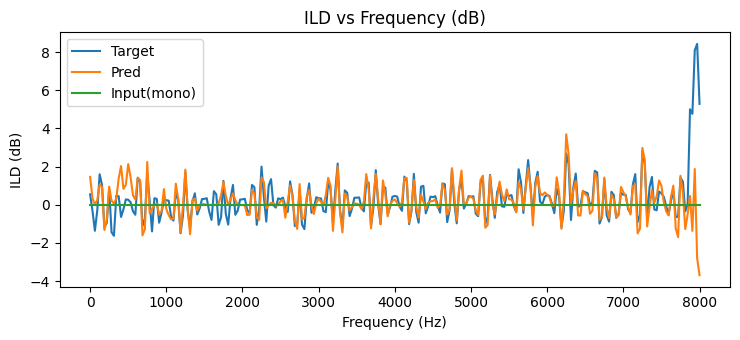

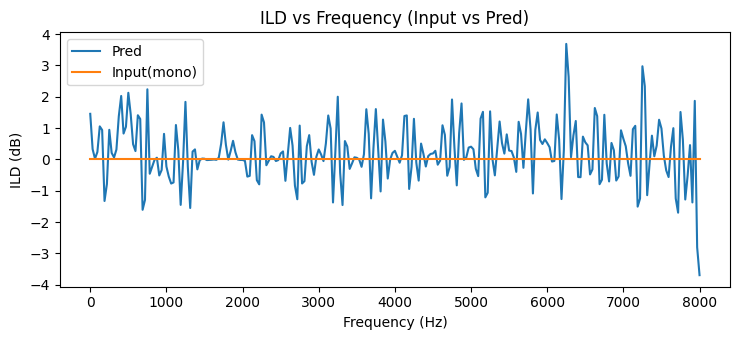

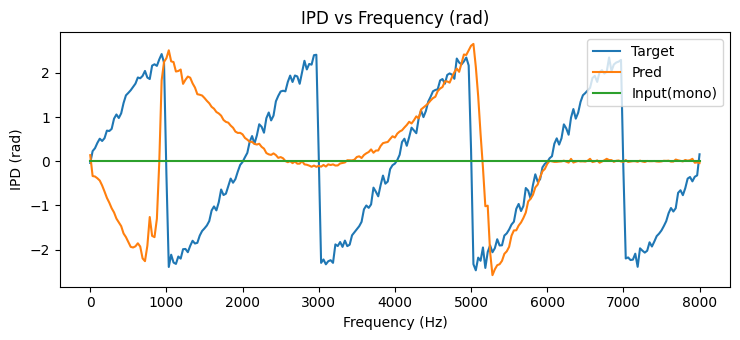

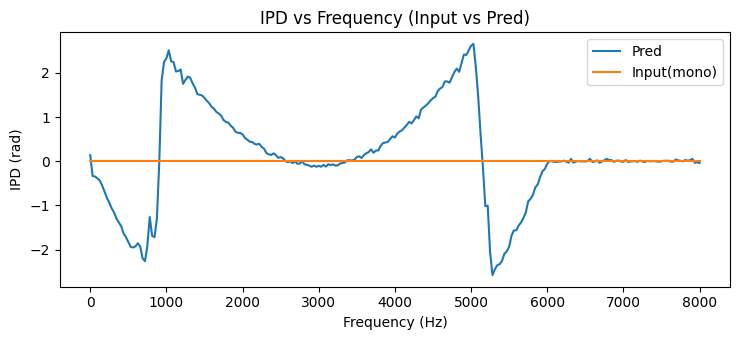

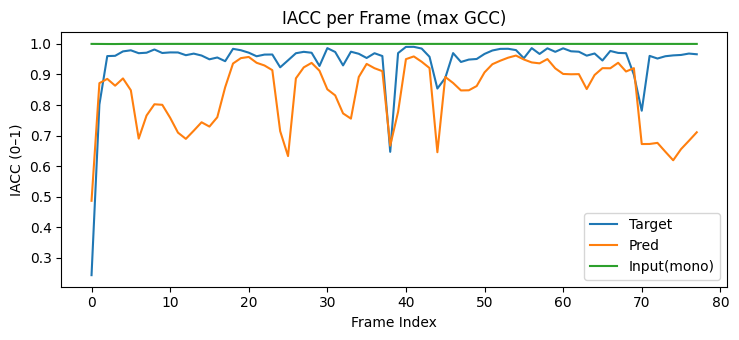

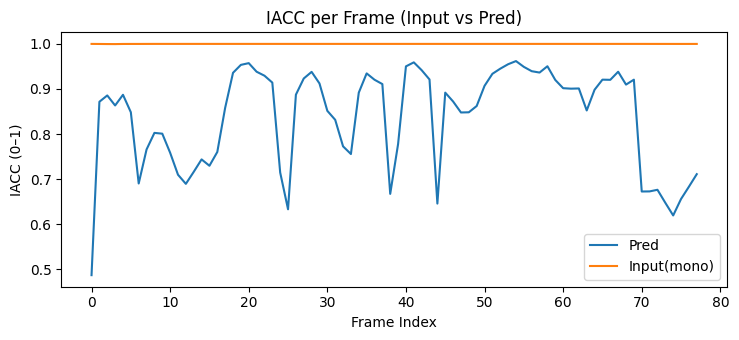

In [ ]:
# =========================================
# Spatial Comparison: Input vs Pred vs Target  (revised + separate Input/Pred plots)
#  - ILD-only + classical IPD evaluation (consistent with listening routine)
#  - Metrics: ILD_RMSE_dB, IPD_L1(rad), IACC_Δmean, downmix SI-SDR
#  Requirements (must already exist globally): stage2_model, DEVICE, TARGET_SR, N_FFT, HOP, WIN
# =========================================
import numpy as np
import torch
import math

# --------- Tunable parameters (consistent with listening) ---------
TAU_MAX_MS          = 0.8      # GCC/regression τ physiological limit
LF_IPD_MAX_HZ       = 1500.0   # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.90     # EMA smoothing factor for τ between frames
ENERGY_FLOOR_DB     = -40.0    # Low-energy frames reuse previous τ
ONLY_LOW_BAND_IPD   = True     # Apply IPD only to low frequencies
IPD_HIGHPASS_TAPER  = 400.0    # Linear decay from this frequency to LF_IPD_MAX_HZ
GCC_VS_REG_BLEND    = 0.20     # Blend ratio: τ = (1-β)*regression + β*GCC

TAU_MAX_MS          = 1.0     # GCC/regression τ physiological limit (ear distance ~18 cm)
LF_IPD_MAX_HZ       = 6000.0  # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.80    # EMA smoothing for τ between frames
ENERGY_FLOOR_DB     = -40.0   # Low-energy frame threshold (relative frame energy in dB, below this reuse previous τ)
ONLY_LOW_BAND_IPD   = True    # Apply IPD only to low frequencies (fade to 0 above LF_IPD_MAX_HZ)
IPD_HIGHPASS_TAPER  = 700.0   # From this frequency to LF_IPD_MAX_HZ linearly fade in/out (avoid abrupt changes)
GCC_VS_REG_BLEND    = 0.60    # In teacher mode: τ = (1-β)*low-freq regression + β*GCC

# ---------- Safe STFT/ISTFT (consistent with listening) ----------
def _win_like(x):
    return torch.hann_window(
        WIN, device=x.device,
        dtype=(x.real.dtype if torch.is_complex(x) else x.dtype)
    )

def _stft_mag_phase_safe(x: torch.Tensor):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(x), center=True, return_complex=True
    )
    return torch.abs(X), X  # [B,F,T], complex

# ---------- GCC-PHAT τ + IACC (with ±τ_max window) ----------
@torch.no_grad()
def _gcc_phat_tau_iacc_local(L: torch.Tensor, R: torch.Tensor, tau_max_ms: float = TAU_MAX_MS):
    if L.dim()==1: L = L.unsqueeze(0)
    if R.dim()==1: R = R.unsqueeze(0)
    Wl = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    Wr = torch.hann_window(WIN, device=R.device, dtype=R.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wl, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wr, center=True, return_complex=True)
    G = XL * torch.conj(XR)
    eps = 1e-8
    G = G / (torch.abs(G) + eps)                     # PHAT
    gcc = torch.fft.irfft(G, n=N_FFT, dim=1)         # [B,N_FFT,T]
    center = N_FFT // 2
    gcc = torch.roll(gcc, shifts=center, dims=1)

    max_samp = max(1, int(float(TARGET_SR) * (tau_max_ms/1000.0)))
    lo, hi = max(0, center - max_samp), min(N_FFT, center + max_samp + 1)
    gcc_win = gcc[:, lo:hi, :]                       # [B,2*max_samp+1,T]
    local_idx = torch.argmax(torch.abs(gcc_win), dim=1)
    iacc = torch.gather(torch.abs(gcc_win), 1, local_idx.unsqueeze(1)).squeeze(1)
    idx = local_idx + lo
    lags = idx - center
    tau_hat = lags.to(torch.float32) / float(TARGET_SR)  # seconds
    return tau_hat, iacc.clamp(0, 1)

# ---------- Low-frequency phase-regression τ (weighted LS + limiting + low-energy protection + EMA) ----------
@torch.no_grad()
def _tau_from_lowfreq_phase_local(L: torch.Tensor, R: torch.Tensor,
                                  fmax_hz: float = LF_IPD_MAX_HZ,
                                  p_power: float = 1.0,
                                  tau_max_ms: float = TAU_MAX_MS,
                                  ema_alpha: float = TAU_EMA_ALPHA,
                                  energy_floor_db: float = ENERGY_FLOOR_DB):
    if L.dim()==1: L=L.unsqueeze(0)
    if R.dim()==1: R=L.unsqueeze(0)
    B = L.size(0)
    W = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)

    F, Tf = XL.size(1), XL.size(2)
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=L.device, dtype=XL.real.dtype)
    lf_mask = (freqs > 1.0) & (freqs <= float(fmax_hz))
    lf_idx  = torch.nonzero(lf_mask, as_tuple=False).squeeze(1)
    if lf_idx.numel() == 0:
        return torch.zeros((B, Tf), device=L.device, dtype=XL.real.dtype)

    angL = torch.angle(XL[:, lf_idx, :])
    angR = torch.angle(XR[:, lf_idx, :])
    ipd  = torch.atan2(torch.sin(angL-angR), torch.cos(angL-angR))          # [-π,π]
    w    = (torch.abs(XL[:, lf_idx, :])**p_power + torch.abs(XR[:, lf_idx, :])**p_power)
    w    = w / (w.mean(dim=1, keepdim=True) + 1e-8)

    omega = (2*math.pi*freqs[lf_idx]).view(1, -1, 1)
    num   = (w * omega * ipd).sum(dim=1)
    den   = (w * (omega**2)).sum(dim=1) + 1e-8
    tau   = num / den

    # Low-energy frames → reuse previous frame
    frame_energy = (torch.abs(XL[:, lf_idx, :])**2 + torch.abs(XR[:, lf_idx, :])**2).mean(dim=1)
    ref = frame_energy.mean(dim=1, keepdim=True) + 1e-12
    energy_db = 10.0 * torch.log10(frame_energy / ref + 1e-12)
    low_mask = (energy_db < float(energy_floor_db))

    # Limiting + EMA
    tau_limit = float(tau_max_ms)/1000.0
    tau = torch.clamp(tau, -tau_limit, +tau_limit)
    tau_smoothed = torch.empty_like(tau)
    for b in range(B):
        prev = tau[b, 0]
        tau_smoothed[b, 0] = prev
        for t in range(1, Tf):
            cur = tau[b, t]
            val = ema_alpha * prev + (1.0 - ema_alpha) * cur
            tau_smoothed[b, t] = torch.where(low_mask[b, t], prev, val)
            prev = tau_smoothed[b, t]
    return tau_smoothed

# ---------- Phase rotators (low-band-only IPD with taper window) ----------
def _make_rotators_from_tau_local(unit_phase: torch.Tensor, tau_hat: torch.Tensor,
                                  only_low_band: bool = ONLY_LOW_BAND_IPD,
                                  lf_max_hz: float = LF_IPD_MAX_HZ,
                                  taper_start_hz: float = IPD_HIGHPASS_TAPER):
    B, F, T = unit_phase.shape
    real_dtype = unit_phase.real.dtype
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=unit_phase.device, dtype=real_dtype)
    omega = 2.0 * math.pi * freqs
    dphi  = omega.view(1, F, 1) * tau_hat.view(B, 1, T)   # real angle

    if only_low_band:
        w = torch.ones((F,), device=unit_phase.device, dtype=real_dtype)
        w = torch.where(freqs <= taper_start_hz, torch.ones_like(w),
                        torch.where(freqs >= lf_max_hz, torch.zeros_like(w),
                                   (lf_max_hz - freqs) / (lf_max_hz - taper_start_hz + 1e-12)))
        dphi = dphi * w.view(1, F, 1)

    rot = torch.polar(torch.ones_like(dphi, dtype=real_dtype, device=unit_phase.device), dphi).to(unit_phase.dtype)
    rotL = rot
    rotR = torch.conj(rot)
    return rotL, rotR

# ---------- Angle → τ ----------
def _tau_from_angle_local(T: int, angle_deg: float, head_width_m=0.18, c=343.0, device=None, dtype=None):
    theta = math.radians(angle_deg)
    tau_const = (head_width_m * math.sin(theta)) / c
    return torch.full((1, T), float(tau_const), device=device, dtype=dtype)

# ---------- ILD-only + classical IPD predictor (same logic as listening) ----------
@torch.no_grad()
def _spatialize_predict_local(
    mono_1d,
    model=None,
    tau_mode: str = "teacher",          # "teacher" | "fixed" | "angle"
    teacher_stereo: np.ndarray = None,  # when tau_mode="teacher", expect [T,2] or [2,T]
    fixed_tau_ms: float = 0.45,
    angle_deg: float = +30.0
):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if not torch.is_tensor(mono_1d):
        mono_1d = torch.tensor(np.asarray(mono_1d, dtype=np.float32))
    x = mono_1d.unsqueeze(0).to(DEVICE)         # [1,T]
    Tlen = x.size(1)

    mag, ph = _stft_mag_phase_safe(x)           # [1,F,T], complex
    inp = torch.log1p(mag).unsqueeze(1)         # [1,1,F,T]
    out = model(inp)
    mask2 = out[0] if isinstance(out, (tuple, list)) else out  # [1,2,F,T]
    est_mag_L = mask2[:,0]*mag
    est_mag_R = mask2[:,1]*mag

    eps  = 1e-8
    unit = ph / (torch.abs(ph) + eps)           # e^{jφ(mono)}  [1,F,T]

    if tau_mode == "teacher":
        assert teacher_stereo is not None, "tau_mode='teacher' requires teacher_stereo"
        st_np = np.asarray(teacher_stereo)
        if st_np.ndim == 2 and st_np.shape[0] == 2: st_np = st_np.T
        assert st_np.ndim == 2 and st_np.shape[1] == 2, f"teacher_stereo shape should be [T,2], got {st_np.shape}"
        tgt_L = torch.tensor(st_np[:,0], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tgt_R = torch.tensor(st_np[:,1], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tau_gcc, _ = _gcc_phat_tau_iacc_local(tgt_L, tgt_R, tau_max_ms=TAU_MAX_MS)
        tau_reg    = _tau_from_lowfreq_phase_local(tgt_L, tgt_R)
        tau_hat    = (1.0 - GCC_VS_REG_BLEND) * tau_reg + GCC_VS_REG_BLEND * tau_gcc
    elif tau_mode == "fixed":
        tau_hat = torch.full((1, mag.size(-1)), float(fixed_tau_ms)/1000.0,
                             device=DEVICE, dtype=mag.real.dtype)
    elif tau_mode == "angle":
        tau_hat = _tau_from_angle_local(mag.size(-1), angle_deg,
                                        device=DEVICE, dtype=mag.real.dtype)
    else:
        raise ValueError(f"Unknown tau_mode: {tau_mode}")

    rotL, rotR = _make_rotators_from_tau_local(unit, tau_hat,
                                               only_low_band=ONLY_LOW_BAND_IPD,
                                               lf_max_hz=LF_IPD_MAX_HZ,
                                               taper_start_hz=IPD_HIGHPASS_TAPER)
    X_L = est_mag_L * (unit * rotL)
    X_R = est_mag_R * (unit * rotR)

    est_L = torch.istft(X_L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_L), center=True, length=Tlen)
    est_R = torch.istft(X_R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_R), center=True, length=Tlen)

    L = est_L[0].detach().float().cpu().numpy()
    R = est_R[0].detach().float().cpu().numpy()
    st = np.stack([L, R], axis=-1).astype(np.float32)
    peak = float(np.max(np.abs(st))) if st.size else 0.0
    if peak > 1.0:
        st = st / (peak + 1e-12)
    return st  # [T,2]

# ---------- Evaluation helpers: STFT→numpy, ILD/IPD/IACC/frequency axis ----------
def _stft_mag_phase_np(x_1d, sr=None):
    if not torch.is_tensor(x_1d):
        x = torch.tensor(np.asarray(x_1d, dtype=np.float32), device=DEVICE)[None, :]
    else:
        x = x_1d.to(DEVICE, dtype=torch.float32)[None, :]
    X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                   window=_win_like(x), center=True, return_complex=True)
    mag = torch.abs(X).detach().cpu().numpy().astype(np.float32)
    ang = torch.angle(X).detach().cpu().numpy().astype(np.float32)
    return mag, ang

def _band_rms(mag):  # [1,F,T]
    return np.sqrt((mag**2).mean(axis=-1) + 1e-12)

def _ild_from_mag(magL, magR):
    rL = _band_rms(magL); rR = _band_rms(magR)
    ild = 20.0*np.log10(rL + 1e-12) - 20.0*np.log10(rR + 1e-12)
    return ild.squeeze(0).astype(np.float32)

def _ipd_from_angle(angL, angR):
    ipd = np.arctan2(np.sin(angL-angR), np.cos(angL-angR))
    return np.mean(ipd, axis=-1).squeeze(0).astype(np.float32)

def _iacc_curve(L_wav, R_wav, frame=1024, hop=512, max_lag=8):
    L = np.asarray(L_wav, dtype=np.float32); R = np.asarray(R_wav, dtype=np.float32)
    T = len(L)
    if T < frame:
        pad = frame - T
        L = np.pad(L, (0,pad)); R = np.pad(R, (0,pad))
        T = frame
    nfrm = 1 + (T - frame)//hop
    vals = []
    eps = 1e-8
    for i in range(nfrm):
        a = L[i*hop:i*hop+frame]; b = R[i*hop:i*hop+frame]
        na = np.sqrt(np.sum(a*a)+eps); nb = np.sqrt(np.sum(b*b)+eps)
        a = a/na; b = b/nb
        peak = -1.0
        for lag in range(-max_lag, max_lag+1):
            if lag < 0:   v = np.dot(a[:frame+lag], b[-lag:])
            elif lag> 0: v = np.dot(a[lag:], b[:frame-lag])
            else:        v = np.dot(a, b)
            if v > peak: peak = v
        vals.append(peak)
    return np.asarray(vals, dtype=np.float32)

def _freq_axis(sr, n_fft):
    return np.fft.rfftfreq(n_fft, d=1.0/sr).astype(np.float32)

# ---------- Main function: compare Input / Pred (ILD-only+classical IPD) / Target ----------
def spatial_compare_one(sample_idx=None,
                        dataset=None,
                        model=None,
                        plot=True,
                        post_gain_db=0.0,
                        tau_mode: str = "teacher",    # "teacher" | "fixed" | "angle"
                        fixed_tau_ms: float = 0.45,
                        angle_deg: float = +30.0):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if dataset is None:
        dataset = globals().get("test_ds_spatial_clean", None) or globals().get("test_dl_spatial_clean", None)
        if dataset is not None and hasattr(dataset, "__iter__"):
            dataset = dataset.dataset
    assert dataset is not None, "Stage-2 test set not found."

    idx = int(np.random.randint(len(dataset)) if sample_idx is None else sample_idx)
    x_in_t, st_tgt_t = dataset[idx]  # x: [T], tgt: [2,T]
    x_in  = (x_in_t.detach().cpu().numpy() if torch.is_tensor(x_in_t) else np.asarray(x_in_t)).astype(np.float32)
    st_gt = (st_tgt_t.detach().cpu().numpy() if torch.is_tensor(st_tgt_t) else np.asarray(st_tgt_t)).astype(np.float32)
    if st_gt.ndim == 2 and st_gt.shape[0] == 2:
        st_gt = st_gt.T

    # Prediction (same logic as listening)
    st_pred = _spatialize_predict_local(
        x_in, model=model,
        tau_mode=tau_mode,
        teacher_stereo=(st_gt if tau_mode=="teacher" else None),
        fixed_tau_ms=fixed_tau_ms,
        angle_deg=angle_deg
    )

    # Align & loudness match
    L = min(len(x_in), st_pred.shape[0], st_gt.shape[0])
    x_in   = x_in[:L]; st_gt = st_gt[:L,:]; st_pred = st_pred[:L,:]
    def _rms(v): return float(np.sqrt(np.mean(np.asarray(v, dtype=np.float64)**2)+1e-12))
    g = _rms(st_gt.mean(axis=1))/max(_rms(st_pred.mean(axis=1)),1e-8) * (10**(post_gain_db/20.0))
    st_pred *= g
    peak = float(np.max(np.abs(st_pred)))
    if peak > 1.0: st_pred /= (peak+1e-12)

    # Frequency-domain metrics
    sr = int(globals().get("TARGET_SR", 16000))
    faxis = _freq_axis(sr, N_FFT)

    mag_in, ang_in = _stft_mag_phase_np(x_in, sr)
    mag_pL, ang_pL = _stft_mag_phase_np(st_pred[:,0], sr)
    mag_pR, ang_pR = _stft_mag_phase_np(st_pred[:,1], sr)
    mag_tL, ang_tL = _stft_mag_phase_np(st_gt[:,0],  sr)
    mag_tR, ang_tR = _stft_mag_phase_np(st_gt[:,1],  sr)

    ild_in   = np.zeros_like(faxis, dtype=np.float32)
    ild_pred = _ild_from_mag(mag_pL, mag_pR)
    ild_tgt  = _ild_from_mag(mag_tL, mag_tR)
    ild_rmse_db = float(np.sqrt(np.mean((ild_pred - ild_tgt)**2)))

    ipd_in   = np.zeros_like(ild_pred, dtype=np.float32)
    ipd_pred = _ipd_from_angle(ang_pL, ang_pR)
    ipd_tgt  = _ipd_from_angle(ang_tL, ang_tR)
    ipd_l1   = float(np.mean(np.abs(ipd_pred - ipd_tgt)))

    # IACC
    iacc_in   = _iacc_curve(x_in, x_in)
    iacc_pred = _iacc_curve(st_pred[:,0], st_pred[:,1])
    iacc_tgt  = _iacc_curve(st_gt[:,0],   st_gt[:,1])
    iacc_delta_mean_pred = float(np.mean(iacc_pred) - np.mean(iacc_tgt))
    iacc_delta_mean_in   = float(np.mean(iacc_in)   - np.mean(iacc_tgt))

    # Downmix SI-SDR
    def _si_sdr_numpy(ref, est, eps=1e-8):
        ref = ref - ref.mean(); est = est - est.mean()
        t = (np.sum(est*ref)/(np.sum(ref*ref)+eps))*ref
        n = est - t
        return 10.0*np.log10((np.sum(t*t)+eps)/(np.sum(n*n)+eps))
    pred_dm = 0.5*(st_pred[:,0]+st_pred[:,1])
    gt_dm   = 0.5*(st_gt[:,0]+st_gt[:,1])
    sdr_pred = _si_sdr_numpy(gt_dm, pred_dm)
    sdr_in   = _si_sdr_numpy(gt_dm, x_in[:len(gt_dm)])

    # Print summary
    print(f"[SpatialCompare] idx={idx} | dur={L/sr:.2f}s | tau_mode={tau_mode}")
    print(f"  ILD_RMSE_dB (pred vs tgt): {ild_rmse_db:.3f} dB")
    print(f"  IPD_L1_rad (pred vs tgt):  {ipd_l1:.3f} rad")
    print(f"  IACC Δmean: pred-tgt={iacc_delta_mean_pred:+.3f} | input-tgt={iacc_delta_mean_in:+.3f}")
    print(f"  Downmix SI-SDR: Input={sdr_in: .2f} dB | Pred={sdr_pred: .2f} dB | Δ={sdr_pred-sdr_in:+.2f} dB")

    # Plot (single axis per figure, no explicit colors) + extra "Input vs Pred" plots
    if plot:
        import matplotlib.pyplot as plt

        # ----- 1) ILD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (dB)")
        plt.plot(faxis, ild_tgt, label="Target")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 2) IPD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (rad)")
        plt.plot(faxis, ipd_tgt, label="Target")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 3) IACC per Frame -----
        t_axis = np.arange(len(iacc_tgt))

        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (max GCC)")
        plt.plot(t_axis, iacc_tgt, label="Target")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (Input vs Pred)")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

    return {
        "idx": idx,
        "ild_pred": ild_pred, "ild_tgt": ild_tgt, "ild_in": ild_in, "ild_rmse_db": ild_rmse_db,
        "ipd_pred": ipd_pred, "ipd_tgt": ipd_tgt, "ipd_in": ipd_in, "ipd_l1_rad": ipd_l1,
        "iacc_pred": iacc_pred, "iacc_tgt": iacc_tgt, "iacc_in": iacc_in,
        "iacc_delta_mean_pred": iacc_delta_mean_pred,
        "iacc_delta_mean_in": iacc_delta_mean_in,
        "sdr_input": sdr_in, "sdr_pred": sdr_pred, "sdr_delta": sdr_pred - sdr_in,
        "freqs": _freq_axis(sr, N_FFT)
    }

# ===== Run one sample and plot =====
_ = spatial_compare_one(sample_idx=None, plot=True, post_gain_db=0.0, tau_mode="teacher")
# Compute metrics only, no plots:
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="fixed", fixed_tau_ms=0.45)
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="angle", angle_deg=+30.0)


[SpatialCompare] idx=460 | dur=2.39s | tau_mode=teacher
  ILD_RMSE_dB (pred vs tgt): 1.190 dB
  IPD_L1_rad (pred vs tgt):  1.456 rad
  IACC Δmean: pred-tgt=-0.108 | input-tgt=+0.072
  Downmix SI-SDR: Input=-0.49 dB | Pred=-15.36 dB | Δ=-14.88 dB


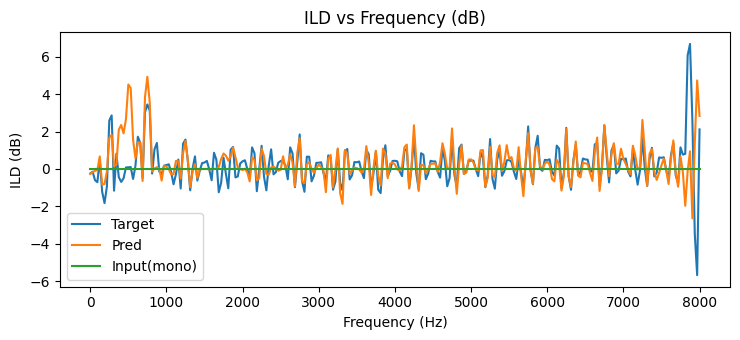

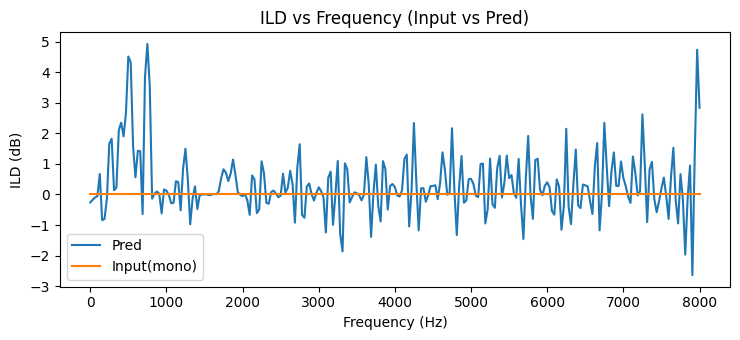

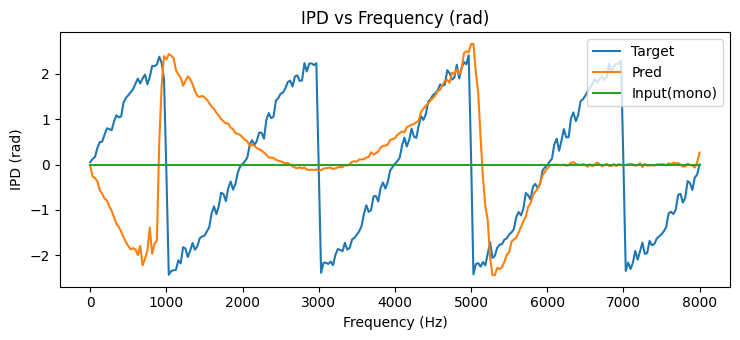

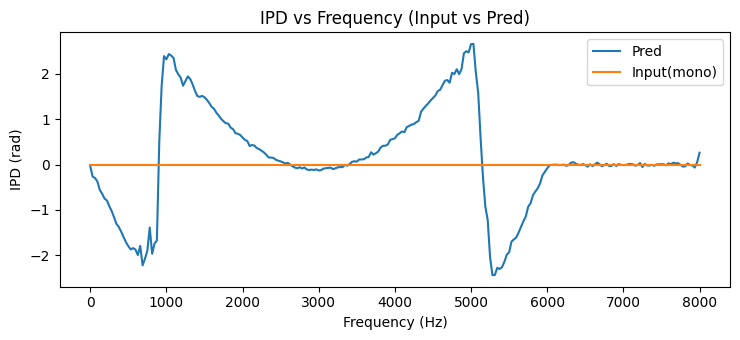

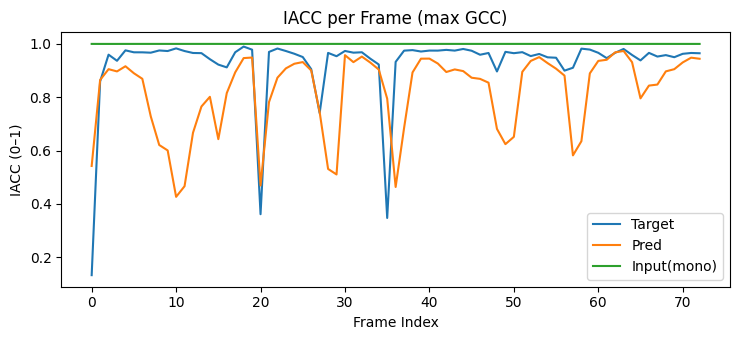

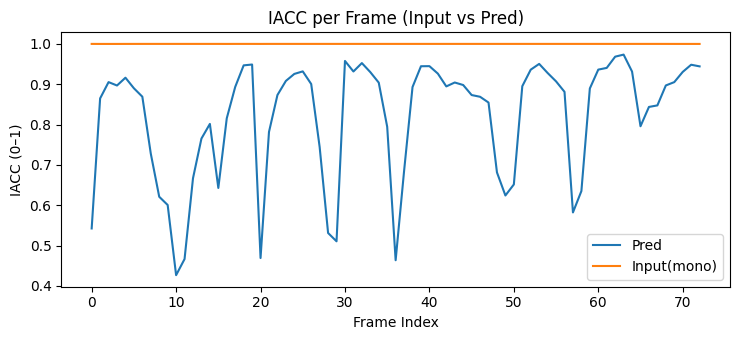

In [ ]:
# =========================================
# Spatial Comparison: Input vs Pred vs Target  (revised + separate Input/Pred plots)
#  - ILD-only + classical IPD evaluation (consistent with listening routine)
#  - Metrics: ILD_RMSE_dB, IPD_L1(rad), IACC_Δmean, downmix SI-SDR
#  Requirements (must already exist globally): stage2_model, DEVICE, TARGET_SR, N_FFT, HOP, WIN
# =========================================
import numpy as np
import torch
import math

# --------- Tunable parameters (consistent with listening) ---------
TAU_MAX_MS          = 0.8      # GCC/regression τ physiological limit
LF_IPD_MAX_HZ       = 1500.0   # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.90     # EMA smoothing factor for τ between frames
ENERGY_FLOOR_DB     = -40.0    # Low-energy frames reuse previous τ
ONLY_LOW_BAND_IPD   = True     # Apply IPD only to low frequencies
IPD_HIGHPASS_TAPER  = 400.0    # Linear decay from this frequency to LF_IPD_MAX_HZ
GCC_VS_REG_BLEND    = 0.20     # Blend ratio: τ = (1-β)*regression + β*GCC

TAU_MAX_MS          = 1.0     # GCC/regression τ physiological limit (ear distance ~18 cm)
LF_IPD_MAX_HZ       = 6000.0  # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.80    # EMA smoothing for τ between frames
ENERGY_FLOOR_DB     = -40.0   # Low-energy frame threshold (relative frame energy in dB, below this reuse previous τ)
ONLY_LOW_BAND_IPD   = True    # Apply IPD only to low frequencies (fade to 0 above LF_IPD_MAX_HZ)
IPD_HIGHPASS_TAPER  = 700.0   # From this frequency to LF_IPD_MAX_HZ linearly fade in/out (avoid abrupt changes)
GCC_VS_REG_BLEND    = 0.60    # In teacher mode: τ = (1-β)*low-freq regression + β*GCC

# ---------- Safe STFT/ISTFT (consistent with listening) ----------
def _win_like(x):
    return torch.hann_window(
        WIN, device=x.device,
        dtype=(x.real.dtype if torch.is_complex(x) else x.dtype)
    )

def _stft_mag_phase_safe(x: torch.Tensor):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(x), center=True, return_complex=True
    )
    return torch.abs(X), X  # [B,F,T], complex

# ---------- GCC-PHAT τ + IACC (with ±τ_max window) ----------
@torch.no_grad()
def _gcc_phat_tau_iacc_local(L: torch.Tensor, R: torch.Tensor, tau_max_ms: float = TAU_MAX_MS):
    if L.dim()==1: L = L.unsqueeze(0)
    if R.dim()==1: R = R.unsqueeze(0)
    Wl = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    Wr = torch.hann_window(WIN, device=R.device, dtype=R.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wl, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wr, center=True, return_complex=True)
    G = XL * torch.conj(XR)
    eps = 1e-8
    G = G / (torch.abs(G) + eps)                     # PHAT
    gcc = torch.fft.irfft(G, n=N_FFT, dim=1)         # [B,N_FFT,T]
    center = N_FFT // 2
    gcc = torch.roll(gcc, shifts=center, dims=1)

    max_samp = max(1, int(float(TARGET_SR) * (tau_max_ms/1000.0)))
    lo, hi = max(0, center - max_samp), min(N_FFT, center + max_samp + 1)
    gcc_win = gcc[:, lo:hi, :]                       # [B,2*max_samp+1,T]
    local_idx = torch.argmax(torch.abs(gcc_win), dim=1)
    iacc = torch.gather(torch.abs(gcc_win), 1, local_idx.unsqueeze(1)).squeeze(1)
    idx = local_idx + lo
    lags = idx - center
    tau_hat = lags.to(torch.float32) / float(TARGET_SR)  # seconds
    return tau_hat, iacc.clamp(0, 1)

# ---------- Low-frequency phase-regression τ (weighted LS + limiting + low-energy protection + EMA) ----------
@torch.no_grad()
def _tau_from_lowfreq_phase_local(L: torch.Tensor, R: torch.Tensor,
                                  fmax_hz: float = LF_IPD_MAX_HZ,
                                  p_power: float = 1.0,
                                  tau_max_ms: float = TAU_MAX_MS,
                                  ema_alpha: float = TAU_EMA_ALPHA,
                                  energy_floor_db: float = ENERGY_FLOOR_DB):
    if L.dim()==1: L=L.unsqueeze(0)
    if R.dim()==1: R=L.unsqueeze(0)
    B = L.size(0)
    W = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)

    F, Tf = XL.size(1), XL.size(2)
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=L.device, dtype=XL.real.dtype)
    lf_mask = (freqs > 1.0) & (freqs <= float(fmax_hz))
    lf_idx  = torch.nonzero(lf_mask, as_tuple=False).squeeze(1)
    if lf_idx.numel() == 0:
        return torch.zeros((B, Tf), device=L.device, dtype=XL.real.dtype)

    angL = torch.angle(XL[:, lf_idx, :])
    angR = torch.angle(XR[:, lf_idx, :])
    ipd  = torch.atan2(torch.sin(angL-angR), torch.cos(angL-angR))          # [-π,π]
    w    = (torch.abs(XL[:, lf_idx, :])**p_power + torch.abs(XR[:, lf_idx, :])**p_power)
    w    = w / (w.mean(dim=1, keepdim=True) + 1e-8)

    omega = (2*math.pi*freqs[lf_idx]).view(1, -1, 1)
    num   = (w * omega * ipd).sum(dim=1)
    den   = (w * (omega**2)).sum(dim=1) + 1e-8
    tau   = num / den

    # Low-energy frames → reuse previous frame
    frame_energy = (torch.abs(XL[:, lf_idx, :])**2 + torch.abs(XR[:, lf_idx, :])**2).mean(dim=1)
    ref = frame_energy.mean(dim=1, keepdim=True) + 1e-12
    energy_db = 10.0 * torch.log10(frame_energy / ref + 1e-12)
    low_mask = (energy_db < float(energy_floor_db))

    # Limiting + EMA
    tau_limit = float(tau_max_ms)/1000.0
    tau = torch.clamp(tau, -tau_limit, +tau_limit)
    tau_smoothed = torch.empty_like(tau)
    for b in range(B):
        prev = tau[b, 0]
        tau_smoothed[b, 0] = prev
        for t in range(1, Tf):
            cur = tau[b, t]
            val = ema_alpha * prev + (1.0 - ema_alpha) * cur
            tau_smoothed[b, t] = torch.where(low_mask[b, t], prev, val)
            prev = tau_smoothed[b, t]
    return tau_smoothed

# ---------- Phase rotators (low-band-only IPD with taper window) ----------
def _make_rotators_from_tau_local(unit_phase: torch.Tensor, tau_hat: torch.Tensor,
                                  only_low_band: bool = ONLY_LOW_BAND_IPD,
                                  lf_max_hz: float = LF_IPD_MAX_HZ,
                                  taper_start_hz: float = IPD_HIGHPASS_TAPER):
    B, F, T = unit_phase.shape
    real_dtype = unit_phase.real.dtype
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=unit_phase.device, dtype=real_dtype)
    omega = 2.0 * math.pi * freqs
    dphi  = omega.view(1, F, 1) * tau_hat.view(B, 1, T)   # real angle

    if only_low_band:
        w = torch.ones((F,), device=unit_phase.device, dtype=real_dtype)
        w = torch.where(freqs <= taper_start_hz, torch.ones_like(w),
                        torch.where(freqs >= lf_max_hz, torch.zeros_like(w),
                                   (lf_max_hz - freqs) / (lf_max_hz - taper_start_hz + 1e-12)))
        dphi = dphi * w.view(1, F, 1)

    rot = torch.polar(torch.ones_like(dphi, dtype=real_dtype, device=unit_phase.device), dphi).to(unit_phase.dtype)
    rotL = rot
    rotR = torch.conj(rot)
    return rotL, rotR

# ---------- Angle → τ ----------
def _tau_from_angle_local(T: int, angle_deg: float, head_width_m=0.18, c=343.0, device=None, dtype=None):
    theta = math.radians(angle_deg)
    tau_const = (head_width_m * math.sin(theta)) / c
    return torch.full((1, T), float(tau_const), device=device, dtype=dtype)

# ---------- ILD-only + classical IPD predictor (same logic as listening) ----------
@torch.no_grad()
def _spatialize_predict_local(
    mono_1d,
    model=None,
    tau_mode: str = "teacher",          # "teacher" | "fixed" | "angle"
    teacher_stereo: np.ndarray = None,  # when tau_mode="teacher", expect [T,2] or [2,T]
    fixed_tau_ms: float = 0.45,
    angle_deg: float = +30.0
):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if not torch.is_tensor(mono_1d):
        mono_1d = torch.tensor(np.asarray(mono_1d, dtype=np.float32))
    x = mono_1d.unsqueeze(0).to(DEVICE)         # [1,T]
    Tlen = x.size(1)

    mag, ph = _stft_mag_phase_safe(x)           # [1,F,T], complex
    inp = torch.log1p(mag).unsqueeze(1)         # [1,1,F,T]
    out = model(inp)
    mask2 = out[0] if isinstance(out, (tuple, list)) else out  # [1,2,F,T]
    est_mag_L = mask2[:,0]*mag
    est_mag_R = mask2[:,1]*mag

    eps  = 1e-8
    unit = ph / (torch.abs(ph) + eps)           # e^{jφ(mono)}  [1,F,T]

    if tau_mode == "teacher":
        assert teacher_stereo is not None, "tau_mode='teacher' requires teacher_stereo"
        st_np = np.asarray(teacher_stereo)
        if st_np.ndim == 2 and st_np.shape[0] == 2: st_np = st_np.T
        assert st_np.ndim == 2 and st_np.shape[1] == 2, f"teacher_stereo shape should be [T,2], got {st_np.shape}"
        tgt_L = torch.tensor(st_np[:,0], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tgt_R = torch.tensor(st_np[:,1], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tau_gcc, _ = _gcc_phat_tau_iacc_local(tgt_L, tgt_R, tau_max_ms=TAU_MAX_MS)
        tau_reg    = _tau_from_lowfreq_phase_local(tgt_L, tgt_R)
        tau_hat    = (1.0 - GCC_VS_REG_BLEND) * tau_reg + GCC_VS_REG_BLEND * tau_gcc
    elif tau_mode == "fixed":
        tau_hat = torch.full((1, mag.size(-1)), float(fixed_tau_ms)/1000.0,
                             device=DEVICE, dtype=mag.real.dtype)
    elif tau_mode == "angle":
        tau_hat = _tau_from_angle_local(mag.size(-1), angle_deg,
                                        device=DEVICE, dtype=mag.real.dtype)
    else:
        raise ValueError(f"Unknown tau_mode: {tau_mode}")

    rotL, rotR = _make_rotators_from_tau_local(unit, tau_hat,
                                               only_low_band=ONLY_LOW_BAND_IPD,
                                               lf_max_hz=LF_IPD_MAX_HZ,
                                               taper_start_hz=IPD_HIGHPASS_TAPER)
    X_L = est_mag_L * (unit * rotL)
    X_R = est_mag_R * (unit * rotR)

    est_L = torch.istft(X_L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_L), center=True, length=Tlen)
    est_R = torch.istft(X_R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_R), center=True, length=Tlen)

    L = est_L[0].detach().float().cpu().numpy()
    R = est_R[0].detach().float().cpu().numpy()
    st = np.stack([L, R], axis=-1).astype(np.float32)
    peak = float(np.max(np.abs(st))) if st.size else 0.0
    if peak > 1.0:
        st = st / (peak + 1e-12)
    return st  # [T,2]

# ---------- Evaluation helpers: STFT→numpy, ILD/IPD/IACC/frequency axis ----------
def _stft_mag_phase_np(x_1d, sr=None):
    if not torch.is_tensor(x_1d):
        x = torch.tensor(np.asarray(x_1d, dtype=np.float32), device=DEVICE)[None, :]
    else:
        x = x_1d.to(DEVICE, dtype=torch.float32)[None, :]
    X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                   window=_win_like(x), center=True, return_complex=True)
    mag = torch.abs(X).detach().cpu().numpy().astype(np.float32)
    ang = torch.angle(X).detach().cpu().numpy().astype(np.float32)
    return mag, ang

def _band_rms(mag):  # [1,F,T]
    return np.sqrt((mag**2).mean(axis=-1) + 1e-12)

def _ild_from_mag(magL, magR):
    rL = _band_rms(magL); rR = _band_rms(magR)
    ild = 20.0*np.log10(rL + 1e-12) - 20.0*np.log10(rR + 1e-12)
    return ild.squeeze(0).astype(np.float32)

def _ipd_from_angle(angL, angR):
    ipd = np.arctan2(np.sin(angL-angR), np.cos(angL-angR))
    return np.mean(ipd, axis=-1).squeeze(0).astype(np.float32)

def _iacc_curve(L_wav, R_wav, frame=1024, hop=512, max_lag=8):
    L = np.asarray(L_wav, dtype=np.float32); R = np.asarray(R_wav, dtype=np.float32)
    T = len(L)
    if T < frame:
        pad = frame - T
        L = np.pad(L, (0,pad)); R = np.pad(R, (0,pad))
        T = frame
    nfrm = 1 + (T - frame)//hop
    vals = []
    eps = 1e-8
    for i in range(nfrm):
        a = L[i*hop:i*hop+frame]; b = R[i*hop:i*hop+frame]
        na = np.sqrt(np.sum(a*a)+eps); nb = np.sqrt(np.sum(b*b)+eps)
        a = a/na; b = b/nb
        peak = -1.0
        for lag in range(-max_lag, max_lag+1):
            if lag < 0:   v = np.dot(a[:frame+lag], b[-lag:])
            elif lag> 0: v = np.dot(a[lag:], b[:frame-lag])
            else:        v = np.dot(a, b)
            if v > peak: peak = v
        vals.append(peak)
    return np.asarray(vals, dtype=np.float32)

def _freq_axis(sr, n_fft):
    return np.fft.rfftfreq(n_fft, d=1.0/sr).astype(np.float32)

# ---------- Main function: compare Input / Pred (ILD-only+classical IPD) / Target ----------
def spatial_compare_one(sample_idx=None,
                        dataset=None,
                        model=None,
                        plot=True,
                        post_gain_db=0.0,
                        tau_mode: str = "teacher",    # "teacher" | "fixed" | "angle"
                        fixed_tau_ms: float = 0.45,
                        angle_deg: float = +30.0):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if dataset is None:
        dataset = globals().get("test_ds_spatial_clean", None) or globals().get("test_dl_spatial_clean", None)
        if dataset is not None and hasattr(dataset, "__iter__"):
            dataset = dataset.dataset
    assert dataset is not None, "Stage-2 test set not found."

    idx = int(np.random.randint(len(dataset)) if sample_idx is None else sample_idx)
    x_in_t, st_tgt_t = dataset[idx]  # x: [T], tgt: [2,T]
    x_in  = (x_in_t.detach().cpu().numpy() if torch.is_tensor(x_in_t) else np.asarray(x_in_t)).astype(np.float32)
    st_gt = (st_tgt_t.detach().cpu().numpy() if torch.is_tensor(st_tgt_t) else np.asarray(st_tgt_t)).astype(np.float32)
    if st_gt.ndim == 2 and st_gt.shape[0] == 2:
        st_gt = st_gt.T

    # Prediction (same logic as listening)
    st_pred = _spatialize_predict_local(
        x_in, model=model,
        tau_mode=tau_mode,
        teacher_stereo=(st_gt if tau_mode=="teacher" else None),
        fixed_tau_ms=fixed_tau_ms,
        angle_deg=angle_deg
    )

    # Align & loudness match
    L = min(len(x_in), st_pred.shape[0], st_gt.shape[0])
    x_in   = x_in[:L]; st_gt = st_gt[:L,:]; st_pred = st_pred[:L,:]
    def _rms(v): return float(np.sqrt(np.mean(np.asarray(v, dtype=np.float64)**2)+1e-12))
    g = _rms(st_gt.mean(axis=1))/max(_rms(st_pred.mean(axis=1)),1e-8) * (10**(post_gain_db/20.0))
    st_pred *= g
    peak = float(np.max(np.abs(st_pred)))
    if peak > 1.0: st_pred /= (peak+1e-12)

    # Frequency-domain metrics
    sr = int(globals().get("TARGET_SR", 16000))
    faxis = _freq_axis(sr, N_FFT)

    mag_in, ang_in = _stft_mag_phase_np(x_in, sr)
    mag_pL, ang_pL = _stft_mag_phase_np(st_pred[:,0], sr)
    mag_pR, ang_pR = _stft_mag_phase_np(st_pred[:,1], sr)
    mag_tL, ang_tL = _stft_mag_phase_np(st_gt[:,0],  sr)
    mag_tR, ang_tR = _stft_mag_phase_np(st_gt[:,1],  sr)

    ild_in   = np.zeros_like(faxis, dtype=np.float32)
    ild_pred = _ild_from_mag(mag_pL, mag_pR)
    ild_tgt  = _ild_from_mag(mag_tL, mag_tR)
    ild_rmse_db = float(np.sqrt(np.mean((ild_pred - ild_tgt)**2)))

    ipd_in   = np.zeros_like(ild_pred, dtype=np.float32)
    ipd_pred = _ipd_from_angle(ang_pL, ang_pR)
    ipd_tgt  = _ipd_from_angle(ang_tL, ang_tR)
    ipd_l1   = float(np.mean(np.abs(ipd_pred - ipd_tgt)))

    # IACC
    iacc_in   = _iacc_curve(x_in, x_in)
    iacc_pred = _iacc_curve(st_pred[:,0], st_pred[:,1])
    iacc_tgt  = _iacc_curve(st_gt[:,0],   st_gt[:,1])
    iacc_delta_mean_pred = float(np.mean(iacc_pred) - np.mean(iacc_tgt))
    iacc_delta_mean_in   = float(np.mean(iacc_in)   - np.mean(iacc_tgt))

    # Downmix SI-SDR
    def _si_sdr_numpy(ref, est, eps=1e-8):
        ref = ref - ref.mean(); est = est - est.mean()
        t = (np.sum(est*ref)/(np.sum(ref*ref)+eps))*ref
        n = est - t
        return 10.0*np.log10((np.sum(t*t)+eps)/(np.sum(n*n)+eps))
    pred_dm = 0.5*(st_pred[:,0]+st_pred[:,1])
    gt_dm   = 0.5*(st_gt[:,0]+st_gt[:,1])
    sdr_pred = _si_sdr_numpy(gt_dm, pred_dm)
    sdr_in   = _si_sdr_numpy(gt_dm, x_in[:len(gt_dm)])

    # Print summary
    print(f"[SpatialCompare] idx={idx} | dur={L/sr:.2f}s | tau_mode={tau_mode}")
    print(f"  ILD_RMSE_dB (pred vs tgt): {ild_rmse_db:.3f} dB")
    print(f"  IPD_L1_rad (pred vs tgt):  {ipd_l1:.3f} rad")
    print(f"  IACC Δmean: pred-tgt={iacc_delta_mean_pred:+.3f} | input-tgt={iacc_delta_mean_in:+.3f}")
    print(f"  Downmix SI-SDR: Input={sdr_in: .2f} dB | Pred={sdr_pred: .2f} dB | Δ={sdr_pred-sdr_in:+.2f} dB")

    # Plot (single axis per figure, no explicit colors) + extra "Input vs Pred" plots
    if plot:
        import matplotlib.pyplot as plt

        # ----- 1) ILD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (dB)")
        plt.plot(faxis, ild_tgt, label="Target")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 2) IPD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (rad)")
        plt.plot(faxis, ipd_tgt, label="Target")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 3) IACC per Frame -----
        t_axis = np.arange(len(iacc_tgt))

        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (max GCC)")
        plt.plot(t_axis, iacc_tgt, label="Target")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (Input vs Pred)")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

    return {
        "idx": idx,
        "ild_pred": ild_pred, "ild_tgt": ild_tgt, "ild_in": ild_in, "ild_rmse_db": ild_rmse_db,
        "ipd_pred": ipd_pred, "ipd_tgt": ipd_tgt, "ipd_in": ipd_in, "ipd_l1_rad": ipd_l1,
        "iacc_pred": iacc_pred, "iacc_tgt": iacc_tgt, "iacc_in": iacc_in,
        "iacc_delta_mean_pred": iacc_delta_mean_pred,
        "iacc_delta_mean_in": iacc_delta_mean_in,
        "sdr_input": sdr_in, "sdr_pred": sdr_pred, "sdr_delta": sdr_pred - sdr_in,
        "freqs": _freq_axis(sr, N_FFT)
    }

# ===== Run one sample and plot =====
_ = spatial_compare_one(sample_idx=None, plot=True, post_gain_db=0.0, tau_mode="teacher")
# Compute metrics only, no plots:
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="fixed", fixed_tau_ms=0.45)
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="angle", angle_deg=+30.0)



[SpatialCompare] idx=483 | dur=1.65s | tau_mode=teacher
  ILD_RMSE_dB (pred vs tgt): 1.104 dB
  IPD_L1_rad (pred vs tgt):  1.444 rad
  IACC Δmean: pred-tgt=-0.130 | input-tgt=+0.062
  Downmix SI-SDR: Input= 1.06 dB | Pred=-3.65 dB | Δ=-4.71 dB


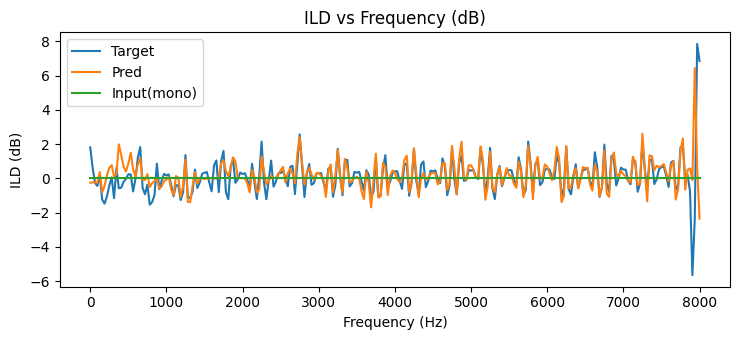

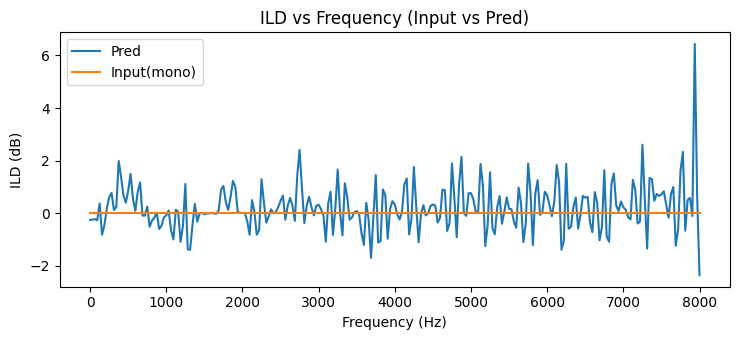

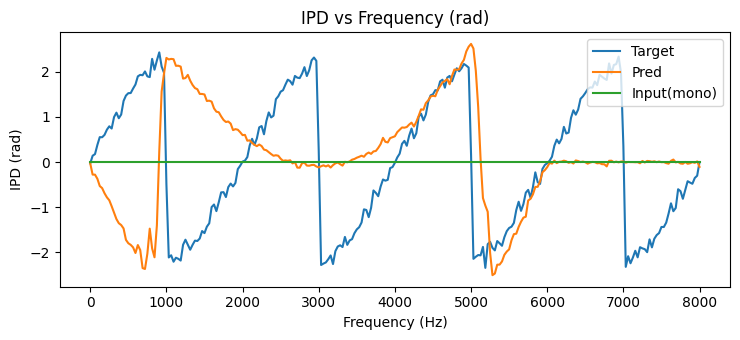

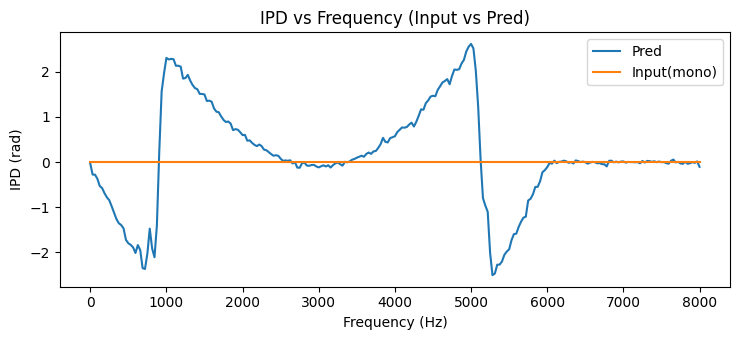

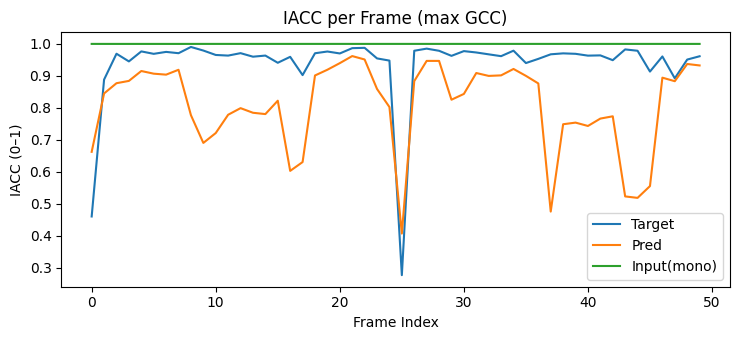

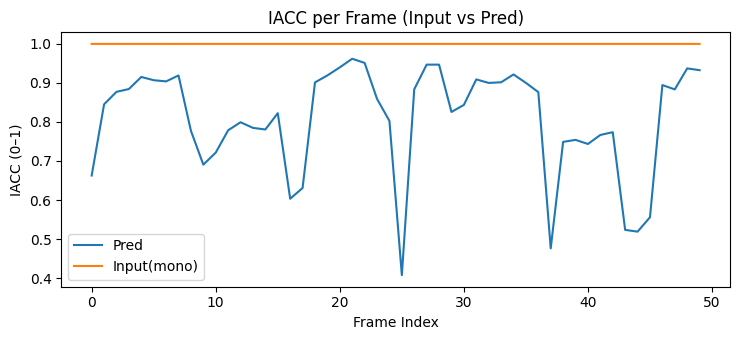

In [ ]:
# =========================================
# Spatial Comparison: Input vs Pred vs Target  (revised + separate Input/Pred plots)
#  - ILD-only + classical IPD evaluation (consistent with listening routine)
#  - Metrics: ILD_RMSE_dB, IPD_L1(rad), IACC_Δmean, downmix SI-SDR
#  Requirements (must already exist globally): stage2_model, DEVICE, TARGET_SR, N_FFT, HOP, WIN
# =========================================
import numpy as np
import torch
import math

# --------- Tunable parameters (consistent with listening) ---------
TAU_MAX_MS          = 0.8      # GCC/regression τ physiological limit
LF_IPD_MAX_HZ       = 1500.0   # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.90     # EMA smoothing factor for τ between frames
ENERGY_FLOOR_DB     = -40.0    # Low-energy frames reuse previous τ
ONLY_LOW_BAND_IPD   = True     # Apply IPD only to low frequencies
IPD_HIGHPASS_TAPER  = 400.0    # Linear decay from this frequency to LF_IPD_MAX_HZ
GCC_VS_REG_BLEND    = 0.20     # Blend ratio: τ = (1-β)*regression + β*GCC

TAU_MAX_MS          = 1.0     # GCC/regression τ physiological limit (ear distance ~18 cm)
LF_IPD_MAX_HZ       = 6000.0  # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.80    # EMA smoothing for τ between frames
ENERGY_FLOOR_DB     = -40.0   # Low-energy frame threshold (relative frame energy in dB, below this reuse previous τ)
ONLY_LOW_BAND_IPD   = True    # Apply IPD only to low frequencies (fade to 0 above LF_IPD_MAX_HZ)
IPD_HIGHPASS_TAPER  = 700.0   # From this frequency to LF_IPD_MAX_HZ linearly fade in/out (avoid abrupt changes)
GCC_VS_REG_BLEND    = 0.60    # In teacher mode: τ = (1-β)*low-freq regression + β*GCC

# ---------- Safe STFT/ISTFT (consistent with listening) ----------
def _win_like(x):
    return torch.hann_window(
        WIN, device=x.device,
        dtype=(x.real.dtype if torch.is_complex(x) else x.dtype)
    )

def _stft_mag_phase_safe(x: torch.Tensor):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(x), center=True, return_complex=True
    )
    return torch.abs(X), X  # [B,F,T], complex

# ---------- GCC-PHAT τ + IACC (with ±τ_max window) ----------
@torch.no_grad()
def _gcc_phat_tau_iacc_local(L: torch.Tensor, R: torch.Tensor, tau_max_ms: float = TAU_MAX_MS):
    if L.dim()==1: L = L.unsqueeze(0)
    if R.dim()==1: R = R.unsqueeze(0)
    Wl = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    Wr = torch.hann_window(WIN, device=R.device, dtype=R.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wl, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wr, center=True, return_complex=True)
    G = XL * torch.conj(XR)
    eps = 1e-8
    G = G / (torch.abs(G) + eps)                     # PHAT
    gcc = torch.fft.irfft(G, n=N_FFT, dim=1)         # [B,N_FFT,T]
    center = N_FFT // 2
    gcc = torch.roll(gcc, shifts=center, dims=1)

    max_samp = max(1, int(float(TARGET_SR) * (tau_max_ms/1000.0)))
    lo, hi = max(0, center - max_samp), min(N_FFT, center + max_samp + 1)
    gcc_win = gcc[:, lo:hi, :]                       # [B,2*max_samp+1,T]
    local_idx = torch.argmax(torch.abs(gcc_win), dim=1)
    iacc = torch.gather(torch.abs(gcc_win), 1, local_idx.unsqueeze(1)).squeeze(1)
    idx = local_idx + lo
    lags = idx - center
    tau_hat = lags.to(torch.float32) / float(TARGET_SR)  # seconds
    return tau_hat, iacc.clamp(0, 1)

# ---------- Low-frequency phase-regression τ (weighted LS + limiting + low-energy protection + EMA) ----------
@torch.no_grad()
def _tau_from_lowfreq_phase_local(L: torch.Tensor, R: torch.Tensor,
                                  fmax_hz: float = LF_IPD_MAX_HZ,
                                  p_power: float = 1.0,
                                  tau_max_ms: float = TAU_MAX_MS,
                                  ema_alpha: float = TAU_EMA_ALPHA,
                                  energy_floor_db: float = ENERGY_FLOOR_DB):
    if L.dim()==1: L=L.unsqueeze(0)
    if R.dim()==1: R=L.unsqueeze(0)
    B = L.size(0)
    W = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)

    F, Tf = XL.size(1), XL.size(2)
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=L.device, dtype=XL.real.dtype)
    lf_mask = (freqs > 1.0) & (freqs <= float(fmax_hz))
    lf_idx  = torch.nonzero(lf_mask, as_tuple=False).squeeze(1)
    if lf_idx.numel() == 0:
        return torch.zeros((B, Tf), device=L.device, dtype=XL.real.dtype)

    angL = torch.angle(XL[:, lf_idx, :])
    angR = torch.angle(XR[:, lf_idx, :])
    ipd  = torch.atan2(torch.sin(angL-angR), torch.cos(angL-angR))          # [-π,π]
    w    = (torch.abs(XL[:, lf_idx, :])**p_power + torch.abs(XR[:, lf_idx, :])**p_power)
    w    = w / (w.mean(dim=1, keepdim=True) + 1e-8)

    omega = (2*math.pi*freqs[lf_idx]).view(1, -1, 1)
    num   = (w * omega * ipd).sum(dim=1)
    den   = (w * (omega**2)).sum(dim=1) + 1e-8
    tau   = num / den

    # Low-energy frames → reuse previous frame
    frame_energy = (torch.abs(XL[:, lf_idx, :])**2 + torch.abs(XR[:, lf_idx, :])**2).mean(dim=1)
    ref = frame_energy.mean(dim=1, keepdim=True) + 1e-12
    energy_db = 10.0 * torch.log10(frame_energy / ref + 1e-12)
    low_mask = (energy_db < float(energy_floor_db))

    # Limiting + EMA
    tau_limit = float(tau_max_ms)/1000.0
    tau = torch.clamp(tau, -tau_limit, +tau_limit)
    tau_smoothed = torch.empty_like(tau)
    for b in range(B):
        prev = tau[b, 0]
        tau_smoothed[b, 0] = prev
        for t in range(1, Tf):
            cur = tau[b, t]
            val = ema_alpha * prev + (1.0 - ema_alpha) * cur
            tau_smoothed[b, t] = torch.where(low_mask[b, t], prev, val)
            prev = tau_smoothed[b, t]
    return tau_smoothed

# ---------- Phase rotators (low-band-only IPD with taper window) ----------
def _make_rotators_from_tau_local(unit_phase: torch.Tensor, tau_hat: torch.Tensor,
                                  only_low_band: bool = ONLY_LOW_BAND_IPD,
                                  lf_max_hz: float = LF_IPD_MAX_HZ,
                                  taper_start_hz: float = IPD_HIGHPASS_TAPER):
    B, F, T = unit_phase.shape
    real_dtype = unit_phase.real.dtype
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=unit_phase.device, dtype=real_dtype)
    omega = 2.0 * math.pi * freqs
    dphi  = omega.view(1, F, 1) * tau_hat.view(B, 1, T)   # real angle

    if only_low_band:
        w = torch.ones((F,), device=unit_phase.device, dtype=real_dtype)
        w = torch.where(freqs <= taper_start_hz, torch.ones_like(w),
                        torch.where(freqs >= lf_max_hz, torch.zeros_like(w),
                                   (lf_max_hz - freqs) / (lf_max_hz - taper_start_hz + 1e-12)))
        dphi = dphi * w.view(1, F, 1)

    rot = torch.polar(torch.ones_like(dphi, dtype=real_dtype, device=unit_phase.device), dphi).to(unit_phase.dtype)
    rotL = rot
    rotR = torch.conj(rot)
    return rotL, rotR

# ---------- Angle → τ ----------
def _tau_from_angle_local(T: int, angle_deg: float, head_width_m=0.18, c=343.0, device=None, dtype=None):
    theta = math.radians(angle_deg)
    tau_const = (head_width_m * math.sin(theta)) / c
    return torch.full((1, T), float(tau_const), device=device, dtype=dtype)

# ---------- ILD-only + classical IPD predictor (same logic as listening) ----------
@torch.no_grad()
def _spatialize_predict_local(
    mono_1d,
    model=None,
    tau_mode: str = "teacher",          # "teacher" | "fixed" | "angle"
    teacher_stereo: np.ndarray = None,  # when tau_mode="teacher", expect [T,2] or [2,T]
    fixed_tau_ms: float = 0.45,
    angle_deg: float = +30.0
):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if not torch.is_tensor(mono_1d):
        mono_1d = torch.tensor(np.asarray(mono_1d, dtype=np.float32))
    x = mono_1d.unsqueeze(0).to(DEVICE)         # [1,T]
    Tlen = x.size(1)

    mag, ph = _stft_mag_phase_safe(x)           # [1,F,T], complex
    inp = torch.log1p(mag).unsqueeze(1)         # [1,1,F,T]
    out = model(inp)
    mask2 = out[0] if isinstance(out, (tuple, list)) else out  # [1,2,F,T]
    est_mag_L = mask2[:,0]*mag
    est_mag_R = mask2[:,1]*mag

    eps  = 1e-8
    unit = ph / (torch.abs(ph) + eps)           # e^{jφ(mono)}  [1,F,T]

    if tau_mode == "teacher":
        assert teacher_stereo is not None, "tau_mode='teacher' requires teacher_stereo"
        st_np = np.asarray(teacher_stereo)
        if st_np.ndim == 2 and st_np.shape[0] == 2: st_np = st_np.T
        assert st_np.ndim == 2 and st_np.shape[1] == 2, f"teacher_stereo shape should be [T,2], got {st_np.shape}"
        tgt_L = torch.tensor(st_np[:,0], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tgt_R = torch.tensor(st_np[:,1], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tau_gcc, _ = _gcc_phat_tau_iacc_local(tgt_L, tgt_R, tau_max_ms=TAU_MAX_MS)
        tau_reg    = _tau_from_lowfreq_phase_local(tgt_L, tgt_R)
        tau_hat    = (1.0 - GCC_VS_REG_BLEND) * tau_reg + GCC_VS_REG_BLEND * tau_gcc
    elif tau_mode == "fixed":
        tau_hat = torch.full((1, mag.size(-1)), float(fixed_tau_ms)/1000.0,
                             device=DEVICE, dtype=mag.real.dtype)
    elif tau_mode == "angle":
        tau_hat = _tau_from_angle_local(mag.size(-1), angle_deg,
                                        device=DEVICE, dtype=mag.real.dtype)
    else:
        raise ValueError(f"Unknown tau_mode: {tau_mode}")

    rotL, rotR = _make_rotators_from_tau_local(unit, tau_hat,
                                               only_low_band=ONLY_LOW_BAND_IPD,
                                               lf_max_hz=LF_IPD_MAX_HZ,
                                               taper_start_hz=IPD_HIGHPASS_TAPER)
    X_L = est_mag_L * (unit * rotL)
    X_R = est_mag_R * (unit * rotR)

    est_L = torch.istft(X_L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_L), center=True, length=Tlen)
    est_R = torch.istft(X_R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_R), center=True, length=Tlen)

    L = est_L[0].detach().float().cpu().numpy()
    R = est_R[0].detach().float().cpu().numpy()
    st = np.stack([L, R], axis=-1).astype(np.float32)
    peak = float(np.max(np.abs(st))) if st.size else 0.0
    if peak > 1.0:
        st = st / (peak + 1e-12)
    return st  # [T,2]

# ---------- Evaluation helpers: STFT→numpy, ILD/IPD/IACC/frequency axis ----------
def _stft_mag_phase_np(x_1d, sr=None):
    if not torch.is_tensor(x_1d):
        x = torch.tensor(np.asarray(x_1d, dtype=np.float32), device=DEVICE)[None, :]
    else:
        x = x_1d.to(DEVICE, dtype=torch.float32)[None, :]
    X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                   window=_win_like(x), center=True, return_complex=True)
    mag = torch.abs(X).detach().cpu().numpy().astype(np.float32)
    ang = torch.angle(X).detach().cpu().numpy().astype(np.float32)
    return mag, ang

def _band_rms(mag):  # [1,F,T]
    return np.sqrt((mag**2).mean(axis=-1) + 1e-12)

def _ild_from_mag(magL, magR):
    rL = _band_rms(magL); rR = _band_rms(magR)
    ild = 20.0*np.log10(rL + 1e-12) - 20.0*np.log10(rR + 1e-12)
    return ild.squeeze(0).astype(np.float32)

def _ipd_from_angle(angL, angR):
    ipd = np.arctan2(np.sin(angL-angR), np.cos(angL-angR))
    return np.mean(ipd, axis=-1).squeeze(0).astype(np.float32)

def _iacc_curve(L_wav, R_wav, frame=1024, hop=512, max_lag=8):
    L = np.asarray(L_wav, dtype=np.float32); R = np.asarray(R_wav, dtype=np.float32)
    T = len(L)
    if T < frame:
        pad = frame - T
        L = np.pad(L, (0,pad)); R = np.pad(R, (0,pad))
        T = frame
    nfrm = 1 + (T - frame)//hop
    vals = []
    eps = 1e-8
    for i in range(nfrm):
        a = L[i*hop:i*hop+frame]; b = R[i*hop:i*hop+frame]
        na = np.sqrt(np.sum(a*a)+eps); nb = np.sqrt(np.sum(b*b)+eps)
        a = a/na; b = b/nb
        peak = -1.0
        for lag in range(-max_lag, max_lag+1):
            if lag < 0:   v = np.dot(a[:frame+lag], b[-lag:])
            elif lag> 0: v = np.dot(a[lag:], b[:frame-lag])
            else:        v = np.dot(a, b)
            if v > peak: peak = v
        vals.append(peak)
    return np.asarray(vals, dtype=np.float32)

def _freq_axis(sr, n_fft):
    return np.fft.rfftfreq(n_fft, d=1.0/sr).astype(np.float32)

# ---------- Main function: compare Input / Pred (ILD-only+classical IPD) / Target ----------
def spatial_compare_one(sample_idx=None,
                        dataset=None,
                        model=None,
                        plot=True,
                        post_gain_db=0.0,
                        tau_mode: str = "teacher",    # "teacher" | "fixed" | "angle"
                        fixed_tau_ms: float = 0.45,
                        angle_deg: float = +30.0):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if dataset is None:
        dataset = globals().get("test_ds_spatial_clean", None) or globals().get("test_dl_spatial_clean", None)
        if dataset is not None and hasattr(dataset, "__iter__"):
            dataset = dataset.dataset
    assert dataset is not None, "Stage-2 test set not found."

    idx = int(np.random.randint(len(dataset)) if sample_idx is None else sample_idx)
    x_in_t, st_tgt_t = dataset[idx]  # x: [T], tgt: [2,T]
    x_in  = (x_in_t.detach().cpu().numpy() if torch.is_tensor(x_in_t) else np.asarray(x_in_t)).astype(np.float32)
    st_gt = (st_tgt_t.detach().cpu().numpy() if torch.is_tensor(st_tgt_t) else np.asarray(st_tgt_t)).astype(np.float32)
    if st_gt.ndim == 2 and st_gt.shape[0] == 2:
        st_gt = st_gt.T

    # Prediction (same logic as listening)
    st_pred = _spatialize_predict_local(
        x_in, model=model,
        tau_mode=tau_mode,
        teacher_stereo=(st_gt if tau_mode=="teacher" else None),
        fixed_tau_ms=fixed_tau_ms,
        angle_deg=angle_deg
    )

    # Align & loudness match
    L = min(len(x_in), st_pred.shape[0], st_gt.shape[0])
    x_in   = x_in[:L]; st_gt = st_gt[:L,:]; st_pred = st_pred[:L,:]
    def _rms(v): return float(np.sqrt(np.mean(np.asarray(v, dtype=np.float64)**2)+1e-12))
    g = _rms(st_gt.mean(axis=1))/max(_rms(st_pred.mean(axis=1)),1e-8) * (10**(post_gain_db/20.0))
    st_pred *= g
    peak = float(np.max(np.abs(st_pred)))
    if peak > 1.0: st_pred /= (peak+1e-12)

    # Frequency-domain metrics
    sr = int(globals().get("TARGET_SR", 16000))
    faxis = _freq_axis(sr, N_FFT)

    mag_in, ang_in = _stft_mag_phase_np(x_in, sr)
    mag_pL, ang_pL = _stft_mag_phase_np(st_pred[:,0], sr)
    mag_pR, ang_pR = _stft_mag_phase_np(st_pred[:,1], sr)
    mag_tL, ang_tL = _stft_mag_phase_np(st_gt[:,0],  sr)
    mag_tR, ang_tR = _stft_mag_phase_np(st_gt[:,1],  sr)

    ild_in   = np.zeros_like(faxis, dtype=np.float32)
    ild_pred = _ild_from_mag(mag_pL, mag_pR)
    ild_tgt  = _ild_from_mag(mag_tL, mag_tR)
    ild_rmse_db = float(np.sqrt(np.mean((ild_pred - ild_tgt)**2)))

    ipd_in   = np.zeros_like(ild_pred, dtype=np.float32)
    ipd_pred = _ipd_from_angle(ang_pL, ang_pR)
    ipd_tgt  = _ipd_from_angle(ang_tL, ang_tR)
    ipd_l1   = float(np.mean(np.abs(ipd_pred - ipd_tgt)))

    # IACC
    iacc_in   = _iacc_curve(x_in, x_in)
    iacc_pred = _iacc_curve(st_pred[:,0], st_pred[:,1])
    iacc_tgt  = _iacc_curve(st_gt[:,0],   st_gt[:,1])
    iacc_delta_mean_pred = float(np.mean(iacc_pred) - np.mean(iacc_tgt))
    iacc_delta_mean_in   = float(np.mean(iacc_in)   - np.mean(iacc_tgt))

    # Downmix SI-SDR
    def _si_sdr_numpy(ref, est, eps=1e-8):
        ref = ref - ref.mean(); est = est - est.mean()
        t = (np.sum(est*ref)/(np.sum(ref*ref)+eps))*ref
        n = est - t
        return 10.0*np.log10((np.sum(t*t)+eps)/(np.sum(n*n)+eps))
    pred_dm = 0.5*(st_pred[:,0]+st_pred[:,1])
    gt_dm   = 0.5*(st_gt[:,0]+st_gt[:,1])
    sdr_pred = _si_sdr_numpy(gt_dm, pred_dm)
    sdr_in   = _si_sdr_numpy(gt_dm, x_in[:len(gt_dm)])

    # Print summary
    print(f"[SpatialCompare] idx={idx} | dur={L/sr:.2f}s | tau_mode={tau_mode}")
    print(f"  ILD_RMSE_dB (pred vs tgt): {ild_rmse_db:.3f} dB")
    print(f"  IPD_L1_rad (pred vs tgt):  {ipd_l1:.3f} rad")
    print(f"  IACC Δmean: pred-tgt={iacc_delta_mean_pred:+.3f} | input-tgt={iacc_delta_mean_in:+.3f}")
    print(f"  Downmix SI-SDR: Input={sdr_in: .2f} dB | Pred={sdr_pred: .2f} dB | Δ={sdr_pred-sdr_in:+.2f} dB")

    # Plot (single axis per figure, no explicit colors) + extra "Input vs Pred" plots
    if plot:
        import matplotlib.pyplot as plt

        # ----- 1) ILD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (dB)")
        plt.plot(faxis, ild_tgt, label="Target")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 2) IPD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (rad)")
        plt.plot(faxis, ipd_tgt, label="Target")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 3) IACC per Frame -----
        t_axis = np.arange(len(iacc_tgt))

        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (max GCC)")
        plt.plot(t_axis, iacc_tgt, label="Target")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (Input vs Pred)")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

    return {
        "idx": idx,
        "ild_pred": ild_pred, "ild_tgt": ild_tgt, "ild_in": ild_in, "ild_rmse_db": ild_rmse_db,
        "ipd_pred": ipd_pred, "ipd_tgt": ipd_tgt, "ipd_in": ipd_in, "ipd_l1_rad": ipd_l1,
        "iacc_pred": iacc_pred, "iacc_tgt": iacc_tgt, "iacc_in": iacc_in,
        "iacc_delta_mean_pred": iacc_delta_mean_pred,
        "iacc_delta_mean_in": iacc_delta_mean_in,
        "sdr_input": sdr_in, "sdr_pred": sdr_pred, "sdr_delta": sdr_pred - sdr_in,
        "freqs": _freq_axis(sr, N_FFT)
    }

# ===== Run one sample and plot =====
_ = spatial_compare_one(sample_idx=None, plot=True, post_gain_db=0.0, tau_mode="teacher")
# Compute metrics only, no plots:
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="fixed", fixed_tau_ms=0.45)
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="angle", angle_deg=+30.0)



[SpatialCompare] idx=769 | dur=2.22s | tau_mode=teacher
  ILD_RMSE_dB (pred vs tgt): 0.863 dB
  IPD_L1_rad (pred vs tgt):  1.467 rad
  IACC Δmean: pred-tgt=-0.053 | input-tgt=+0.060
  Downmix SI-SDR: Input=-0.58 dB | Pred=-2.89 dB | Δ=-2.31 dB


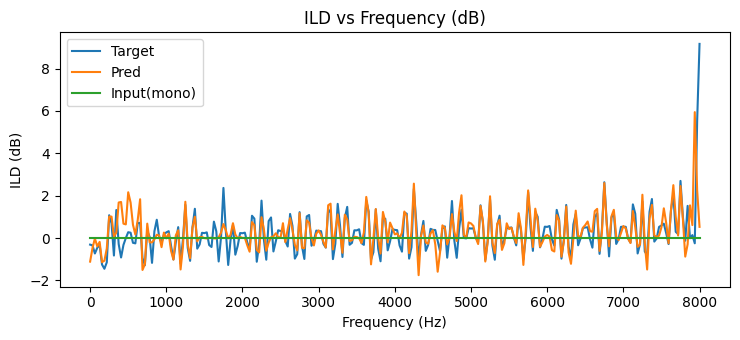

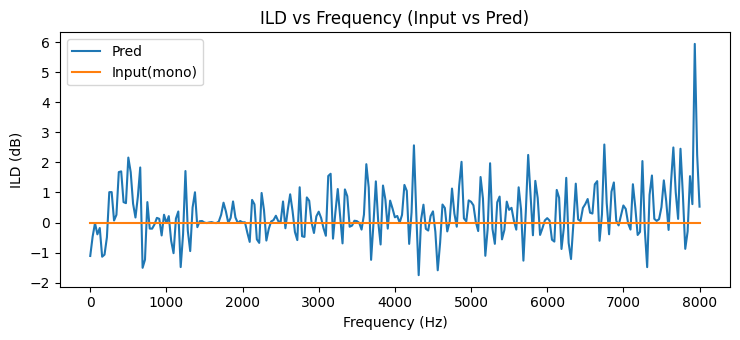

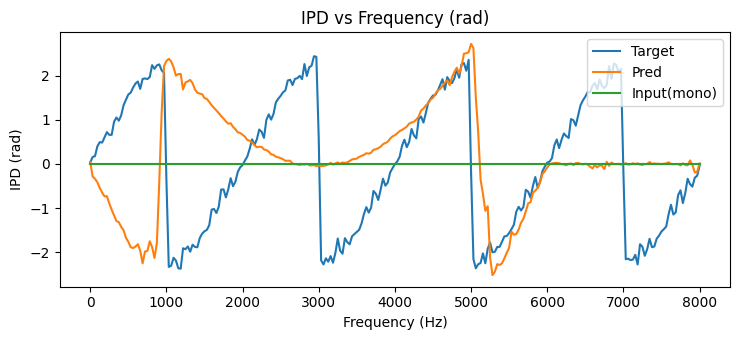

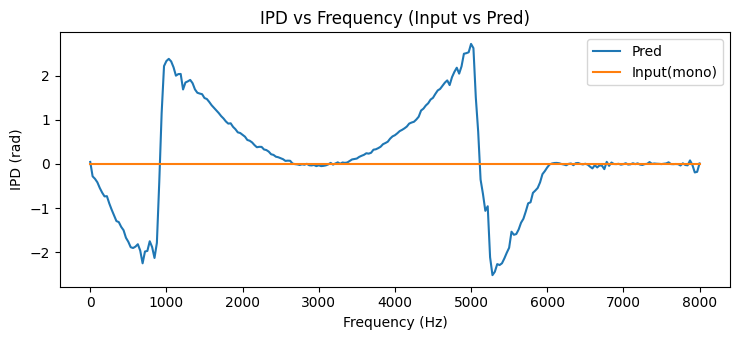

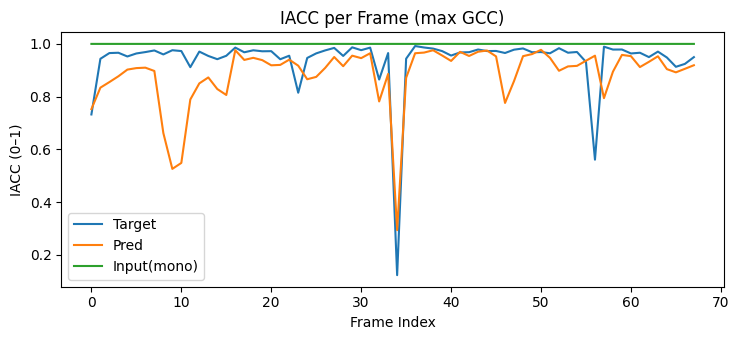

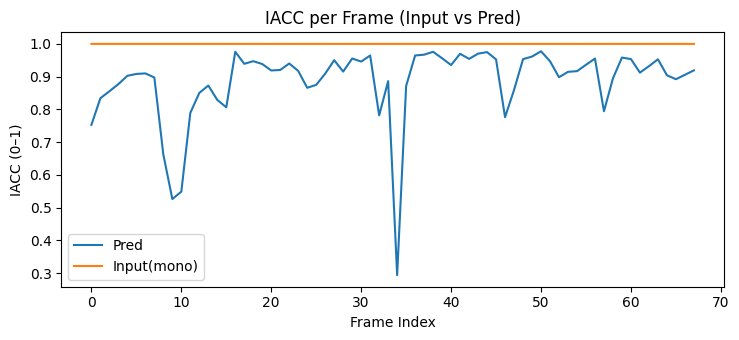

In [ ]:
# =========================================
# Spatial Comparison: Input vs Pred vs Target  (revised + separate Input/Pred plots)
#  - ILD-only + classical IPD evaluation (consistent with listening routine)
#  - Metrics: ILD_RMSE_dB, IPD_L1(rad), IACC_Δmean, downmix SI-SDR
#  Requirements (must already exist globally): stage2_model, DEVICE, TARGET_SR, N_FFT, HOP, WIN
# =========================================
import numpy as np
import torch
import math

# --------- Tunable parameters (consistent with listening) ---------
TAU_MAX_MS          = 0.8      # GCC/regression τ physiological limit
LF_IPD_MAX_HZ       = 1500.0   # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.90     # EMA smoothing factor for τ between frames
ENERGY_FLOOR_DB     = -40.0    # Low-energy frames reuse previous τ
ONLY_LOW_BAND_IPD   = True     # Apply IPD only to low frequencies
IPD_HIGHPASS_TAPER  = 400.0    # Linear decay from this frequency to LF_IPD_MAX_HZ
GCC_VS_REG_BLEND    = 0.20     # Blend ratio: τ = (1-β)*regression + β*GCC

TAU_MAX_MS          = 1.0     # GCC/regression τ physiological limit (ear distance ~18 cm)
LF_IPD_MAX_HZ       = 6000.0  # Upper limit for low-frequency phase regression
TAU_EMA_ALPHA       = 0.80    # EMA smoothing for τ between frames
ENERGY_FLOOR_DB     = -40.0   # Low-energy frame threshold (relative frame energy in dB, below this reuse previous τ)
ONLY_LOW_BAND_IPD   = True    # Apply IPD only to low frequencies (fade to 0 above LF_IPD_MAX_HZ)
IPD_HIGHPASS_TAPER  = 700.0   # From this frequency to LF_IPD_MAX_HZ linearly fade in/out (avoid abrupt changes)
GCC_VS_REG_BLEND    = 0.60    # In teacher mode: τ = (1-β)*low-freq regression + β*GCC

# ---------- Safe STFT/ISTFT (consistent with listening) ----------
def _win_like(x):
    return torch.hann_window(
        WIN, device=x.device,
        dtype=(x.real.dtype if torch.is_complex(x) else x.dtype)
    )

def _stft_mag_phase_safe(x: torch.Tensor):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    X = torch.stft(
        x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
        window=_win_like(x), center=True, return_complex=True
    )
    return torch.abs(X), X  # [B,F,T], complex

# ---------- GCC-PHAT τ + IACC (with ±τ_max window) ----------
@torch.no_grad()
def _gcc_phat_tau_iacc_local(L: torch.Tensor, R: torch.Tensor, tau_max_ms: float = TAU_MAX_MS):
    if L.dim()==1: L = L.unsqueeze(0)
    if R.dim()==1: R = R.unsqueeze(0)
    Wl = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    Wr = torch.hann_window(WIN, device=R.device, dtype=R.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wl, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                    window=Wr, center=True, return_complex=True)
    G = XL * torch.conj(XR)
    eps = 1e-8
    G = G / (torch.abs(G) + eps)                     # PHAT
    gcc = torch.fft.irfft(G, n=N_FFT, dim=1)         # [B,N_FFT,T]
    center = N_FFT // 2
    gcc = torch.roll(gcc, shifts=center, dims=1)

    max_samp = max(1, int(float(TARGET_SR) * (tau_max_ms/1000.0)))
    lo, hi = max(0, center - max_samp), min(N_FFT, center + max_samp + 1)
    gcc_win = gcc[:, lo:hi, :]                       # [B,2*max_samp+1,T]
    local_idx = torch.argmax(torch.abs(gcc_win), dim=1)
    iacc = torch.gather(torch.abs(gcc_win), 1, local_idx.unsqueeze(1)).squeeze(1)
    idx = local_idx + lo
    lags = idx - center
    tau_hat = lags.to(torch.float32) / float(TARGET_SR)  # seconds
    return tau_hat, iacc.clamp(0, 1)

# ---------- Low-frequency phase-regression τ (weighted LS + limiting + low-energy protection + EMA) ----------
@torch.no_grad()
def _tau_from_lowfreq_phase_local(L: torch.Tensor, R: torch.Tensor,
                                  fmax_hz: float = LF_IPD_MAX_HZ,
                                  p_power: float = 1.0,
                                  tau_max_ms: float = TAU_MAX_MS,
                                  ema_alpha: float = TAU_EMA_ALPHA,
                                  energy_floor_db: float = ENERGY_FLOOR_DB):
    if L.dim()==1: L=L.unsqueeze(0)
    if R.dim()==1: R=L.unsqueeze(0)
    B = L.size(0)
    W = torch.hann_window(WIN, device=L.device, dtype=L.dtype)
    XL = torch.stft(L, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)
    XR = torch.stft(R, n_fft=N_FFT, hop_length=HOP, win_length=WIN, window=W, center=True, return_complex=True)

    F, Tf = XL.size(1), XL.size(2)
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=L.device, dtype=XL.real.dtype)
    lf_mask = (freqs > 1.0) & (freqs <= float(fmax_hz))
    lf_idx  = torch.nonzero(lf_mask, as_tuple=False).squeeze(1)
    if lf_idx.numel() == 0:
        return torch.zeros((B, Tf), device=L.device, dtype=XL.real.dtype)

    angL = torch.angle(XL[:, lf_idx, :])
    angR = torch.angle(XR[:, lf_idx, :])
    ipd  = torch.atan2(torch.sin(angL-angR), torch.cos(angL-angR))          # [-π,π]
    w    = (torch.abs(XL[:, lf_idx, :])**p_power + torch.abs(XR[:, lf_idx, :])**p_power)
    w    = w / (w.mean(dim=1, keepdim=True) + 1e-8)

    omega = (2*math.pi*freqs[lf_idx]).view(1, -1, 1)
    num   = (w * omega * ipd).sum(dim=1)
    den   = (w * (omega**2)).sum(dim=1) + 1e-8
    tau   = num / den

    # Low-energy frames → reuse previous frame
    frame_energy = (torch.abs(XL[:, lf_idx, :])**2 + torch.abs(XR[:, lf_idx, :])**2).mean(dim=1)
    ref = frame_energy.mean(dim=1, keepdim=True) + 1e-12
    energy_db = 10.0 * torch.log10(frame_energy / ref + 1e-12)
    low_mask = (energy_db < float(energy_floor_db))

    # Limiting + EMA
    tau_limit = float(tau_max_ms)/1000.0
    tau = torch.clamp(tau, -tau_limit, +tau_limit)
    tau_smoothed = torch.empty_like(tau)
    for b in range(B):
        prev = tau[b, 0]
        tau_smoothed[b, 0] = prev
        for t in range(1, Tf):
            cur = tau[b, t]
            val = ema_alpha * prev + (1.0 - ema_alpha) * cur
            tau_smoothed[b, t] = torch.where(low_mask[b, t], prev, val)
            prev = tau_smoothed[b, t]
    return tau_smoothed

# ---------- Phase rotators (low-band-only IPD with taper window) ----------
def _make_rotators_from_tau_local(unit_phase: torch.Tensor, tau_hat: torch.Tensor,
                                  only_low_band: bool = ONLY_LOW_BAND_IPD,
                                  lf_max_hz: float = LF_IPD_MAX_HZ,
                                  taper_start_hz: float = IPD_HIGHPASS_TAPER):
    B, F, T = unit_phase.shape
    real_dtype = unit_phase.real.dtype
    freqs = torch.linspace(0, TARGET_SR/2, steps=F, device=unit_phase.device, dtype=real_dtype)
    omega = 2.0 * math.pi * freqs
    dphi  = omega.view(1, F, 1) * tau_hat.view(B, 1, T)   # real angle

    if only_low_band:
        w = torch.ones((F,), device=unit_phase.device, dtype=real_dtype)
        w = torch.where(freqs <= taper_start_hz, torch.ones_like(w),
                        torch.where(freqs >= lf_max_hz, torch.zeros_like(w),
                                   (lf_max_hz - freqs) / (lf_max_hz - taper_start_hz + 1e-12)))
        dphi = dphi * w.view(1, F, 1)

    rot = torch.polar(torch.ones_like(dphi, dtype=real_dtype, device=unit_phase.device), dphi).to(unit_phase.dtype)
    rotL = rot
    rotR = torch.conj(rot)
    return rotL, rotR

# ---------- Angle → τ ----------
def _tau_from_angle_local(T: int, angle_deg: float, head_width_m=0.18, c=343.0, device=None, dtype=None):
    theta = math.radians(angle_deg)
    tau_const = (head_width_m * math.sin(theta)) / c
    return torch.full((1, T), float(tau_const), device=device, dtype=dtype)

# ---------- ILD-only + classical IPD predictor (same logic as listening) ----------
@torch.no_grad()
def _spatialize_predict_local(
    mono_1d,
    model=None,
    tau_mode: str = "teacher",          # "teacher" | "fixed" | "angle"
    teacher_stereo: np.ndarray = None,  # when tau_mode="teacher", expect [T,2] or [2,T]
    fixed_tau_ms: float = 0.45,
    angle_deg: float = +30.0
):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if not torch.is_tensor(mono_1d):
        mono_1d = torch.tensor(np.asarray(mono_1d, dtype=np.float32))
    x = mono_1d.unsqueeze(0).to(DEVICE)         # [1,T]
    Tlen = x.size(1)

    mag, ph = _stft_mag_phase_safe(x)           # [1,F,T], complex
    inp = torch.log1p(mag).unsqueeze(1)         # [1,1,F,T]
    out = model(inp)
    mask2 = out[0] if isinstance(out, (tuple, list)) else out  # [1,2,F,T]
    est_mag_L = mask2[:,0]*mag
    est_mag_R = mask2[:,1]*mag

    eps  = 1e-8
    unit = ph / (torch.abs(ph) + eps)           # e^{jφ(mono)}  [1,F,T]

    if tau_mode == "teacher":
        assert teacher_stereo is not None, "tau_mode='teacher' requires teacher_stereo"
        st_np = np.asarray(teacher_stereo)
        if st_np.ndim == 2 and st_np.shape[0] == 2: st_np = st_np.T
        assert st_np.ndim == 2 and st_np.shape[1] == 2, f"teacher_stereo shape should be [T,2], got {st_np.shape}"
        tgt_L = torch.tensor(st_np[:,0], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tgt_R = torch.tensor(st_np[:,1], dtype=x.dtype, device=DEVICE).unsqueeze(0)
        tau_gcc, _ = _gcc_phat_tau_iacc_local(tgt_L, tgt_R, tau_max_ms=TAU_MAX_MS)
        tau_reg    = _tau_from_lowfreq_phase_local(tgt_L, tgt_R)
        tau_hat    = (1.0 - GCC_VS_REG_BLEND) * tau_reg + GCC_VS_REG_BLEND * tau_gcc
    elif tau_mode == "fixed":
        tau_hat = torch.full((1, mag.size(-1)), float(fixed_tau_ms)/1000.0,
                             device=DEVICE, dtype=mag.real.dtype)
    elif tau_mode == "angle":
        tau_hat = _tau_from_angle_local(mag.size(-1), angle_deg,
                                        device=DEVICE, dtype=mag.real.dtype)
    else:
        raise ValueError(f"Unknown tau_mode: {tau_mode}")

    rotL, rotR = _make_rotators_from_tau_local(unit, tau_hat,
                                               only_low_band=ONLY_LOW_BAND_IPD,
                                               lf_max_hz=LF_IPD_MAX_HZ,
                                               taper_start_hz=IPD_HIGHPASS_TAPER)
    X_L = est_mag_L * (unit * rotL)
    X_R = est_mag_R * (unit * rotR)

    est_L = torch.istft(X_L, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_L), center=True, length=Tlen)
    est_R = torch.istft(X_R, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=_win_like(X_R), center=True, length=Tlen)

    L = est_L[0].detach().float().cpu().numpy()
    R = est_R[0].detach().float().cpu().numpy()
    st = np.stack([L, R], axis=-1).astype(np.float32)
    peak = float(np.max(np.abs(st))) if st.size else 0.0
    if peak > 1.0:
        st = st / (peak + 1e-12)
    return st  # [T,2]

# ---------- Evaluation helpers: STFT→numpy, ILD/IPD/IACC/frequency axis ----------
def _stft_mag_phase_np(x_1d, sr=None):
    if not torch.is_tensor(x_1d):
        x = torch.tensor(np.asarray(x_1d, dtype=np.float32), device=DEVICE)[None, :]
    else:
        x = x_1d.to(DEVICE, dtype=torch.float32)[None, :]
    X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                   window=_win_like(x), center=True, return_complex=True)
    mag = torch.abs(X).detach().cpu().numpy().astype(np.float32)
    ang = torch.angle(X).detach().cpu().numpy().astype(np.float32)
    return mag, ang

def _band_rms(mag):  # [1,F,T]
    return np.sqrt((mag**2).mean(axis=-1) + 1e-12)

def _ild_from_mag(magL, magR):
    rL = _band_rms(magL); rR = _band_rms(magR)
    ild = 20.0*np.log10(rL + 1e-12) - 20.0*np.log10(rR + 1e-12)
    return ild.squeeze(0).astype(np.float32)

def _ipd_from_angle(angL, angR):
    ipd = np.arctan2(np.sin(angL-angR), np.cos(angL-angR))
    return np.mean(ipd, axis=-1).squeeze(0).astype(np.float32)

def _iacc_curve(L_wav, R_wav, frame=1024, hop=512, max_lag=8):
    L = np.asarray(L_wav, dtype=np.float32); R = np.asarray(R_wav, dtype=np.float32)
    T = len(L)
    if T < frame:
        pad = frame - T
        L = np.pad(L, (0,pad)); R = np.pad(R, (0,pad))
        T = frame
    nfrm = 1 + (T - frame)//hop
    vals = []
    eps = 1e-8
    for i in range(nfrm):
        a = L[i*hop:i*hop+frame]; b = R[i*hop:i*hop+frame]
        na = np.sqrt(np.sum(a*a)+eps); nb = np.sqrt(np.sum(b*b)+eps)
        a = a/na; b = b/nb
        peak = -1.0
        for lag in range(-max_lag, max_lag+1):
            if lag < 0:   v = np.dot(a[:frame+lag], b[-lag:])
            elif lag> 0: v = np.dot(a[lag:], b[:frame-lag])
            else:        v = np.dot(a, b)
            if v > peak: peak = v
        vals.append(peak)
    return np.asarray(vals, dtype=np.float32)

def _freq_axis(sr, n_fft):
    return np.fft.rfftfreq(n_fft, d=1.0/sr).astype(np.float32)

# ---------- Main function: compare Input / Pred (ILD-only+classical IPD) / Target ----------
def spatial_compare_one(sample_idx=None,
                        dataset=None,
                        model=None,
                        plot=True,
                        post_gain_db=0.0,
                        tau_mode: str = "teacher",    # "teacher" | "fixed" | "angle"
                        fixed_tau_ms: float = 0.45,
                        angle_deg: float = +30.0):
    if model is None:
        model = globals().get("stage2_model", None)
    assert model is not None, "stage2_model is not defined."

    if dataset is None:
        dataset = globals().get("test_ds_spatial_clean", None) or globals().get("test_dl_spatial_clean", None)
        if dataset is not None and hasattr(dataset, "__iter__"):
            dataset = dataset.dataset
    assert dataset is not None, "Stage-2 test set not found."

    idx = int(np.random.randint(len(dataset)) if sample_idx is None else sample_idx)
    x_in_t, st_tgt_t = dataset[idx]  # x: [T], tgt: [2,T]
    x_in  = (x_in_t.detach().cpu().numpy() if torch.is_tensor(x_in_t) else np.asarray(x_in_t)).astype(np.float32)
    st_gt = (st_tgt_t.detach().cpu().numpy() if torch.is_tensor(st_tgt_t) else np.asarray(st_tgt_t)).astype(np.float32)
    if st_gt.ndim == 2 and st_gt.shape[0] == 2:
        st_gt = st_gt.T

    # Prediction (same logic as listening)
    st_pred = _spatialize_predict_local(
        x_in, model=model,
        tau_mode=tau_mode,
        teacher_stereo=(st_gt if tau_mode=="teacher" else None),
        fixed_tau_ms=fixed_tau_ms,
        angle_deg=angle_deg
    )

    # Align & loudness match
    L = min(len(x_in), st_pred.shape[0], st_gt.shape[0])
    x_in   = x_in[:L]; st_gt = st_gt[:L,:]; st_pred = st_pred[:L,:]
    def _rms(v): return float(np.sqrt(np.mean(np.asarray(v, dtype=np.float64)**2)+1e-12))
    g = _rms(st_gt.mean(axis=1))/max(_rms(st_pred.mean(axis=1)),1e-8) * (10**(post_gain_db/20.0))
    st_pred *= g
    peak = float(np.max(np.abs(st_pred)))
    if peak > 1.0: st_pred /= (peak+1e-12)

    # Frequency-domain metrics
    sr = int(globals().get("TARGET_SR", 16000))
    faxis = _freq_axis(sr, N_FFT)

    mag_in, ang_in = _stft_mag_phase_np(x_in, sr)
    mag_pL, ang_pL = _stft_mag_phase_np(st_pred[:,0], sr)
    mag_pR, ang_pR = _stft_mag_phase_np(st_pred[:,1], sr)
    mag_tL, ang_tL = _stft_mag_phase_np(st_gt[:,0],  sr)
    mag_tR, ang_tR = _stft_mag_phase_np(st_gt[:,1],  sr)

    ild_in   = np.zeros_like(faxis, dtype=np.float32)
    ild_pred = _ild_from_mag(mag_pL, mag_pR)
    ild_tgt  = _ild_from_mag(mag_tL, mag_tR)
    ild_rmse_db = float(np.sqrt(np.mean((ild_pred - ild_tgt)**2)))

    ipd_in   = np.zeros_like(ild_pred, dtype=np.float32)
    ipd_pred = _ipd_from_angle(ang_pL, ang_pR)
    ipd_tgt  = _ipd_from_angle(ang_tL, ang_tR)
    ipd_l1   = float(np.mean(np.abs(ipd_pred - ipd_tgt)))

    # IACC
    iacc_in   = _iacc_curve(x_in, x_in)
    iacc_pred = _iacc_curve(st_pred[:,0], st_pred[:,1])
    iacc_tgt  = _iacc_curve(st_gt[:,0],   st_gt[:,1])
    iacc_delta_mean_pred = float(np.mean(iacc_pred) - np.mean(iacc_tgt))
    iacc_delta_mean_in   = float(np.mean(iacc_in)   - np.mean(iacc_tgt))

    # Downmix SI-SDR
    def _si_sdr_numpy(ref, est, eps=1e-8):
        ref = ref - ref.mean(); est = est - est.mean()
        t = (np.sum(est*ref)/(np.sum(ref*ref)+eps))*ref
        n = est - t
        return 10.0*np.log10((np.sum(t*t)+eps)/(np.sum(n*n)+eps))
    pred_dm = 0.5*(st_pred[:,0]+st_pred[:,1])
    gt_dm   = 0.5*(st_gt[:,0]+st_gt[:,1])
    sdr_pred = _si_sdr_numpy(gt_dm, pred_dm)
    sdr_in   = _si_sdr_numpy(gt_dm, x_in[:len(gt_dm)])

    # Print summary
    print(f"[SpatialCompare] idx={idx} | dur={L/sr:.2f}s | tau_mode={tau_mode}")
    print(f"  ILD_RMSE_dB (pred vs tgt): {ild_rmse_db:.3f} dB")
    print(f"  IPD_L1_rad (pred vs tgt):  {ipd_l1:.3f} rad")
    print(f"  IACC Δmean: pred-tgt={iacc_delta_mean_pred:+.3f} | input-tgt={iacc_delta_mean_in:+.3f}")
    print(f"  Downmix SI-SDR: Input={sdr_in: .2f} dB | Pred={sdr_pred: .2f} dB | Δ={sdr_pred-sdr_in:+.2f} dB")

    # Plot (single axis per figure, no explicit colors) + extra "Input vs Pred" plots
    if plot:
        import matplotlib.pyplot as plt

        # ----- 1) ILD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (dB)")
        plt.plot(faxis, ild_tgt, label="Target")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("ILD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ild_pred, label="Pred")
        plt.plot(faxis, ild_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("ILD (dB)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 2) IPD vs Frequency -----
        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (rad)")
        plt.plot(faxis, ipd_tgt, label="Target")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IPD vs Frequency (Input vs Pred)")
        plt.plot(faxis, ipd_pred, label="Pred")
        plt.plot(faxis, ipd_in,  label="Input(mono)")
        plt.xlabel("Frequency (Hz)"); plt.ylabel("IPD (rad)")
        plt.legend(); plt.tight_layout(); plt.show()

        # ----- 3) IACC per Frame -----
        t_axis = np.arange(len(iacc_tgt))

        # Comparison: Target / Pred / Input
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (max GCC)")
        plt.plot(t_axis, iacc_tgt, label="Target")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

        # New: Input vs Pred only
        plt.figure(figsize=(7.5,3.5))
        plt.title("IACC per Frame (Input vs Pred)")
        plt.plot(t_axis, iacc_pred, label="Pred")
        plt.plot(t_axis, iacc_in,  label="Input(mono)")
        plt.xlabel("Frame Index"); plt.ylabel("IACC (0–1)")
        plt.legend(); plt.tight_layout(); plt.show()

    return {
        "idx": idx,
        "ild_pred": ild_pred, "ild_tgt": ild_tgt, "ild_in": ild_in, "ild_rmse_db": ild_rmse_db,
        "ipd_pred": ipd_pred, "ipd_tgt": ipd_tgt, "ipd_in": ipd_in, "ipd_l1_rad": ipd_l1,
        "iacc_pred": iacc_pred, "iacc_tgt": iacc_tgt, "iacc_in": iacc_in,
        "iacc_delta_mean_pred": iacc_delta_mean_pred,
        "iacc_delta_mean_in": iacc_delta_mean_in,
        "sdr_input": sdr_in, "sdr_pred": sdr_pred, "sdr_delta": sdr_pred - sdr_in,
        "freqs": _freq_axis(sr, N_FFT)
    }

# ===== Run one sample and plot =====
_ = spatial_compare_one(sample_idx=None, plot=True, post_gain_db=0.0, tau_mode="teacher")
# Compute metrics only, no plots:
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="fixed", fixed_tau_ms=0.45)
# spatial_compare_one(sample_idx=3, plot=False, tau_mode="angle", angle_deg=+30.0)

